In [1]:
import numpy as np
import pandas as pd
import ast
import copy
import json
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestRegressor

import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

/Users/lilshoe/miniconda3/envs/geometric/lib/python3.11/site-packages/sklearn/utils/_param_validation.py:11: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.sparse import csr_matrix, issparse


In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

def clear_gpu():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [3]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH =  "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [4]:
df_anomalies = pd.read_csv(LABELS)
df_anomalies.info()
df_anomalies.head(12)

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chan_id            82 non-null     str  
 1   spacecraft         82 non-null     str  
 2   anomaly_sequences  82 non-null     str  
 3   class              82 non-null     str  
 4   num_values         82 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.3 KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

In [5]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Below, we just want to visualize an example of anomaly on channel 0 of a random telemetry.

Selected telemetry: E-8
Anomaly of telemetry: [[5400 6022]]


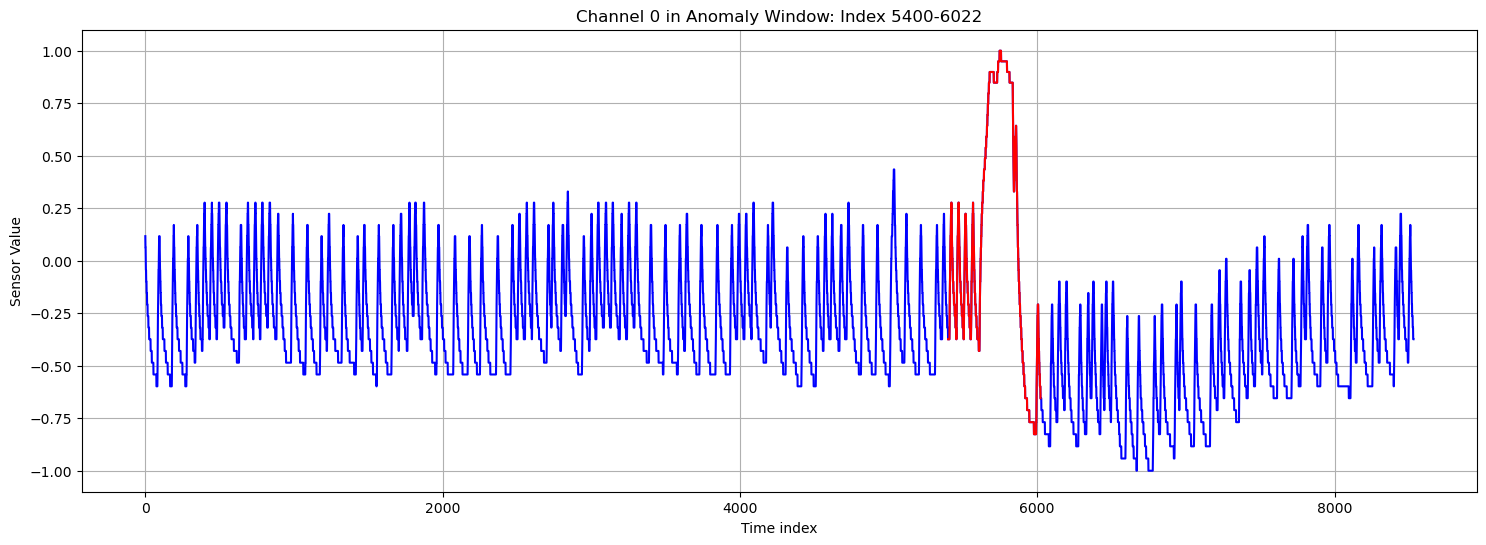

In [6]:
np.random.seed(10)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

The one reported, is one of anomalies classified as "contextual" as its behavior is anomalous if compared within the context, but not all anomalies are in this way in this dataset.

Selected telemetry: R-1
Anomaly of telemetry: [[4510 4590]]


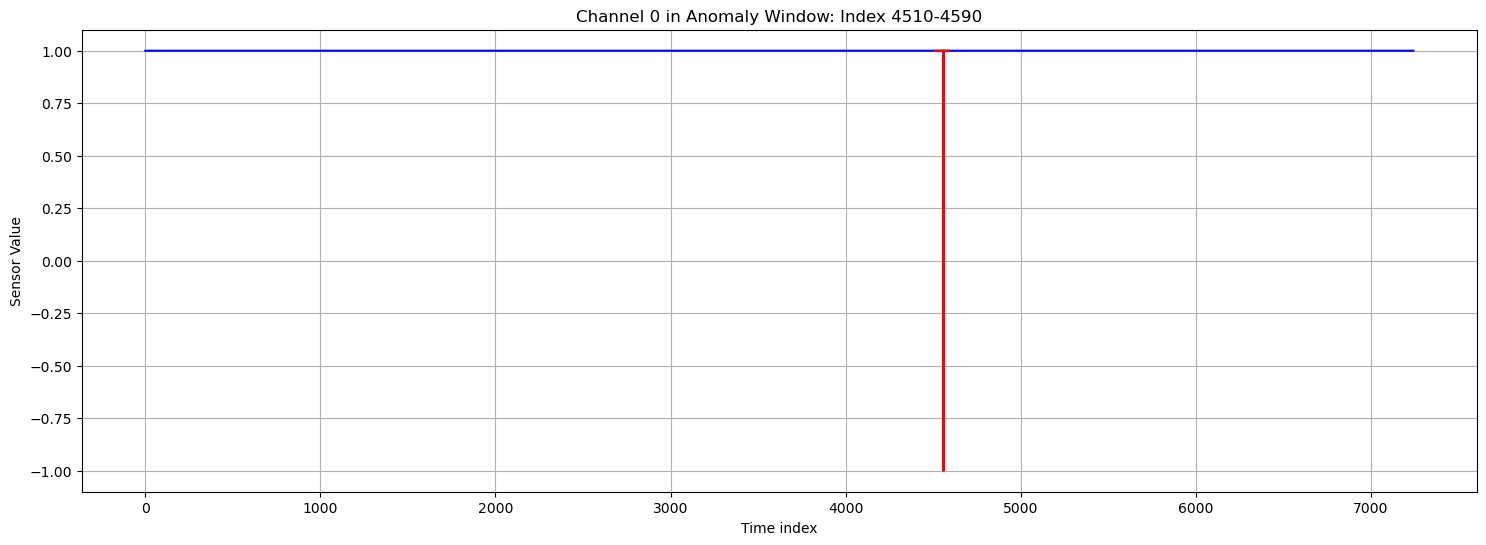

In [7]:
np.random.seed(4)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This one, is what is called "point" anomaly and it is easy to observe that the problem mainly relies on the value of the observed telemetry in a certain timestamp.

# ALL AROUND PIPELINE

Our all around pipeline will be:

START: test raw -> sliding windows -> prediction -> prediction errors -> smoothing errors -> thresholding -> anomaly buffer -> pruning / grouping sequences :END

In particular, the post-processing pipeline is inspired by the paper ***"Detecting Spacecraft Anomalies Using LSTMs and Nonparametric Dynamic Thresholding; K.Hundman,V.Constantinou,C.Laporte,I.Colwell,T.Soderstrom"*** and, for the seek of comparing several models, same strategy is applied to all studied models. In this view it is important to say that for the nature of the task, *forecasting-based* models are preferred due their capability of spotting an anomaly based on the cotext: a forecaster predicts next value based on what saw previously and, if the true value of the sequence is far from the guess (according to a criterion below exposed), an anomal is detected; instead, a *reconstruction-based* model aims to reconstruct a sequence starting from a compressed representation of it and spots anomaly based on the error committed by doing so. 
So the problem is that when we deal with contextual anomalies, spotting a "strange" point is not enough because an anomaly is defined so when compared to the overall context: if a contextual anomaly is *locally reconstructable*, a reconstruction based model is able to reconstract the sequence within a low error, hence not spotting such anomaly. This is the typical case when a portion of the sequence is anomalous when compared to previous history (another portion of the sequence) but maintans a regular shaped pattern inside. 

Therefore, here we are saying that our strategy of postprocessing, regarding detected anomalies by a model, is forecasting-based oriented by choise and we will see that has a huge impact on the final metrics. For instance, a model-specific thresholding strategy could probably improve reconstruction-based metrics, but this is not the main objective of the comparison. We deliberately kept the post-processing fixed to isolate the effect of the anomaly score generation mechanism and to remain aligned with the reference paper.

## PREPROCESSING

The SMAP dataset is composed of multiple telemetry channels, each corresponding to a specific monitored signal from the Soil Moisture Active Passive satellite system. Each channel is stored as a multivariate time series with 25 features. The first feature represents the main telemetry signal to be modeled and forecasted, while the remaining 24 features represent auxiliary command-related variables. These command variables provide operational context: they describe external inputs or discrete system states that may influence the evolution of the main telemetry signal.

For this reason, the anomaly detection task is naturally framed as a **forecasting problem**. Given the recent history of the telemetry signal and the associated command variables, the model learns to predict the future behavior of the main signal. An anomaly is then identified when the observed signal deviates significantly from the expected behavior predicted under the current command context.

In this setting, a **point anomaly** can be interpreted as an isolated telemetry value that is physically unusual by itself, independently of the surrounding temporal context. For example, this may correspond to a sudden spike, drop, or value that lies far outside the usual operating range of the signal.

A **contextual anomaly** is instead a value that may not be abnormal in absolute terms, but becomes abnormal given the temporal and operational context. For example, a certain telemetry value may be acceptable under one command configuration, but unexpected when the command variables indicate a different operating condition. This interpretation is necessarily subjective, because the dataset does not provide a direct physical explanation for each labeled anomaly; the distinction is inferred from the structure of the data and from the forecasting-based anomaly detection setup.

In [8]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.std(X, axis=0)
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training files shows that all channels contain 25 features and no missing or infinite values. Feature values are mostly bounded in [-1, 1] or [0, 1], suggesting that the dataset has already been normalized before release. For this reason, no additional standard scaling is applied in the main pipeline.

A relevant aspect is the presence of several constant features within many channels. At first, dimensionality reduction techniques such as PCA were considered to remove redundant or non-informative components. However, the constant features are kept in the final preprocessing strategy because they may still carry useful operational information: since some of these variables represent command signals, a flat signal can indicate the absence of a command and may therefore help the forecasting model distinguish normal operating conditions from anomalous behavior.

The training lengths are not uniform across channels, ranging from short sequences of a few hundred time steps to longer sequences close to 2880 time steps. This means that each channel should be treated independently, since the amount of available temporal context and the number of training windows differ substantially across telemetry streams.

### Windowing Strategy

The raw multivariate telemetry sequence is converted into a set of overlapping temporal windows. For each starting index `i`, the input sample contains the previous `window_size` observations of all available features:

$X_i = X[i : i + window\_size, :]$

This window is the common input representation used by all models. It preserves the local temporal structure of the telemetry stream and allows each model to exploit the recent multivariate history of the system.

For forecasting-based models, the same window is associated with a future target. More specifically, the target is defined as the next `n_predictions` values of the main telemetry signal, corresponding to feature `0`:

$y_i = X[i + window\_size : i + window\_size + n\_predictions, 0]$

Therefore, forecasting models are trained to predict the future evolution of the main telemetry channel from the recent multivariate history. At test time, the anomaly score is obtained from the mismatch between the predicted future trajectory and the values actually observed.

For reconstruction-based models, the forecasting target is not used during training. AE, VAE and LSTM-VAE receive the same multivariate input windows, but their objective is to reconstruct the input window itself:

$X_i \rightarrow \hat{X}_i$

The anomaly score is then computed from the reconstruction error between the original window and the reconstructed one. In this setting, anomalous behaviour is expected to produce windows that are harder to reconstruct from the patterns learned on nominal training data.

This design keeps the input representation consistent across the different families of models, while preserving the conceptual difference between forecasting-based and reconstruction-based anomaly detection. Forecasting models evaluate whether the future behaviour is coherent with the recent past, whereas reconstruction models evaluate whether the observed window itself is compatible with the normal patterns learned during training.

The windows are highly overlapping when `stride = 1`. This increases the number of available samples and provides a fine-grained temporal resolution for the final anomaly scores. During training, windows may be shuffled because the chronological order inside each window is preserved. During testing, windows are kept in temporal order so that prediction or reconstruction errors can be aligned with the original time axis.

The loop upper bound follows the original Telemanom implementation and intentionally omits the final `+1`. This choice has negligible practical impact and keeps the window generation aligned with the reference forecasting pipeline.

In [ ]:
def make_forecasting_windows(X, window_size=250, n_predictions=10, stride=1):
    """
    Input:
        X[i : i + l_s]

    Target:
        X[i + l_s : i + l_s + n_predictions, 0]
    """

    X_windows = []
    y_windows = []

    for i in range(0, len(X) - window_size - n_predictions, stride):
        X_windows.append(X[i : i + window_size, :])
        y_windows.append(X[i + window_size : i + window_size + n_predictions, 0])

    return np.array(X_windows), np.array(y_windows)

### Test Label Construction

The test labels are built from the original annotated anomaly intervals. For each test channel, a binary vector is created with the same length as the raw test sequence: normal timesteps are marked as `0`, while timesteps belonging to an annotated anomaly interval are marked as `1`.

The function `build_binary_labels` converts a generic list of anomaly intervals into a binary vector. Each interval `[start, end]` is clipped to the valid sequence range, and all timesteps inside the interval are marked as anomalous.

The function `align_anomalies` applies the same idea to a specific SMAP channel. It selects the anomaly intervals associated with the given `channel_id` and creates a binary label vector in the original raw test coordinates:

$y_{raw} \in \{0,1\}^{T_{test}}$

where $T_{test}$ is the length of the raw test sequence.

Importantly, no temporal shift is applied at this stage. The labels remain aligned with the original test sequence, not with the windowed forecasting targets. This is intentional, because the index shift introduced by the input window length is handled later during dynamic thresholding.

In the forecasting setting, each prediction error produced by a window starting at index `i` refers to a future timestep located after the input window. Therefore, when final anomaly indices are generated, they must be shifted by the input window length `l_s` to recover their position in the original raw test timeline.

This design keeps the ground-truth labels in raw coordinates and applies the prediction-to-raw alignment only when anomaly scores are converted into final binary predictions. As a result, both predicted anomaly intervals and labelled anomaly intervals are evaluated in the same original test-time coordinate system.

In [77]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x


def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y


def align_anomalies(labels_df, channel_id, X_test_raw):
    """
    Return labels in raw test coordinates, not shifted coordinates.
    The prediction indices are shifted later by l_s inside dynamic thresholding.
    """
    y_raw = np.zeros(len(X_test_raw), dtype=int)

    intervals = labels_df[labels_df["chan_id"] == channel_id]["anomaly_sequences"]

    for seq in intervals:
        for start, end in seq:
            y_raw[start:end + 1] = 1

    return y_raw

In [11]:
df_SMAP_anomalies["anomaly_sequences"] = (df_SMAP_anomalies["anomaly_sequences"].apply(parse_anomaly_sequences))

In [78]:
window_size = 250
n_predictions = 10
stride = 1

X_train_data = {}
X_test_data = {}
y_train_data = {}
y_test_data = {}
labels_data = {}

for ch in smap_channels_ids:
    path_train = TRAIN_PATH + '/' + ch + '.npy'
    path_test = TEST_PATH + '/' + ch + '.npy'

    x_train = np.load(path_train)
    x_test = np.load(path_test)

    X_train, y_train = make_forecasting_windows(
        x_train,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    X_test, y_test = make_forecasting_windows(
        x_test,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    labels = align_anomalies(
        labels_df=df_SMAP_anomalies,
        channel_id=ch,
        X_test_raw=x_test,
    )

    X_train_data[ch] = X_train
    X_test_data[ch] = X_test
    y_train_data[ch] = y_train
    y_test_data[ch] = y_test
    labels_data[ch] = labels

### Processed Dataset Structure

Each telemetry channel has its own number of observations. After windowing, the input data for each channel have shape

$[n_{\text{windows}},\; l_{\text{window}},\; n_{\text{features}}]$

where $l_{\text{window}} = 250$ and $n_{\text{features}} = 25$.

For each channel, a sliding window of length 250 is extracted from the multivariate time series. Each input sample has the form

$X_i = [x_i, \ldots, x_{i+249}]$

where each $x_t$ contains all the available telemetry features at timestep $t$. This input representation is shared by both forecasting-based and reconstruction-based models.

For forecasting-based models, each input window is associated with a future target. The target is the future evolution of the main telemetry signal, i.e. feature 0, over the next $n_{\text{predictions}} = 10$ timesteps:

$y_i = [x^{(0)}_{i+250}, \ldots, x^{(0)}_{i+259}]$

where $x^{(0)}$ denotes the main telemetry feature.

Therefore, **forecasting-based** models are trained to predict the next 10 values of the main telemetry signal from the recent multivariate history and the corresponding command context. After prediction, the anomaly score is obtained by comparing the forecasted values with the actually observed values. Large prediction errors indicate that the observed behaviour was not well explained by the recent temporal history and command configuration.

For **reconstruction-based** models, anomaly score is instead computed from the reconstruction error. To keep the final detection task aligned with the main telemetry channel, the reconstruction error is evaluated on feature 0 only:

$\text{score}_i = \frac{1}{l_{\text{window}}} \sum_{t=0}^{l_{\text{window}}-1} \left( X_i[t,0] - \hat{X}_i[t,0] \right)^2$

The remaining features are still used as contextual information by the model, but they do not directly contribute to the final anomaly score. This makes the reconstruction-based setting consistent with the forecasting-based one: all models exploit the multivariate context, while the final anomaly score is centered on the main telemetry signal.

The same windowing procedure is applied independently to the training and test sequences of each channel. During testing, prediction errors or reconstruction errors are later aligned with the original raw test timeline so that the final binary predictions and the annotated anomaly intervals are evaluated in the same coordinate system.

In [79]:
ch = 'A-1'
print("X_train:", X_train_data[ch].shape)
print("y_train:", y_train_data[ch].shape)
print("X_test: ", X_test_data[ch].shape)
print("y_test: ", y_test_data[ch].shape)
print("labels: ", labels_data[ch].shape)

X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test:  (8380, 250, 25)
y_test:  (8380, 10)
labels:  (8640,)


## Anomaly Detection Strategy

The anomaly detection strategy adopted in this project follows the post-processing logic proposed by Hundman et al. (2018) for spacecraft telemetry anomaly detection. The core idea is not to classify raw telemetry values directly, but to first compute a continuous anomaly score and then convert this score into binary anomaly intervals through smoothing, dynamic thresholding, buffering and pruning.

After the anomaly scores are computed, the raw score sequence is smoothed using an exponentially weighted moving average (EWMA). This reduces the effect of isolated noisy peaks and produces a more stable score trajectory before thresholding.

The function `get_anomaly_sequences` groups consecutive anomalous points into contiguous anomaly intervals. This is necessary because telemetry anomalies are evaluated as temporal events, not only as isolated pointwise detections.

The function `apply_error_buffer` expands detected anomalous indices by adding a temporal buffer before and after each detected point. If an index is classified as anomalous, the neighbouring `error_buffer` timesteps are also included. This follows the Telemanom post-thresholding logic and reflects the fact that an anomaly can affect a short temporal region around the detected peak.

### Exponentially Weighted Moving Average (EWMA) Smoothing

The raw anomaly score sequence can contain sharp isolated peaks, even during nominal spacecraft operations. These peaks may come from noisy predictions, imperfect reconstructions, local telemetry fluctuations or numerical instability. To reduce the effect of isolated spikes before thresholding, an Exponentially Weighted Moving Average (EWMA) is applied to the raw score sequence.

Unlike a simple moving average, EWMA assigns exponentially decreasing weights to older observations. Recent scores have the largest impact, while previous scores still contribute with progressively smaller weight. The recursive form is:

$e_s^{(t)} = \alpha e^{(t)} + (1 - \alpha)e_s^{(t-1)}$

where $e^{(t)}$ is the raw anomaly score at timestep $t$, $e_s^{(t)}$ is the smoothed score, and $\alpha$ is the smoothing factor.

In this implementation, the EWMA span follows the Telemanom setting:

$span = batch\_size \cdot window\_size \cdot smoothing\_perc$

With the default parameters, this gives a span of 105. The smoothing step acts as a low-pass filter: isolated one-step peaks are attenuated, while persistent deviations accumulate over time and are more likely to exceed the dynamic threshold.

For all channels except `C-2`, the first `l_s` smoothed scores are replaced with the mean of the first `2*l_s` smoothed scores. This reproduces the Telemanom initialization strategy and avoids unstable early scores caused by the lack of previous temporal history.

In [ ]:
def get_anomaly_sequences(binary_array):
    """
    Return contiguous anomalous intervals from a binary array.
    Example:
        [0, 1, 1, 0, 1] -> [(1, 2), (4, 4)]
    """

    binary_array = np.asarray(binary_array).astype(int)

    padded = np.pad(binary_array, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    return list(zip(starts, ends))


def apply_error_buffer(anomaly_indices, sequence_length, error_buffer=100):
    """
    Expand anomalous indices by adding a temporal buffer before and after each point.
    This follows Telemanom's post-thresholding logic.
    """

    anomaly_indices = np.asarray(anomaly_indices).astype(int)

    if len(anomaly_indices) == 0:
        return anomaly_indices

    buffer = np.arange(1, error_buffer + 1)

    buffered_indices = np.concatenate([
        anomaly_indices,
        np.array([i + buffer for i in anomaly_indices]).flatten(),
        np.array([i - buffer for i in anomaly_indices]).flatten()
    ])

    buffered_indices = buffered_indices[
        (buffered_indices >= 0) & (buffered_indices < sequence_length)
    ]

    return np.sort(np.unique(buffered_indices)).astype(int)


def apply_ewma_smoothing(
    errors,
    batch_size=70,
    window_size=30,
    smoothing_perc=0.05,
    l_s=250,
    channel_id=None
):
    """
    Computes EWMA smoothing on errors
    """

    errors = np.asarray(errors).astype(float)

    span = int(batch_size * window_size * smoothing_perc)
    span = max(span, 1)

    smoothed = pd.DataFrame(errors).ewm(span=span).mean().values.flatten()

    if channel_id != "C-2" and len(smoothed) >= 2 * l_s:
        smoothed[:l_s] = np.mean(smoothed[:2 * l_s])

    return smoothed

### Non-Parametric Dynamic Thresholding

The final anomaly predictions are obtained by applying a Telemanom-style dynamic thresholding procedure to the smoothed anomaly score sequence. The input of this stage is not the raw telemetry signal and not the model output directly, but a one-dimensional anomaly score already computed and smoothed with EWMA.

The origin of this score depends on the model family. For forecasting-based models, the score is the prediction error on feature 0. For reconstruction-based models, the score is the reconstruction error on feature 0, after reconstructing the multivariate input window. In both cases, the post-processing stage receives the same type of object: a univariate score sequence aligned with the main telemetry signal. Therefore, from this point onward, the dynamic thresholding procedure is identical for all models.

The procedure is local and adaptive. Instead of using a single global threshold over the whole test sequence, the smoothed scores are processed through temporal windows. With the default configuration, each thresholding window contains

$$ h = batch\_size \cdot window\_size = 70 \cdot 30 = 2100 $$

score values. The window is then advanced by `batch_size = 70` timesteps. Therefore, each iteration uses a relatively long local history to estimate the score distribution, but only the newest batch is used to add new anomaly candidates after the first window.

For each window, the function `find_hundman_threshold` searches for a threshold of the form

$$\epsilon = \mu(e_s) + z\sigma(e_s)$$

where $e_s$ is the current window of smoothed scores. The values of $z$ are scanned from `2.5` to `sd_lim = 12.0` with step `0.5`. For each candidate threshold, the points above $\epsilon$ are treated as preliminary anomalous indices. These indices are temporarily expanded using the error buffer, grouped into contiguous sequences, and then used to evaluate the quality of the threshold.

The objective favours thresholds that produce a strong reduction in the mean and standard deviation of the remaining non-anomalous scores:

$$\frac{\Delta \mu(e_s)}{\mu(e_s)} + \frac{\Delta \sigma(e_s)}{\sigma(e_s)}$$

At the same time, the score is penalized by the number of anomalous points and by the squared number of anomalous sequences:

$$\frac{\frac{\Delta \mu(e_s)}{\mu(e_s)} + \frac{\Delta \sigma(e_s)}{\sigma(e_s)}}{|i_{anom}| + |E_{seq}|^2}$$

This discourages thresholds that classify too many points as anomalous or fragment the prediction into too many separate anomaly intervals. In the implementation, additional guardrails are used: a candidate threshold is accepted only if it produces at most 5 anomalous sequences and marks less than 50% of the current window as anomalous.

After the threshold is selected, `compare_to_epsilon_window` applies it to the current smoothed score window. A point is considered anomalous only if its score is above the selected threshold and also sufficiently large relative to the local variability of the observed target signal. In particular, the code checks both the standard deviation and the 5–95 percentile range of `y_test_window`. This reproduces the Telemanom-style logic that avoids raising alerts when the score magnitude is too small compared with the underlying telemetry variation. The observed signal `y_test_window` is not used to compute the anomaly score. It is used only for scale-based guardrails, which compare the score magnitude with the local variability of the main telemetry signal. This is why both forecasting-based and reconstruction-based scores are defined on feature 0 before entering this stage.

The same function also applies the error buffer. Each detected anomalous index is expanded by `error_buffer` timesteps before and after the detection. This turns isolated threshold crossings into short anomalous regions, reflecting the assumption that telemetry anomalies are temporal events rather than independent pointwise spikes.

The handling of window positions is also explicit. In the first thresholding window, the code ignores an initial portion of the sequence because the beginning has limited historical context and the EWMA initialization may still be unstable. The ignored length depends on the available sequence length: normally `2*l_s`, reduced to `l_s` for shorter sequences, and set to zero for very short sequences. In subsequent thresholding windows, only indices belonging to the newest batch are considered as new candidates; earlier points in the window are used only to estimate the local threshold.

After candidate anomalies are found, `prune_anoms_window` removes weak anomalous sequences. For each candidate sequence, the maximum score inside the sequence is computed. The sequence maxima are sorted in descending order and compared with each other and with the largest non-anomalous score. If the relative drop between consecutive maxima is smaller than `p = 0.13`, the weaker candidates are removed. The relative drop is computed for each scanned quantity of the list as:

$$ relative drop = \frac{(current value - next value)}{current value} $$


This pruning step keeps only anomalous sequences whose score peak is sufficiently separated from the rest of the score distribution.

If `inverse=True`, the same procedure is repeated on inverted scores. The inverted score sequence is obtained by reflecting the smoothed scores around their local mean:

$$e_{s,inv} = \mu(e_s) + (\mu(e_s) - e_s)$$

This allows the procedure to detect unusually low score patterns as well. The anomalous indices obtained from the original and inverted scores are then merged.

The function `apply_dynamic_thresholding` accumulates all detected anomalous indices across windows. These indices are initially expressed in the score/window coordinate system. At the end, they are shifted by `l_s` to map them back to the original raw test timeline:

$$i_{raw} = i_{score} + l_s$$

The final output `y_pred` is a binary vector of length `n + l_s`, where `n` is the number of smoothed scores. This makes the predictions compatible with the raw test-label coordinate system used for evaluation.

The function returns three objects: `y_pred`, the final binary anomaly prediction; `thresholds_per_point`, the local threshold assigned to each score position; and `postprocess_info`, a dictionary storing the main post-processing parameters: `batch_size`, `window_size`, `error_buffer`, `p`, `inverse`, and `l_s`.

In [15]:
def find_hundman_threshold(
    e_s,
    mean_e_s,
    sd_e_s,
    error_buffer=100,
    sd_lim=12.0,
    z_values=None
):
    """
    Candidate thresholds:
        epsilon = mean_e_s + z * sd_e_s

    The selected epsilon maximizes the reduction in mean and standard deviation
    after removing values above epsilon, penalized by the number of anomalous
    indices and anomalous sequences.
    """

    if z_values is None:
        z_values = np.arange(2.5, sd_lim, 0.5)

    e_s = np.asarray(e_s).astype(float)

    if sd_e_s == 0:
        return mean_e_s + sd_lim * sd_e_s, sd_lim

    max_score = -10000000
    best_epsilon = mean_e_s + sd_lim * sd_e_s
    best_z = sd_lim

    for z in z_values:
        epsilon = mean_e_s + sd_e_s * z

        pruned_e_s = e_s[e_s < epsilon]
        if len(pruned_e_s) == 0:
            continue

        i_anom = np.argwhere(e_s >= epsilon).reshape(-1)

        if len(i_anom) == 0:
            continue

        # buffers candidate anomalous indices while scoring thresholds
        i_anom = apply_error_buffer(
            anomaly_indices=i_anom,
            sequence_length=len(e_s),
            error_buffer=error_buffer - 1
        )

        if len(i_anom) == 0:
            continue

        y_tmp = np.zeros(len(e_s), dtype=int)
        y_tmp[i_anom] = 1

        E_seq = [
            seq for seq in get_anomaly_sequences(y_tmp)
            if seq[0] != seq[1]
        ]

        mean_perc_decrease = (mean_e_s - np.mean(pruned_e_s)) / mean_e_s if mean_e_s != 0 else 0
        sd_perc_decrease = (sd_e_s - np.std(pruned_e_s)) / sd_e_s if sd_e_s != 0 else 0

        score = (mean_perc_decrease + sd_perc_decrease) / (
            len(E_seq) ** 2 + len(i_anom)
        )

        # guardrails
        if (
            score >= max_score
            and len(E_seq) <= 5
            and len(i_anom) < len(e_s) * 0.5
        ):
            max_score = score
            best_epsilon = epsilon
            best_z = z

    return best_epsilon, best_z


def compare_to_epsilon_window(
    e_s,
    epsilon,
    errors_all_i_anom,
    window_num,
    batch_size=70,
    error_buffer=100,
    l_s=250,
    y_test_window=None,
):
    """
    Comparison between smoothed errors and epsilon
    for a single ErrorWindow.
    """

    e_s = np.asarray(e_s).astype(float)

    if y_test_window is None:
        y_test_window = np.zeros_like(e_s)

    y_test_window = np.asarray(y_test_window).astype(float)

    sd_e_s = np.std(e_s)
    sd_values = np.std(y_test_window)

    perc_high, perc_low = np.percentile(y_test_window, [95, 5])
    inter_range = perc_high - perc_low

    # skip if errors are too small relative to value variability / range.
    if not (
        (sd_e_s > (0.05 * sd_values) or np.max(e_s) > (0.05 * inter_range))
        and np.max(e_s) > 0.05
    ):
        return np.array([], dtype=int), [], -1000000

    i_anom = np.argwhere(
        (e_s >= epsilon) & (e_s > 0.05 * inter_range)
    ).reshape(-1)

    if len(i_anom) == 0:
        return np.array([], dtype=int), [], -1000000

    i_anom = apply_error_buffer(
        anomaly_indices=i_anom,
        sequence_length=len(e_s),
        error_buffer=error_buffer
    )

    # ignores early values because the first window has limited history.
    num_to_ignore = l_s * 2
    if len(y_test_window) < 2500:
        num_to_ignore = l_s
    if len(y_test_window) < 1800:
        num_to_ignore = 0

    if window_num == 0:
        i_anom = i_anom[i_anom >= num_to_ignore]
    else:
        i_anom = i_anom[i_anom >= len(e_s) - batch_size]

    if len(i_anom) == 0:
        return np.array([], dtype=int), [], -1000000

    i_anom = np.sort(np.unique(i_anom))

    # Compute non-anomalous max excluding previously detected anomalies
    batch_position = window_num * batch_size
    window_indices_global = np.arange(0, len(e_s)) + batch_position
    adj_i_anom_global = i_anom + batch_position

    excluded_global = np.append(errors_all_i_anom, adj_i_anom_global)
    candidate_global = np.setdiff1d(window_indices_global, excluded_global)

    candidate_local = np.unique(candidate_global - batch_position)
    candidate_local = candidate_local[
        (candidate_local >= 0) & (candidate_local < len(e_s))
    ]

    if len(candidate_local) > 0:
        non_anom_max = np.max(np.take(e_s, candidate_local))
    else:
        non_anom_max = -1000000

    y_tmp = np.zeros(len(e_s), dtype=int)
    y_tmp[i_anom] = 1

    E_seq = [
        seq for seq in get_anomaly_sequences(y_tmp)
        if seq[0] != seq[1]
    ]

    return i_anom, E_seq, non_anom_max


def prune_anoms_window(i_anom, E_seq, e_s, non_anom_max, p=0.13):
    """
    Pruning inside a single ErrorWindow.

    It removes candidate anomalous sequences that are not sufficiently separated
    from the next closest anomalous sequence or from the largest non-anomalous error.
    """

    if len(E_seq) == 0:
        return np.array([], dtype=int), []

    E_seq = np.asarray(E_seq)

    E_seq_max = np.array([
        np.max(e_s[start:end + 1])
        for start, end in E_seq
    ])

    E_seq_max_sorted = np.sort(E_seq_max)[::-1]
    E_seq_max_sorted = np.append(E_seq_max_sorted, [non_anom_max])

    i_to_remove = np.array([], dtype=int)

    for i in range(0, len(E_seq_max_sorted) - 1):
        current_value = E_seq_max_sorted[i]
        next_value = E_seq_max_sorted[i + 1]

        if current_value == 0:
            continue

        relative_drop = (current_value - next_value) / current_value

        if relative_drop < p:
            idx = np.argwhere(E_seq_max == current_value).reshape(-1)
            i_to_remove = np.append(i_to_remove, idx)
        else:
            i_to_remove = np.array([], dtype=int)

    if len(i_to_remove) > 0:
        i_to_remove = np.unique(i_to_remove.astype(int))
        E_seq = np.delete(E_seq, i_to_remove, axis=0)

    if len(E_seq) == 0:
        return np.array([], dtype=int), []

    indices_to_keep = np.concatenate([
        np.arange(start, end + 1)
        for start, end in E_seq
    ])

    mask = np.isin(i_anom, indices_to_keep)
    i_anom = i_anom[mask]

    return i_anom.astype(int), [tuple(x) for x in E_seq]


def apply_dynamic_thresholding(
    test_smoothed,
    y_test_signal,
    batch_size=70,
    window_size=30,
    error_buffer=100,
    p=0.13,
    inverse=True,
    l_s=250
):

    test_smoothed = np.asarray(test_smoothed).astype(float)
    y_test_signal = np.asarray(y_test_signal).astype(float)

    n = len(test_smoothed)
    h = batch_size * window_size

    y_pred = np.zeros(n + l_s, dtype=int)
    thresholds_per_point = np.full(n, np.nan)

    i_anom_all = np.array([], dtype=int)

    n_windows = int((n - h) / batch_size)

    if n_windows < 0:
        adjusted_window_size = window_size
        while n_windows < 0 and adjusted_window_size > 1:
            adjusted_window_size -= 1
            h = adjusted_window_size * batch_size
            n_windows = int((n - h) / batch_size)

        if n_windows < 0:
            h = n
            n_windows = 0

    for window_num in range(0, n_windows + 1):
        prior_idx = window_num * batch_size
        end_idx = h + window_num * batch_size

        if window_num == n_windows:
            end_idx = n

        e_s = test_smoothed[prior_idx:end_idx]
        y_window = y_test_signal[prior_idx:end_idx]

        if len(e_s) == 0:
            continue

        mean_e_s = np.mean(e_s)
        sd_e_s = np.std(e_s)

        epsilon, _ = find_hundman_threshold(
            e_s=e_s,
            mean_e_s=mean_e_s,
            sd_e_s=sd_e_s,
            error_buffer=error_buffer,
            sd_lim=12.0
        )

        thresholds_per_point[prior_idx:end_idx] = epsilon

        i_anom, E_seq, non_anom_max = compare_to_epsilon_window(
            e_s=e_s,
            epsilon=epsilon,
            errors_all_i_anom=i_anom_all,
            window_num=window_num,
            batch_size=batch_size,
            error_buffer=error_buffer,
            l_s=l_s,
            y_test_window=y_window,
        )

        i_anom, E_seq = prune_anoms_window(
            i_anom=i_anom,
            E_seq=E_seq,
            e_s=e_s,
            non_anom_max=non_anom_max,
            p=p
        )

        # Inverted errors: detects anomalously low error patterns / drops
        if inverse:
            e_s_inv = np.array([
                mean_e_s + (mean_e_s - e)
                for e in e_s
            ])

            epsilon_inv, _ = find_hundman_threshold(
                e_s=e_s_inv,
                mean_e_s=mean_e_s,
                sd_e_s=sd_e_s,
                error_buffer=error_buffer,
                sd_lim=12.0
            )

            i_anom_inv, E_seq_inv, non_anom_max_inv = compare_to_epsilon_window(
                e_s=e_s_inv,
                epsilon=epsilon_inv,
                errors_all_i_anom=i_anom_all,
                window_num=window_num,
                batch_size=batch_size,
                error_buffer=error_buffer,
                l_s=l_s,
                y_test_window=y_window,
            )

            i_anom_inv, E_seq_inv = prune_anoms_window(
                i_anom=i_anom_inv,
                E_seq=E_seq_inv,
                e_s=e_s_inv,
                non_anom_max=non_anom_max_inv,
                p=p
            )

            i_anom = np.sort(np.unique(np.append(i_anom, i_anom_inv))).astype(int)

        if len(i_anom) == 0:
            continue

        global_indices = i_anom + prior_idx

        i_anom_all = np.append(i_anom_all, global_indices)
        i_anom_all = np.sort(np.unique(i_anom_all)).astype(int)

    if len(i_anom_all) > 0:
        # shifts anomaly indices by l_s to map y_test coordinates
        # back to original raw test coordinates.
        shifted_indices = i_anom_all + l_s
        shifted_indices = shifted_indices[
            (shifted_indices >= 0) & (shifted_indices < len(y_pred))
        ]
        y_pred[shifted_indices] = 1

    postprocess_info = {
        "batch_size": batch_size,
        "window_size": window_size,
        "error_buffer": error_buffer,
        "p": p,
        "inverse": inverse,
        "l_s": l_s
    }

    return y_pred, thresholds_per_point, postprocess_info

### Aggregation of Multi-Step Forecasts

**This aggregation step is used only for forecasting-based models. Reconstruction-based models do not produce multi-step future forecasts and therefore do not require this aggregation stage.**

The forecasting model outputs multiple future predictions for each input window. In this implementation, each input window produces `n_predictions = 10` predicted future values for the main telemetry signal.

During inference, the test windows of each telemetry channel are processed in batches using `batch_predict_channel`. Each batch contains a subset of consecutive windowed samples. For a batch of length `batch_len`, the raw model output has shape

$$[batch\_len,\; n_{\text{predictions}}]$$

where each row contains the 10-step-ahead forecast produced from one input window.

Because input windows are overlapping, nearby rows inside the same batch may contain predictions that refer to overlapping future timesteps. For this reason, the function `aggregate_predictions` reduces the multi-step output matrix to one scalar prediction per input window.

The aggregation is performed locally inside each batch. For each local position `t`, the function identifies the set of available forecasts that can be associated with that position. These forecasts correspond to the same local temporal point, but they come from different input windows and therefore from different forecasting horizons.

With `method="first"`, the function keeps the first value of this selected set. Due to the way the diagonal is constructed, this value corresponds to the prediction produced by the most recent available input window for that local position. Equivalently, it selects the shortest-horizon forecast among the available candidates.

For example, with `n_predictions = 3`, the same local timestep can be predicted as a 3-step-ahead forecast from an older window, as a 2-step-ahead forecast from the following window, and as a 1-step-ahead forecast from the most recent window. The `first` strategy keeps the 1-step-ahead prediction because it uses the latest available history before the target point.

With `method="mean"`, all available forecasts associated with the same local position are averaged instead. In the current pipeline, `method="first"` is used, consistently with the idea of retaining the most informed, shortest-horizon available forecast.

Therefore, each batch is converted from

$$[batch\_len,\; n_{\text{predictions}}]$$

to

$$[batch\_len]$$

and the resulting aggregated predictions are appended to the final prediction vector `y_hat`.

This produces one forecasted value per processed test window. The final one-dimensional prediction sequence is then compared with the corresponding observed values of the main telemetry feature to compute the forecasting error used for anomaly detection.

In [16]:
def aggregate_predictions(y_hat_batch, method="first"):
    """
    Input:
        y_hat_batch shape = (batch_len, n_predictions)

    Output:
        one aggregated prediction per timestep in the batch.

    Default uses diagonal aggregation as method='first'.
    """

    y_hat_batch = np.asarray(y_hat_batch)

    agg_y_hat_batch = np.array([])

    for t in range(y_hat_batch.shape[0]):
        start_idx = 0 if t < y_hat_batch.shape[1] else t - y_hat_batch.shape[1] + 1

        y_hat_t = np.flipud(y_hat_batch[start_idx:t + 1]).diagonal()

        if method == "first":
            agg_y_hat_batch = np.append(agg_y_hat_batch, [y_hat_t[0]])
        elif method == "mean":
            agg_y_hat_batch = np.append(agg_y_hat_batch, np.mean(y_hat_t))
        else:
            raise ValueError("method must be 'first' or 'mean'")

    return agg_y_hat_batch.reshape(len(agg_y_hat_batch),)


def batch_predict_channel(model, X_test, batch_size=70, device="cpu"):
    """
    The test stream is processed in batches of 70 values, and predictions are
    aggregated inside each batch.
    """

    model.eval()
    y_hat = np.array([])

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    with torch.no_grad():
        for i in range(0, num_batches + 1):

            if device.type == "mps":
                torch.mps.empty_cache()
            elif device.type == "cuda":
                torch.cuda.empty_cache()
                
            prior_idx = i * batch_size
            idx = (i + 1) * batch_size

            if i + 1 == num_batches + 1:
                idx = X_test.shape[0]

            X_test_batch = X_test[prior_idx:idx]

            if len(X_test_batch) == 0:
                continue

            X_tensor = torch.tensor(X_test_batch, dtype=torch.float32).to(device)
            y_hat_batch = model(X_tensor).cpu().numpy()

            agg_y_hat_batch = aggregate_predictions(y_hat_batch, method="first")
            y_hat = np.append(y_hat, agg_y_hat_batch)

    return y_hat.reshape(-1)

### Sequence-Based Evaluation Metrics (Hundman et al., 2018)

Standard point-wise evaluation metrics can be misleading in time-series anomaly detection. Anomalies often occur as contiguous temporal intervals rather than isolated independent points. Therefore, a detector that identifies an anomalous interval slightly after its beginning may still be operationally useful, even if point-wise metrics penalize the missed initial timesteps.

To better reflect this setting, we implement a sequence-based evaluation logic inspired by Hundman et al. (2018). Instead of evaluating each timestep independently, both true labels and predicted anomalies are first grouped into contiguous anomalous sequences. The comparison is then performed at the sequence level.

A predicted anomaly sequence is counted as a true positive if it overlaps with at least one labeled anomaly sequence. Each labeled anomaly can contribute at most one true positive, even if multiple predicted fragments overlap with it. A labeled anomaly sequence with no overlapping prediction is counted as a false negative. Conversely, any predicted anomaly sequence that does not overlap with any labeled anomalous interval is counted as a false positive.

From these sequence-level counts, precision, recall, F1-score and F0.5-score are computed:

$$
\text{precision} = \frac{TP}{TP + FP}
$$

$$
\text{recall} = \frac{TP}{TP + FN}
$$

$$
F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

$$
F_{0.5} = (1 + 0.5^2) \cdot \frac{\text{precision} \cdot \text{recall}}{0.5^2 \cdot \text{precision} + \text{recall}}
$$

Precision measures the reliability of the generated alarms, while recall measures the ability to detect true anomalous intervals. The F1-score provides a balanced summary when false alarms and missed anomalies are considered equally important. The F0.5-score gives more weight to precision, which is useful when false positives are particularly undesirable.

In addition to the sequence-based metrics, PR-AUC is reported as a threshold-independent diagnostic metric computed point-wise from the continuous anomaly scores. This is useful because the final binary performance can depend strongly on the selected threshold and post-processing strategy. PR-AUC should therefore be interpreted as a diagnostic measure of score quality, not as the final sequence-level detection performance.

The `predicted_anomaly_ratio` is also reported as a diagnostic quantity. It indicates the fraction of final prediction positions marked as anomalous and helps identify degenerate cases where a model predicts almost everything as normal or almost everything as anomalous.

Given the characteristics of the SMAP anomaly detection task, all these metrics are useful, each for a different reason. The primary goal is to detect anomalous telemetry events, therefore sequence-level recall is crucial: a low recall means that many labelled anomaly intervals are completely missed. However, recall alone is not sufficient, because a detector could obtain high recall by marking too much of the timeline as anomalous. For this reason, precision and predicted anomaly ratio must be checked together with recall. Precision indicates how reliable the generated alarms are, while predicted anomaly ratio shows whether the model is producing a reasonable amount of anomaly predictions.

In this study, the main metric to monitor is sequence-level F1, supported by recall and precision. F1 is the most compact indicator of the precision-recall trade-off after the final post-processing pipeline. Recall is especially important to verify that the model is not missing most anomaly intervals, while precision and predicted anomaly ratio are needed to ensure that the detector is not simply increasing recall by over-predicting anomalies. F0.5 is also useful when precision is considered more important, for example when excessive false alarms would make the detector operationally impractical.

When results are aggregated across channels, TP, FP and FN are summed over all telemetry channels before computing global precision, recall, F1 and F0.5. By contrast, PR-AUC and predicted anomaly ratio are reported as macro averages over channels. This distinction is important when interpreting the summary tables produced for each model.

In [93]:
def evaluate_sequences(y_true, y_pred, y_scores=None):
    """
    Sequence-based evaluation following Hundman et al. (2018).

    A true positive is counted if any part of a predicted anomalous sequence
    overlaps with a labeled anomalous sequence.
    """

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

    if y_scores is not None:
        y_scores = np.asarray(y_scores).astype(float)
        y_scores = y_scores[:min_len]

    true_seqs = get_anomaly_sequences(y_true)
    pred_seqs = get_anomaly_sequences(y_pred)

    FP = 0
    detected_true_seqs = set()

    for p_start, p_end in pred_seqs:
        overlap_found = False

        for i, (t_start, t_end) in enumerate(true_seqs):
            if max(p_start, t_start) <= min(p_end, t_end):
                overlap_found = True
                detected_true_seqs.add(i)
                break

        if not overlap_found:
            FP += 1

    TP = len(detected_true_seqs)
    FN = len(true_seqs) - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    beta = 0.5
    f05 = (
        (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)
        if (precision + recall) > 0
        else 0.0
    )

    if y_scores is None or len(np.unique(y_true)) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_scores)

    predicted_anomaly_ratio = float(y_pred.mean())

    return pd.DataFrame([{
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f0.5": f05,
        "pr_auc": pr_auc,
        "predicted_anomaly_ratio": predicted_anomaly_ratio
    }])

### Plots and Saving Functions

In [18]:
def generate_results_view(method_metrics: dict):
    
    def scalarize(x):
        if isinstance(x, pd.DataFrame):
            return x.iloc[0]
        if isinstance(x, pd.Series):
            return x.iloc[0]
        if isinstance(x, np.ndarray):
            return x.item() if x.size == 1 else x[0]
        return x

    rows = []

    for ch, metrics in method_metrics.items():
        if isinstance(metrics, pd.DataFrame):
            m = metrics.iloc[0]
        else:
            m = metrics

        rows.append({
            "channel_id": ch,
            "TP": int(scalarize(m["TP"])),
            "FP": int(scalarize(m["FP"])),
            "FN": int(scalarize(m["FN"])),
            "precision": float(scalarize(m["precision"])),
            "recall": float(scalarize(m["recall"])),
            "f1": float(scalarize(m["f1"])),
            "f0.5": float(scalarize(m["f0.5"])),
            "pr_auc": float(scalarize(m["pr_auc"])) if pd.notna(scalarize(m["pr_auc"])) else np.nan,
            "predicted_anomaly_ratio": float(scalarize(m["predicted_anomaly_ratio"])),
        })

    results_df = pd.DataFrame(rows)

    TP = results_df["TP"].sum()
    FP = results_df["FP"].sum()
    FN = results_df["FN"].sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    beta = 0.5
    f05 = (
        (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)
        if (precision + recall) > 0
        else 0.0
    )

    summary = pd.Series({
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f0.5": f05,
        "pr_auc_macro": results_df["pr_auc"].mean(skipna=True),
        "predicted_anomaly_ratio_macro": results_df["predicted_anomaly_ratio"].mean()
    })

    display(results_df)
    display(summary)

    return results_df, summary

In [19]:
def plot_channel_diagnostics(
    ch,
    smoothed_errors,
    thresholds,
    predictions_binary,
    model_name,
    predictions=None,
    l_s=250
):
    """
    predictions_binary is in raw-test coordinates.
    smoothed_errors and thresholds are in y_hat/error coordinates, so they are
    shifted by l_s for visualization.
    """

    labels = labels_data[ch]
    y_pred = predictions_binary[ch]

    raw_test = np.load(os.path.join(TEST_PATH, f"{ch}.npy"))
    true_signal = raw_test[:, 0]

    n = min(len(true_signal), len(labels), len(y_pred))

    true_signal = true_signal[:n]
    labels = labels[:n]
    y_pred = y_pred[:n]

    score_raw = np.full(n, np.nan)
    thr_raw = np.full(n, np.nan)

    scores = smoothed_errors[ch]
    thrs = thresholds[ch]

    m = min(len(scores), n - l_s)

    if m > 0:
        score_raw[l_s:l_s + m] = scores[:m]
        thr_raw[l_s:l_s + m] = thrs[:m]

    fig, axes = plt.subplots(3, 1, figsize=(18, 9), sharex=True)

    axes[0].plot(true_signal, label="True signal")

    if predictions is not None and ch in predictions:
        pred_raw = np.full(n, np.nan)
        pred = predictions[ch]
        m_pred = min(len(pred), n - l_s)
        if m_pred > 0:
            pred_raw[l_s:l_s + m_pred] = pred[:m_pred]
        axes[0].plot(pred_raw, label="Forecast")

    axes[0].set_title(f"{model_name} - channel {ch}")
    axes[0].set_ylabel("Signal")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(score_raw, label="Smoothed anomaly score")
    axes[1].plot(thr_raw, label="Dynamic threshold")
    axes[1].set_title("Smoothed anomaly score and dynamic threshold")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(labels, label="True anomaly")
    axes[2].plot(y_pred, label="Predicted anomaly")
    axes[2].set_title("True vs predicted anomaly sequences")
    axes[2].set_xlabel("Timestep")
    axes[2].set_ylabel("Anomaly")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [20]:
def plot_overall_metrics(df: pd.DataFrame, method_name: str):
    metrics_to_plot = ["precision", "recall", "f1", "f0.5", "pr_auc"]

    available_metrics = [m for m in metrics_to_plot if m in df.columns]

    df_plot = df[["channel_id"] + available_metrics].copy()
    df_plot = df_plot.set_index("channel_id")

    ax = df_plot.plot(kind="bar", figsize=(16, 5))
    ax.set_title(f"{method_name} metrics by channel")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y")

    plt.tight_layout()
    plt.show()

In [21]:
def save_results(results_df:pd.DataFrame,summary_df:pd.DataFrame,method_name:str):
    RESULTS_DIR = os.path.join("Results", method_name)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_channel_results.csv"),
        index=False
    )

    summary_df.to_frame(name="mean_value").to_csv(
        os.path.join(RESULTS_DIR, f"{method_name}_global_summary.csv")
    )

# Methodology

In this project, we address unsupervised anomaly detection in multivariate spacecraft telemetry by comparing two main detection paradigms: **forecasting-based anomaly detection** and **reconstruction-based anomaly detection**. The goal is not only to test different architectures, but also to evaluate which type of anomaly score is more suitable for the contextual anomalies present in the SMAP dataset.

The **forecasting-based hypothesis** assumes that an anomaly appears as a future deviation that cannot be properly explained from the recent past and the available multivariate context. In this setting, the model receives a temporal window of past observations and predicts the next values of the main telemetry signal, corresponding to feature 0. During inference, the anomaly score is computed from the mismatch between the predicted future values and the actually observed ones. Large forecasting errors indicate that the observed behaviour is not coherent with the recent system history.

The **reconstruction-based hypothesis** assumes that an anomaly appears as a window that is difficult to represent using the patterns learned from nominal training data. In this setting, the model receives a multivariate input window and is trained to reconstruct it. The reconstruction models therefore exploit all available features as contextual information. However, to keep the final detection task aligned with the main telemetry channel, the anomaly score is computed from the reconstruction error on feature 0. In this way, both forecasting-based and reconstruction-based models produce anomaly scores centered on the same target signal.

### Roadmap

The experimental design is organized into three stages of increasing architectural complexity.

The first stage (***phase 0***) establishes simple baselines for the two paradigms. For forecasting, we use a **Random Forest Regressor**, which provides a classical machine-learning baseline for predicting the future values of the main telemetry signal. For reconstruction, we use a deterministic **Autoencoder**, which provides a basic neural baseline for learning a compressed representation of nominal telemetry windows.

In the second stage (***phase 1***), we move to feed-forward deep learning models. The **MLP Regressor** is used as a forecasting model, while the **MLP-VAE** is used as a probabilistic reconstruction model. In both cases, the temporal window is flattened into a one-dimensional vector. This allows the models to exploit the information contained in the window, but without explicitly modelling sequential dependencies through recurrent memory.

In the third stage (***phase 2***), we introduce recurrent architectures. The **LSTM Regressor** is used to test whether explicit temporal memory improves future prediction of the main telemetry signal. The **LSTM-VAE** is used to test whether a recurrent reconstruction model can better capture temporal structure inside nominal telemetry windows. This stage evaluates whether modelling the sequential evolution of the signal improves anomaly detection compared with feed-forward models.

All models are evaluated using the same post-processing explained above.

## Phase 0: Baselines

Before venturing into deep neural networks and probabilistic modeling, it is essential to establish an absolute performance floor. In this section, we introduce a **Random Forest Regressor** as the classical machine learning benchmark for the forecasting approach, and a **Standard Deterministic Autoencoder (AE)** for the reconstruction approach.

The rationale behind starting with these foundational, non-probabilistic algorithms is twofold:

1. **Establishing a Classical Lower Bound:** The Random Forest provides a powerful, non-linear baseline that treats the flattened historical window purely as a collection of independent static features. Evaluating this classical algorithm allows us to quantify exactly how much performance gain, if any, is achieved by shifting from traditional Machine Learning to Deep Learning architectures in the subsequent phases.

2. **Deterministic Reconstruction Benchmark:** By evaluating a standard, deterministic Autoencoder, we can measure the raw capability of a simple neural bottleneck to compress and recreate telemetry data. This establishes a fundamental baseline for reconstruction error before introducing the mathematical complexity and latent-space regularization of the Variational Autoencoder (VAE).

### Autoencoder Architecture

The Autoencoder is implemented as a fully connected deterministic encoder-decoder model. Since the input telemetry window has shape `[window_size, n_features]`, each window is first flattened into a one-dimensional vector before being passed to the network. With `window_size = 250` and `n_features = 25`, the input dimension is therefore `6250`.

The encoder progressively compresses the flattened input through two hidden layers of size `512` and `256`, using ReLU activations after each hidden layer. The final encoder layer maps the representation into a low-dimensional latent vector of size `latent_size`. This latent bottleneck forces the model to retain only the most relevant structure needed to reconstruct nominal telemetry windows.

The decoder mirrors the encoder structure. It maps the latent vector back through hidden layers of size `256` and `512`, again using ReLU activations, and finally reconstructs an output vector with the same dimension as the original flattened input. The reconstructed vector can then be reshaped back into the original window format.

This architecture does not explicitly model temporal order with recurrent layers. Temporal information is still present in the input window, but it is treated as part of a flattened feature vector. Therefore, the AE tests whether a simple feed-forward bottleneck representation is sufficient to capture normal multivariate telemetry patterns and produce useful reconstruction errors for anomaly detection.

In [22]:
class AEDataset(Dataset):
    def __init__(self, X):
        super().__init__()
        X = np.asarray(X)

        self.X = torch.tensor(X.reshape(X.shape[0], -1), dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index]


def make_ae_loader(X, batch_size=64, shuffle=True):
    dataset = AEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [23]:
class AutoEncoder(nn.Module):
    def __init__(self, input_size, latent_size):
        super().__init__()

        self.input_size = input_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_size)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_size)
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, x):
        return self.decoder(x)
    
    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        h = self.encode(x)
        x_recon = self.decode(h)
        return x_recon

In [80]:
def compute_ae_scores(model, X_test, batch_size=64, device="cpu"):
    """
    Compute one reconstruction anomaly score per test window.

    The AE reconstructs the full multivariate window, but the anomaly score is
    computed only on feature 0, i.e. the main telemetry signal.
    """

    model.eval()
    all_scores = []

    window_size = X_test.shape[1]
    n_features = X_test.shape[2]

    loader = make_ae_loader(
        X_test,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for X_batch_flat in loader:
            X_batch_flat = X_batch_flat.to(device)

            X_recon_flat = model(X_batch_flat)

            X_batch = X_batch_flat.reshape(-1, window_size, n_features)
            X_recon = X_recon_flat.reshape(-1, window_size, n_features)

            mse_errors = torch.mean(
                (X_batch[:, :, 0] - X_recon[:, :, 0]) ** 2,
                dim=1
            )

            all_scores.append(mse_errors.cpu().numpy())

    return np.concatenate(all_scores)

In [81]:
def train_ae_channel(
    X_train,
    latent_size=16,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_ae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_ae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[1] * X_train.shape[2]

    model = AutoEncoder(input_size, latent_size).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            X_recon = model(X_batch)
            loss = criterion(X_recon, X_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    X_recon = model(X_batch)
                    loss = criterion(X_recon, X_batch)

                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch+1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [82]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [83]:
ae_models = {}
ae_histories = {}
ae_scores = {}
ae_smoothed_scores = {}
ae_predictions_binary = {}
ae_thresholds = {}
ae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training AE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_ae_channel(
        X_train=X_train,
        latent_size=32,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_ae_scores(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    ae_models[ch] = model.to("cpu")
    ae_histories[ch] = history
    ae_scores[ch] = scores
    ae_smoothed_scores[ch] = smoothed_scores
    ae_predictions_binary[ch] = y_pred
    ae_thresholds[ch] = thresholds
    ae_metrics[ch] = metrics

    display(metrics)

Training AE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.027978 | val loss: 0.017833
Epoch 02 | train loss: 0.018350 | val loss: 0.014985
Epoch 03 | train loss: 0.016228 | val loss: 0.013908
Epoch 04 | train loss: 0.015472 | val loss: 0.013355
Epoch 05 | train loss: 0.014865 | val loss: 0.012432
Epoch 06 | train loss: 0.014309 | val loss: 0.011991
Epoch 07 | train loss: 0.013824 | val loss: 0.011567
Epoch 08 | train loss: 0.013323 | val loss: 0.011199
Epoch 09 | train loss: 0.012852 | val loss: 0.010850
Epoch 10 | train loss: 0.012412 | val loss: 0.010532
Epoch 11 | train loss: 0.012034 | val loss: 0.010244
Epoch 12 | train loss: 0.011687 | val loss: 0.010000
Epoch 13 | train loss: 0.011388 | val loss: 0.009758
Epoch 14 | train loss: 0.011138 | val loss: 0.009533
Epoch 15 | train loss: 0.010925 | val loss: 0.009366
Epoch 16 | train loss: 0.010718 | val loss: 0.009182
Epoch 17 | train loss: 0.010517 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.021434,0.0


Training AE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.026340 | val loss: 0.019986
Epoch 02 | train loss: 0.018932 | val loss: 0.018954
Epoch 03 | train loss: 0.018328 | val loss: 0.018222
Epoch 04 | train loss: 0.017876 | val loss: 0.017605
Epoch 05 | train loss: 0.017457 | val loss: 0.017242
Epoch 06 | train loss: 0.016903 | val loss: 0.016918
Epoch 07 | train loss: 0.016224 | val loss: 0.016624
Epoch 08 | train loss: 0.015581 | val loss: 0.016349
Epoch 09 | train loss: 0.015029 | val loss: 0.015938
Epoch 10 | train loss: 0.014523 | val loss: 0.015659
Epoch 11 | train loss: 0.014151 | val loss: 0.015422
Epoch 12 | train loss: 0.013816 | val loss: 0.015274
Epoch 13 | train loss: 0.013514 | val loss: 0.015018
Epoch 14 | train loss: 0.013241 | val loss: 0.014897
Epoch 15 | train loss: 0.013041 | val loss: 0.014833
Epoch 16 | train loss: 0.012834 | val loss: 0.014603
Epoch 17 | train loss: 0.012622 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.053333,0.043016


Training AE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.023658 | val loss: 0.019188
Epoch 02 | train loss: 0.018268 | val loss: 0.018333
Epoch 03 | train loss: 0.017618 | val loss: 0.017597
Epoch 04 | train loss: 0.017121 | val loss: 0.017266
Epoch 05 | train loss: 0.016580 | val loss: 0.016842
Epoch 06 | train loss: 0.015727 | val loss: 0.016205
Epoch 07 | train loss: 0.014918 | val loss: 0.015650
Epoch 08 | train loss: 0.014244 | val loss: 0.015240
Epoch 09 | train loss: 0.013621 | val loss: 0.014939
Epoch 10 | train loss: 0.013132 | val loss: 0.014725
Epoch 11 | train loss: 0.012751 | val loss: 0.014587
Epoch 12 | train loss: 0.012449 | val loss: 0.014462
Epoch 13 | train loss: 0.012187 | val loss: 0.014333
Epoch 14 | train loss: 0.011988 | val loss: 0.014225
Epoch 15 | train loss: 0.011838 | val loss: 0.014299
Epoch 16 | train loss: 0.011713 | val loss: 0.014175
Epoch 17 | train loss: 0.011556 | val lo

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,1,2,0.0,0.0,0.0,0.0,0.134073,0.034759


Training AE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.019974 | val loss: 0.007902
Epoch 02 | train loss: 0.007164 | val loss: 0.003894
Epoch 03 | train loss: 0.004512 | val loss: 0.003479
Epoch 04 | train loss: 0.003745 | val loss: 0.003292
Epoch 05 | train loss: 0.003394 | val loss: 0.003271
Epoch 06 | train loss: 0.003285 | val loss: 0.003259
Epoch 07 | train loss: 0.003214 | val loss: 0.003228
Epoch 08 | train loss: 0.003149 | val loss: 0.003224
Epoch 09 | train loss: 0.003105 | val loss: 0.003211
Epoch 10 | train loss: 0.003051 | val loss: 0.003221
Epoch 11 | train loss: 0.002994 | val loss: 0.003186
Epoch 12 | train loss: 0.002920 | val loss: 0.003161
Epoch 13 | train loss: 0.002843 | val loss: 0.003144
Epoch 14 | train loss: 0.002767 | val loss: 0.003172
Epoch 15 | train loss: 0.002696 | val loss: 0.003173
Epoch 16 | train loss: 0.002625 | val loss: 0.003163
Epoch 17 | train loss: 0.002548 | val lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.180333,0.0


Training AE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.010378 | val loss: 0.000221
Epoch 02 | train loss: 0.002263 | val loss: 0.000080
Epoch 03 | train loss: 0.002210 | val loss: 0.000054
Epoch 04 | train loss: 0.002181 | val loss: 0.000070
Epoch 05 | train loss: 0.002053 | val loss: 0.000056
Epoch 06 | train loss: 0.001879 | val loss: 0.000040
Epoch 07 | train loss: 0.001681 | val loss: 0.000044
Epoch 08 | train loss: 0.001559 | val loss: 0.000049
Epoch 09 | train loss: 0.001490 | val loss: 0.000045
Epoch 10 | train loss: 0.001433 | val loss: 0.000048
Epoch 11 | train loss: 0.001392 | val loss: 0.000044
Early stopping at epoch 11


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.034422,0.0


In [85]:
ae_results_df, ae_summary_df = generate_results_view(ae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.000000,0.000000,0.000000,0.021434,0.000000
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.053333,0.043016
2,A-3,1,1,0,0.500000,1.000000,0.666667,0.555556,0.069320,0.071995
3,A-4,1,1,0,0.500000,1.000000,0.666667,0.555556,0.025412,0.060719
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011575,0.104634
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.048043,0.082152
6,A-7,1,0,0,1.000000,1.000000,1.000000,1.000000,0.161428,0.016239
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.315452,0.008368
8,A-9,0,0,1,0.000000,0.000000,0.000000,0.000000,0.673891,0.000000
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009141,0.069704


TP                               38.000000
FP                               15.000000
FN                               30.000000
precision                         0.716981
recall                            0.558824
f1                                0.628099
f0.5                              0.678571
pr_auc_macro                      0.345997
predicted_anomaly_ratio_macro     0.049517
dtype: float64

### AE Results Analysis

The Autoencoder obtains a sequence-level precision of `0.717`, a recall of `0.559`, and an F1-score of `0.628`. Overall, this indicates that the reconstruction-based detector is able to recover a relevant portion of the labelled anomaly intervals while keeping the number of false alarms relatively controlled. Out of 68 labelled anomalous sequences, the model detects 38 and misses 30, while producing 15 false positive predicted sequences.

The precision is higher than the recall, meaning that the AE is more reliable when it raises an alarm than it is complete in covering all labelled anomalies. This behaviour is also reflected by the F0.5-score of `0.679`, which is higher than the F1-score because F0.5 gives more weight to precision. Therefore, the model tends to be moderately conservative: many predicted anomaly sequences are correct, but a non-negligible number of true anomaly intervals remains undetected.

The predicted anomaly ratio is approximately `4.95%`, showing that the model does not classify an excessive portion of the test timeline as anomalous. This is important because the obtained recall is not achieved by trivially over-predicting anomalies across the whole sequence. The detector produces a relatively limited amount of anomalous regions, but these regions are often well aligned with labelled events.

The per-channel behaviour is heterogeneous. Several channels, such as `A-2`, `A-5`, `A-6`, `A-7`, `A-8`, many `D-*` channels, and some `P-*` channels, achieve perfect sequence-level detection. In these cases, the reconstruction error on the main telemetry feature is sufficient to generate anomaly intervals overlapping the labelled ones. However, other channels, such as `A-1`, `A-9`, `D-5`, `D-8`, `F-*`, several `G-*` channels, `P-1`, `R-1`, and some `T-*` channels, have zero recall. This indicates that the AE reconstruction score is not consistently informative across all telemetry streams.

The macro PR-AUC is `0.346`. This value should be interpreted as a diagnostic measure of the continuous anomaly scores rather than as the final detection performance. In some channels, high PR-AUC values suggest that the reconstruction scores rank anomalous points well before thresholding. In other channels, the PR-AUC is very low, meaning that the score does not clearly separate anomalous and nominal timesteps. The gap between good sequence-level results in several channels and low PR-AUC in others confirms that the AE behaviour is strongly channel-dependent.

Overall, the AE provides a meaningful reconstruction-based baseline. It shows that reconstructing nominal telemetry windows and scoring the reconstruction error on feature 0 can detect a substantial number of SMAP anomaly intervals. At the same time, the missed anomalies indicate that a simple deterministic autoencoder is not uniformly reliable across channels, especially when anomalous windows remain reconstructible or when the reconstruction error does not produce peaks strong enough to survive the fixed post-processing pipeline.

In [86]:
save_results(ae_results_df, ae_summary_df, method_name='AE')

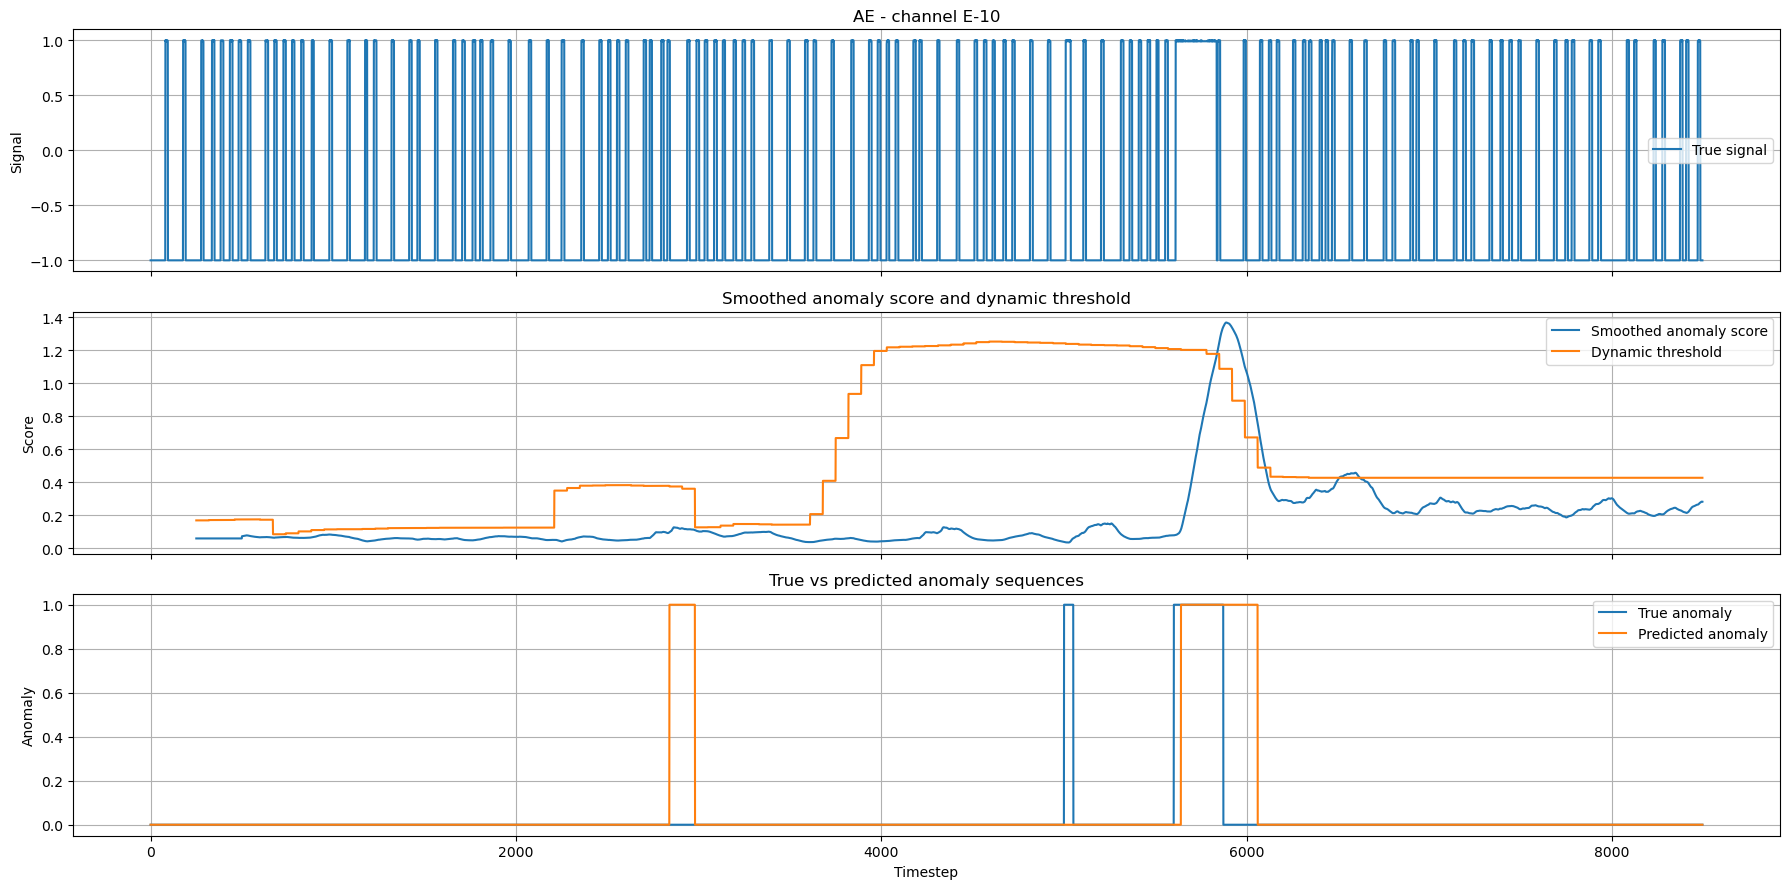

In [87]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=ae_smoothed_scores,
    thresholds=ae_thresholds,
    predictions_binary=ae_predictions_binary,
    model_name="AE"
)

The diagnostic plot for channel E-10 shows the behaviour of the Autoencoder reconstruction-based detector. The true signal is highly discrete and switches frequently between two main values. Despite this strong switching pattern, the smoothed reconstruction score remains relatively low for most of the test sequence, suggesting that the AE is able to reconstruct the normal alternating behaviour of the main telemetry feature reasonably well.

The reconstruction score exhibits one dominant peak around timestep 5800–6000. In this region, the score rises above the dynamic threshold and produces a predicted anomalous interval. This prediction overlaps with the main labelled anomaly interval, although it starts slightly later and extends beyond the true anomaly. This temporal enlargement is consistent with the EWMA smoothing and the error-buffering step, which tend to spread the final prediction around strong score peaks.

The earlier labelled anomaly, around timestep 5000, is not detected. In that region, the reconstruction score remains below the dynamic threshold. This indicates that the corresponding anomalous pattern is either too weak, too short, or still sufficiently reconstructible by the AE, so it does not generate a reconstruction error large enough to survive the post-processing pipeline.

The plot also shows one predicted anomalous interval around timestep 2800–3000 that does not overlap with a labelled anomaly. This is counted as a false positive at sequence level. The score in that region is not the dominant peak of the sequence, but the dynamic thresholding and buffering procedure still convert it into an anomalous interval.

Overall, for channel E-10, the AE detects one of the labelled anomaly sequences but misses another one, while also producing one false positive interval. This behaviour is consistent with the reported sequence-level metrics for this channel: precision `0.5`, recall `0.5`, and F1-score `0.5`. The result highlights a typical limitation of reconstruction-based detection: the model can react to strong deviations in the reconstructed target feature, but weaker or more locally reconstructible anomalies may remain below threshold.

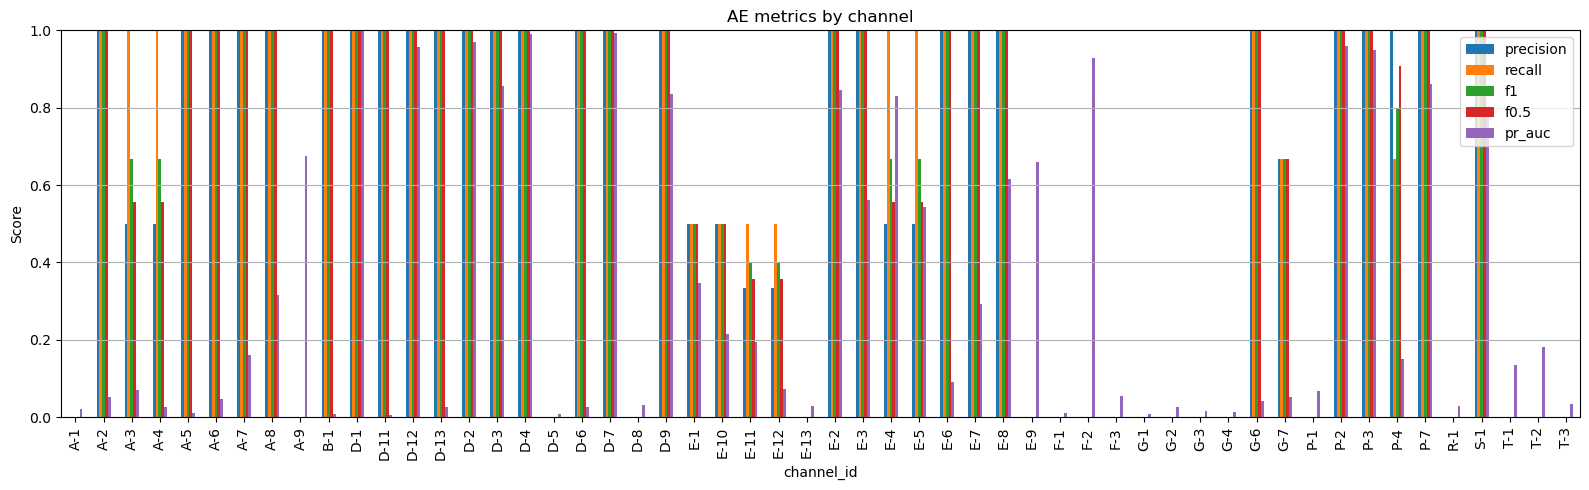

In [88]:
plot_overall_metrics(
    ae_results_df,
    method_name="AE"
)

### Random Forest Regressor Architecture

Unlike neural networks, Random Forest Regressor is not composed of differentiable layers and it is not trained through backpropagation. Instead, it is an ensemble of decision trees, where each tree learns a set of nonlinear splitting rules over the input features. The final prediction is obtained by averaging the predictions of all trees.

In this implementation, each multivariate telemetry window has shape `[window_size, n_features]`. Since a Random Forest does not process sequential tensors directly, each window is flattened into a one-dimensional vector before training. With `window_size = 250` and `n_features = 25`, each input sample is represented by `6250` lagged features. The temporal order is therefore not modeled recurrently, but it is still implicitly encoded by the fixed position of each lag inside the flattened vector.

The model is trained as a multi-output regressor. For each flattened input window, it predicts the next `n_predictions = 10` values of the main telemetry signal, corresponding to feature 0. During inference, these multi-step forecasts are aggregated into one prediction per test window using the same aggregation strategy adopted for the forecasting-based models.

The Random Forest used here contains `100` trees, with unrestricted maximum depth (`max_depth=None`) and `min_samples_leaf=1`. This gives the model high flexibility and allows it to capture nonlinear relationships between lagged telemetry values and future target values. The use of `random_state=42` makes the training reproducible, while `n_jobs=-1` enables parallel training across CPU cores.

From an anomaly detection perspective, the Random Forest does not directly classify windows as normal or anomalous. It first predicts the expected future behaviour of the main telemetry signal. The absolute difference between the aggregated prediction and the observed value is then used as the raw forecasting error. Large forecasting errors indicate that the future signal is not well explained by the recent multivariate context, and these errors are later passed through EWMA smoothing, dynamic thresholding, buffering and pruning.

In [32]:
def flatten_windows(X):
    X = np.asarray(X)
    return X.reshape(X.shape[0], -1)


def train_rf_channel(
    X_train,
    y_train,
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
):
    X_train_flat = flatten_windows(X_train)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=n_jobs
    )

    model.fit(X_train_flat, y_train)

    return model


def predict_rf_channel(model, X_test, batch_size=70):
    y_hat_list = []

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    for i in range(0, num_batches + 1):
        prior_idx = i * batch_size
        idx = (i + 1) * batch_size

        if i + 1 == num_batches + 1:
            idx = X_test.shape[0]

        X_test_batch = X_test[prior_idx:idx]

        if len(X_test_batch) == 0:
            continue

        X_test_flat = flatten_windows(X_test_batch)
        y_hat_batch = model.predict(X_test_flat)

        agg_y_hat_batch = aggregate_predictions(
            y_hat_batch,
            method="first"
        )

        y_hat_list.append(agg_y_hat_batch)

    return np.concatenate(y_hat_list).reshape(-1)

In [33]:
rf_models = {}
rf_predictions = {}
rf_errors = {}
rf_smoothed_errors = {}
rf_predictions_binary = {}
rf_thresholds = {}
rf_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training Random Forest Regressor for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model = train_rf_channel(
        X_train=X_train,
        y_train=y_train,
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    y_hat = predict_rf_channel(
        model=model,
        X_test=X_test,
        batch_size=70
    )

    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    rf_models[ch] = model
    rf_predictions[ch] = y_hat
    rf_errors[ch] = errors
    rf_smoothed_errors[ch] = smoothed_errors
    rf_predictions_binary[ch] = y_pred
    rf_thresholds[ch] = thresholds
    rf_metrics[ch] = metrics

    display(metrics)

Training Random Forest Regressor for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.302156,0.0


Training Random Forest Regressor for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.247185,0.017713


Training Random Forest Regressor for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,1.0,0.115327,0.077424


Training Random Forest Regressor for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.145622,0.040627


Training Random Forest Regressor for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.389709,0.0


In [34]:
rf_results_df, rf_summary_df = generate_results_view(rf_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.0,0.000000,0.000000,0.302156,0.000000
1,A-2,1,0,0,1.000000,1.0,1.000000,1.000000,0.247185,0.017713
2,A-3,1,0,0,1.000000,1.0,1.000000,1.000000,0.567473,0.034167
3,A-4,1,0,0,1.000000,1.0,1.000000,1.000000,0.788104,0.026022
4,A-5,1,0,0,1.000000,1.0,1.000000,1.000000,0.011650,0.074738
5,A-6,0,0,1,0.000000,0.0,0.000000,0.000000,0.032562,0.000000
6,A-7,1,1,0,0.500000,1.0,0.666667,0.555556,0.952028,0.101496
7,A-8,1,0,0,1.000000,1.0,1.000000,1.000000,0.285541,0.008368
8,A-9,1,0,0,1.000000,1.0,1.000000,1.000000,0.285343,0.016619
9,B-1,1,0,0,1.000000,1.0,1.000000,1.000000,0.009232,0.052278


TP                               47.000000
FP                               15.000000
FN                               21.000000
precision                         0.758065
recall                            0.691176
f1                                0.723077
f0.5                              0.743671
pr_auc_macro                      0.455941
predicted_anomaly_ratio_macro     0.043744
dtype: float64

### Random Forest Regressor Results Analysis

The Random Forest Regressor obtains a sequence-level precision of `0.758`, a recall of `0.691`, and an F1-score of `0.723`. Overall, this indicates that the forecasting-based baseline is able to detect a substantial portion of the labelled anomaly intervals while keeping false positive sequences relatively limited. Out of 68 labelled anomalous sequences, the model detects 47 and misses 21, while producing 15 false positive predicted sequences.

The precision is slightly higher than the recall, meaning that the model is more reliable when it raises an alarm than it is complete in detecting all anomaly intervals. The F0.5-score is `0.744`, which is higher than the F1-score because F0.5 gives more weight to precision. This suggests that the model has a reasonably selective behaviour: it does not simply mark large parts of the test timeline as anomalous to increase recall.

The predicted anomaly ratio is approximately `4.37%`, which confirms that the model produces a limited amount of final anomalous predictions. Therefore, the achieved recall is not due to excessive over-prediction. Instead, the Random Forest appears to detect many anomaly intervals through localized increases in forecasting error, while still avoiding a large number of scattered false alarms.

The per-channel results show heterogeneous behaviour. Several channels, including many `A-*`, `D-*`, `E-*`, `G-*`, `P-*`, and `T-*` streams, achieve perfect sequence-level detection. In these cases, the model is able to predict the future behaviour of the main telemetry signal accurately under nominal conditions, while anomalous intervals generate forecasting errors strong enough to pass the post-processing pipeline. However, some channels such as `A-1`, `A-6`, `D-5`, `D-8`, `E-13`, `P-1`, `R-1`, and `T-3` still have zero recall, indicating that not all anomaly types produce sufficiently distinctive forecasting errors.

The macro PR-AUC is `0.456`. This value indicates that the continuous forecasting scores contain useful ranking information in several channels, although the separation between anomalous and nominal timesteps is not uniformly strong across the dataset. Some channels show high PR-AUC but still zero final recall, which suggests that the score may contain anomaly-related information that is not always converted into binary detections by the dynamic thresholding and pruning stages.

Overall, the Random Forest Regressor provides a strong classical forecasting baseline. Despite not explicitly modelling temporal dependencies with recurrent memory, it can exploit the flattened lagged telemetry window to learn nonlinear relationships between recent multivariate context and future values of the main telemetry signal. Its results show that forecasting error is a meaningful anomaly signal for SMAP, although missed channels indicate that a non-recurrent ensemble model is not sufficient to robustly capture all contextual anomaly patterns.

In [35]:
save_results(rf_results_df,rf_summary_df,method_name="Random_Forest")

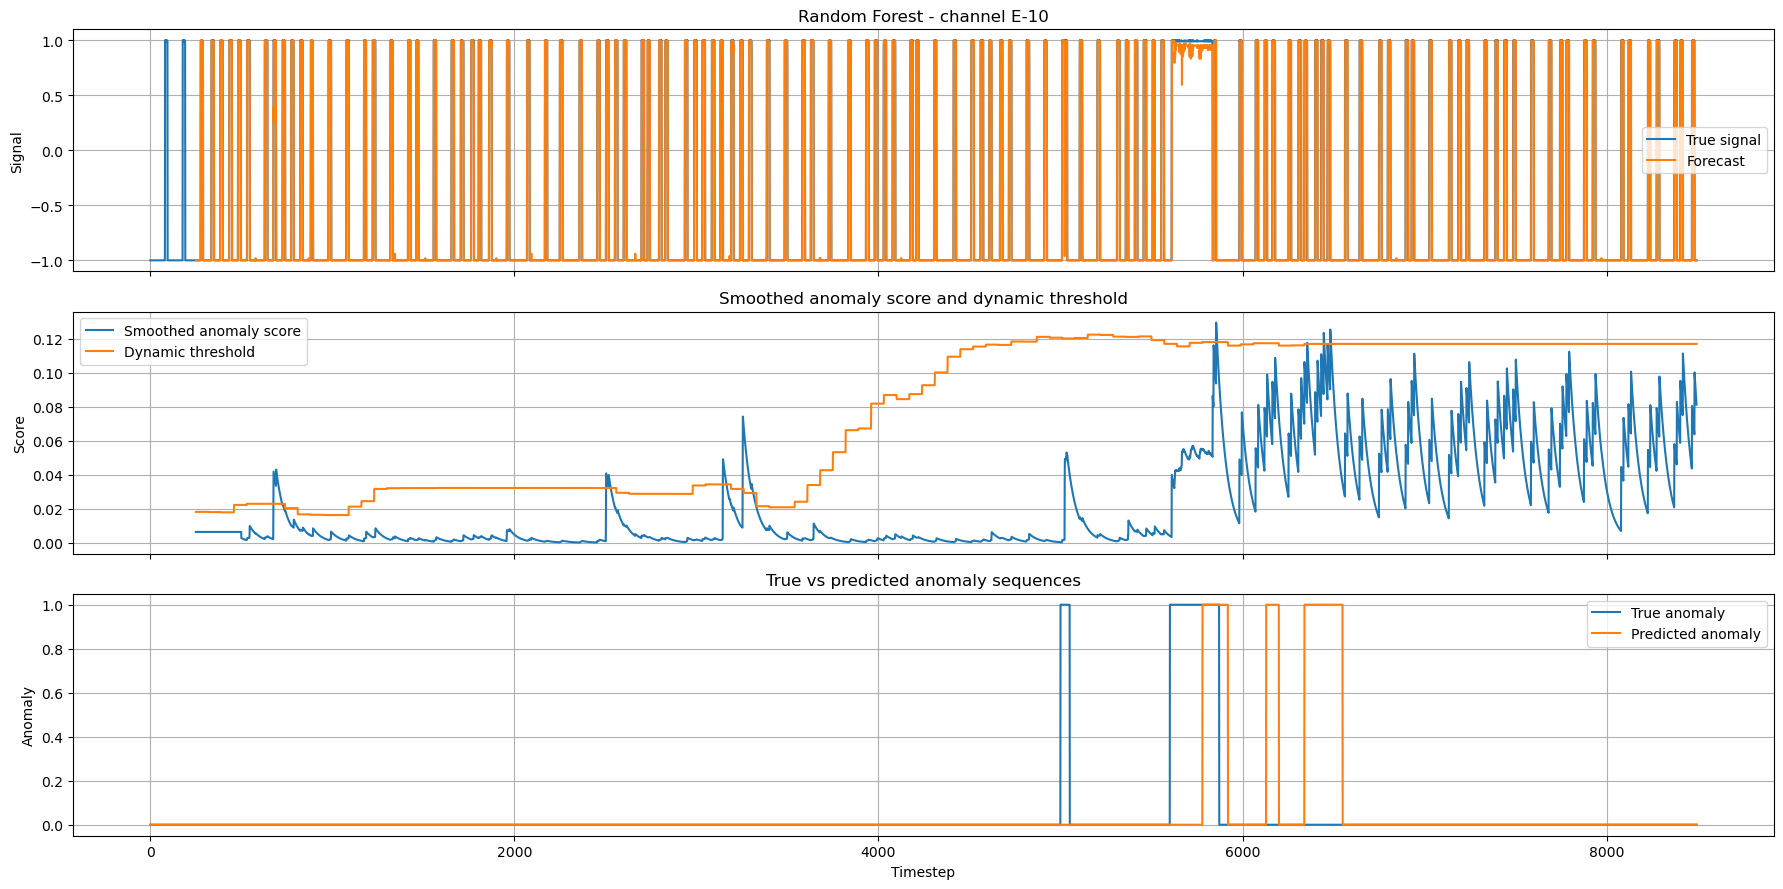

In [36]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=rf_predictions,
    smoothed_errors=rf_smoothed_errors,
    thresholds=rf_thresholds,
    predictions_binary=rf_predictions_binary,
    model_name="Random Forest"
)

For channel E-10, the Random Forest obtains a weak sequence-level result: `TP = 1`, `FP = 2`, `FN = 1`, with precision `0.333`, recall `0.5`, and F1-score `0.4`. The model detects only one of the two labelled anomaly intervals and generates two additional predicted anomalous sequences that do not overlap with the ground truth.

The main successful detection occurs around the larger anomalous region near timestep 5700–5900. In this interval, the forecasting error increases enough to exceed the dynamic threshold, producing an anomaly prediction that overlaps with the true labelled event. This indicates that the deviation in this region is sufficiently inconsistent with the recent telemetry history learned by the Random Forest.

However, the earlier labelled anomaly around timestep 5000 is missed. The anomaly score remains below the dynamic threshold in that region, so the corresponding deviation is not strong enough to be converted into a final detection. This suggests that this anomaly is either too short, too weak, or too similar to the normal switching dynamics of the channel to produce a large forecasting error.

The two false positive intervals after the main anomaly show the main limitation on this channel. After timestep 6000, the score becomes more unstable and repeatedly approaches or exceeds the threshold. These fluctuations are converted into predicted anomaly sequences even though no labelled anomaly is present. As a result, the model’s recall is only partial and its precision is substantially reduced.

Overall, channel E-10 shows that the Random Forest can react to the strongest contextual deviation, but it is less reliable when the anomaly is short or when post-anomaly forecasting errors remain noisy. The result is therefore a mixed detection pattern: one correctly detected anomaly, one missed anomaly, and two false alarms.

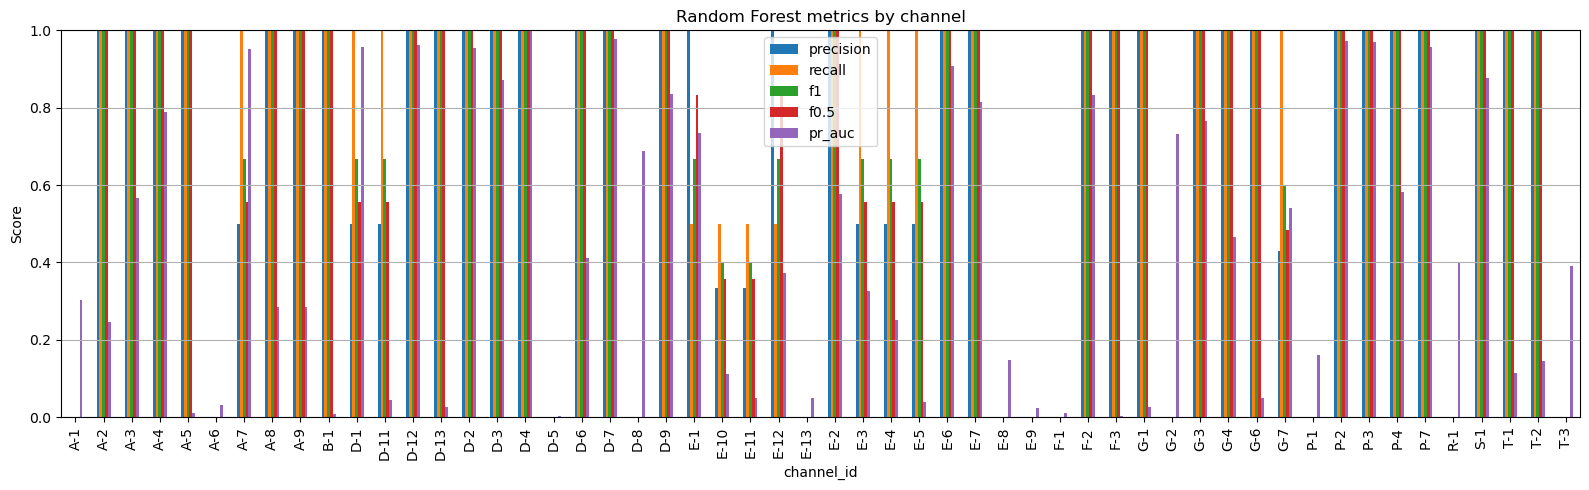

In [37]:
plot_overall_metrics(
    rf_results_df,
    method_name="Random Forest"
)

### Phase 0 Summary: Baseline Comparison

The Random Forest obtains stronger overall results than the Autoencoder. It detects `47` out of `68` labelled anomaly sequences, compared with `38` detected by the AE. This leads to a higher recall (`0.691` vs `0.559`) and a higher F1-score (`0.723` vs `0.628`). Precision also improves slightly, from `0.717` for the AE to `0.758` for the Random Forest, while the number of false positives remains the same (`15`). Therefore, the performance gain of the Random Forest is mainly due to detecting more true anomaly intervals, not to a less conservative post-processing behaviour.

The predicted anomaly ratio is also slightly lower for the Random Forest (`4.37%`) than for the AE (`4.95%`). This is important because the higher recall of the Random Forest is not obtained by marking a larger portion of the timeline as anomalous. Instead, the forecasting-based score seems to produce more useful anomaly peaks, allowing the dynamic thresholding pipeline to recover more labelled events with approximately the same false-positive cost.

The PR-AUC macro also increases from `0.346` for the AE to `0.456` for the Random Forest. Since PR-AUC is computed on the continuous anomaly scores before final binary evaluation, this suggests that the forecasting errors produced by the Random Forest provide a better ranking of anomalous versus nominal timesteps than the AE reconstruction errors. However, the value is still moderate, indicating that score quality remains heterogeneous across channels.

The phase therefore provides a first useful indication: for SMAP, even a classical forecasting model based on flattened windows performs better than a simple deterministic reconstruction model. This supports the idea that many anomalies in this dataset are contextual and temporal: they are more visible as deviations from expected future behaviour than as windows that are intrinsically difficult to reconstruct.

At the same time, the Random Forest is not a complete solution. It still misses `21` labelled anomaly sequences and produces `15` false positive sequences. Since it treats the flattened temporal window as a static feature vector, it does not explicitly model temporal dependencies or sequential dynamics. This leaves room for the next phases, where feed-forward neural models and recurrent architectures are tested to determine whether deeper representations and explicit temporal memory can further improve anomaly detection.

## Phase 1: Memory-less Deep Learning

Before deploying complex State-of-the-Art sequence models (like LSTMs or Transformers), it is strictly necessary to establish robust baselines. In this section, we introduce a **Multi-Layer Perceptron (MLP) Regressor** as our fundamental baseline for the deep forecasting approach, and **Multi-Layer Perceptron (MLP) Variational Autoencoder** for the reconstruction.

The rationale behind starting with a simple, fully-connected architecture is twofold:

1. **Isolating Temporal Memory:** An MLP requires flattening the temporal window into a single 1D vector, effectively treating time steps as independent spatial features. It lacks a built-in mechanism to capture sequential dependencies (like the hidden state of an RNN). This makes it the perfect **"memory-less" benchmark**. It allows us to measure how much predictive power can be extracted purely from the static local shape of the data, without complex temporal tracking.

2. **Pipeline Validation:** Using a lightweight model allows us to rapidly validate our entire post-processing pipeline—specifically the dynamic thresholding (Telemanom/Hundman style) and EWMA error smoothing—before introducing the computational overhead of Recurrent Neural Networks.

### Multi-Layer Perceptron (MLP) Regressor

The model acts as a deterministic mapping from a historical input window to a future prediction horizon. It is optimized by minimizing the Mean Squared Error (MSE) between its predicted future values ($\hat{y}_i$) and the actual incoming telemetry ($y_i$):

$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

During inference, the anomaly score is derived directly from the absolute forecasting error, specifically, the discrepancy between the model's first predicted step and the true incoming telemetry signal. 

In [38]:
def make_mlp_loader(X_windows, y_windows, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X_windows, dtype=torch.float32), 
        torch.tensor(y_windows, dtype=torch.float32)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In this implementation, each historical telemetry window $X_i \in \mathbb{R}^{250 \times 25}$ is similarly flattened into a vector of length 6250 before being passed to the MLP Regressor. Rather than mapping this input to a latent probability distribution, the network processes the vector through a sequence of deterministic hidden layers to extract complex spatial dependencies.

The flattened input $x$ is transformed through two fully connected layers alternated with Rectified Linear Unit (ReLU) activations and Dropout regularization:

$$
h_1 = \text{Dropout}(\text{ReLU}(W_1 x + b_1))
$$
$$
h_2 = \text{Dropout}(\text{ReLU}(W_2 h_1 + b_2))
$$

where Dropout acts as a vital regularizer to prevent the model from overfitting the high-frequency noise inherent in the spacecraft telemetry data.

A final linear head then maps the deep representation $h_2$ to the desired forecasting dimension, producing the predicted future window $\hat{y} \in \mathbb{R}^{n\_predictions}$:

$$
\hat{y} = W_3 h_2 + b_3
$$

The training objective is a straightforward regression task. The model is optimized by minimizing the Mean Squared Error (MSE) between the predicted horizon and the actual future telemetry values:

$$
\mathcal{L}_{MLP} = \frac{1}{n} \sum_{j=1}^{n} (y_j - \hat{y}_j)^2
$$

where $y_j$ is the ground-truth future sequence. Unlike the VAE, there is no probabilistic regularization term explicitly added to the loss function; the model relies entirely on its architectural constraints (bottlenecks and Dropout) to ensure generalization.

At inference time, the MLP anomaly score is computed at the timestep level as the absolute error between the model's first forecasted step and the true incoming telemetry signal: 
$$e_i = |\hat{y}_{i,0} - y_{i,0}|$$
The resulting score sequence is then processed with the exact same EWMA smoothing, dynamic thresholding, buffering, inverse-error check, pruning, and sequence-based evaluation. 

In [39]:
class SMAPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_predictions=1, dropout=0.2):
        super().__init__()

        self.sequential = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout), 
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.head = nn.Linear(hidden_dim // 2, n_predictions)
    
    def forward(self, window):
        window_flat = window.reshape(window.size(0), -1)
        
        features = self.sequential(window_flat)
        y_pred = self.head(features)
        return y_pred

In [40]:
def train_mlp_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_dim=128,
    dropout=0.2,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        y_tr = y_train[:-n_val]
        X_val = X_train[-n_val:]
        y_val = y_train[-n_val:]
    else:
        X_tr = X_train
        y_tr = y_train
        X_val = None
        y_val = None

    train_loader = make_mlp_loader(
        X_tr,
        y_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_mlp_loader(
            X_val,
            y_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    model = SMAPRegressor(
        input_dim=input_size,
        hidden_dim=hidden_dim,
        n_predictions=n_predictions,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)

                    val_loss += loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch+1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history


def predict_mlp_channel(model, X_test, batch_size=70, device="cpu"):
    model.eval()
    y_hat_list = []

    num_batches = int((X_test.shape[0] - 250) / batch_size)

    if num_batches < 0:
        raise ValueError(f"l_s=250 too large for stream length {X_test.shape[0]}.")

    with torch.no_grad():
        for i in range(0, num_batches + 1):
            prior_idx = i * batch_size
            idx = (i + 1) * batch_size

            if i + 1 == num_batches + 1:
                idx = X_test.shape[0]

            X_test_batch = X_test[prior_idx:idx]

            if len(X_test_batch) == 0:
                continue

            X_tensor = torch.tensor(X_test_batch, dtype=torch.float32, device=device)

            y_hat_batch = model(X_tensor).detach().cpu().numpy()

            agg_y_hat_batch = aggregate_predictions(
                y_hat_batch,
                method="first"
            )

            y_hat_list.append(agg_y_hat_batch)

    return np.concatenate(y_hat_list).reshape(-1)

In [41]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [42]:
mlp_models = {}
mlp_histories = {}
mlp_predictions = {}
mlp_errors = {}
mlp_smoothed_errors = {}
mlp_predictions_binary = {}
mlp_thresholds = {}
mlp_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training MLP for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_mlp_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[1] * X_train.shape[2],
        hidden_dim=128,
        dropout=0.2,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    y_hat = predict_mlp_channel(
        model=model,
        X_test=X_test,
        batch_size=70,
        device=device
    )

    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    mlp_models[ch] = model.to("cpu")
    mlp_histories[ch] = history
    mlp_predictions[ch] = y_hat
    mlp_errors[ch] = errors
    mlp_smoothed_errors[ch] = smoothed_errors
    mlp_predictions_binary[ch] = y_pred
    mlp_thresholds[ch] = thresholds
    mlp_metrics[ch] = metrics

    display(metrics)

Training MLP for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.246080 | val loss: 0.020975
Epoch 02 | train loss: 0.064147 | val loss: 0.003127
Epoch 03 | train loss: 0.043871 | val loss: 0.002130
Epoch 04 | train loss: 0.038241 | val loss: 0.003538
Epoch 05 | train loss: 0.032716 | val loss: 0.008341
Epoch 06 | train loss: 0.029692 | val loss: 0.003498
Epoch 07 | train loss: 0.027885 | val loss: 0.003139
Epoch 08 | train loss: 0.025574 | val loss: 0.004324
Epoch 09 | train loss: 0.025745 | val loss: 0.004950
Epoch 10 | train loss: 0.022801 | val loss: 0.001158
Epoch 11 | train loss: 0.021884 | val loss: 0.001957
Epoch 12 | train loss: 0.021862 | val loss: 0.001519
Epoch 13 | train loss: 0.018824 | val loss: 0.001656
Epoch 14 | train loss: 0.018713 | val loss: 0.004277
Epoch 15 | train loss: 0.017409 | val loss: 0.004626
Epoch 16 | train loss: 0.017387 | val loss: 0.002021
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.345438,0.008111


Training MLP for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.121097 | val loss: 0.046058
Epoch 02 | train loss: 0.056232 | val loss: 0.040678
Epoch 03 | train loss: 0.045857 | val loss: 0.041602
Epoch 04 | train loss: 0.040059 | val loss: 0.041974
Epoch 05 | train loss: 0.037524 | val loss: 0.040838
Epoch 06 | train loss: 0.034272 | val loss: 0.040921
Epoch 07 | train loss: 0.033440 | val loss: 0.040156
Epoch 08 | train loss: 0.031529 | val loss: 0.040794
Epoch 09 | train loss: 0.030420 | val loss: 0.039924
Epoch 10 | train loss: 0.029404 | val loss: 0.039220
Epoch 11 | train loss: 0.029286 | val loss: 0.037596
Epoch 12 | train loss: 0.027837 | val loss: 0.038137
Epoch 13 | train loss: 0.027468 | val loss: 0.039236
Epoch 14 | train loss: 0.028168 | val loss: 0.038769
Epoch 15 | train loss: 0.026321 | val loss: 0.040804
Epoch 16 | train loss: 0.025534 | val loss: 0.038939
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.252748,0.026569


Training MLP for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.084140 | val loss: 0.034235
Epoch 02 | train loss: 0.042853 | val loss: 0.030643
Epoch 03 | train loss: 0.032817 | val loss: 0.027792
Epoch 04 | train loss: 0.027379 | val loss: 0.023753
Epoch 05 | train loss: 0.023759 | val loss: 0.024873
Epoch 06 | train loss: 0.021719 | val loss: 0.023545
Epoch 07 | train loss: 0.020303 | val loss: 0.021890
Epoch 08 | train loss: 0.019388 | val loss: 0.023504
Epoch 09 | train loss: 0.018782 | val loss: 0.022671
Epoch 10 | train loss: 0.018388 | val loss: 0.021454
Epoch 11 | train loss: 0.018261 | val loss: 0.022883
Epoch 12 | train loss: 0.018113 | val loss: 0.023555
Epoch 13 | train loss: 0.018212 | val loss: 0.024429
Epoch 14 | train loss: 0.016828 | val loss: 0.021608
Epoch 15 | train loss: 0.016336 | val loss: 0.022137
Epoch 16 | train loss: 0.016783 | val loss: 0.023437
Epoch 17 | train lo

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,2,0,0,1.0,1.0,1.0,1.0,0.267556,0.08498


Training MLP for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.286550 | val loss: 0.150963
Epoch 02 | train loss: 0.055595 | val loss: 0.150672
Epoch 03 | train loss: 0.038201 | val loss: 0.146423
Epoch 04 | train loss: 0.032830 | val loss: 0.142355
Epoch 05 | train loss: 0.030593 | val loss: 0.139669
Epoch 06 | train loss: 0.027705 | val loss: 0.139931
Epoch 07 | train loss: 0.026297 | val loss: 0.140002
Epoch 08 | train loss: 0.025489 | val loss: 0.141218
Epoch 09 | train loss: 0.023052 | val loss: 0.137659
Epoch 10 | train loss: 0.021776 | val loss: 0.138834
Epoch 11 | train loss: 0.020490 | val loss: 0.134106
Epoch 12 | train loss: 0.021337 | val loss: 0.139801
Epoch 13 | train loss: 0.020287 | val loss: 0.134904
Epoch 14 | train loss: 0.019545 | val loss: 0.137625
Epoch 15 | train loss: 0.019935 | val loss: 0.134344
Epoch 16 | train loss: 0.017978 | val loss: 0.135688
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.219552,0.024376


Training MLP for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.242484 | val loss: 0.012390
Epoch 02 | train loss: 0.057772 | val loss: 0.001749
Epoch 03 | train loss: 0.038498 | val loss: 0.003392
Epoch 04 | train loss: 0.031789 | val loss: 0.005099
Epoch 05 | train loss: 0.026085 | val loss: 0.003687
Epoch 06 | train loss: 0.024096 | val loss: 0.003533
Epoch 07 | train loss: 0.021972 | val loss: 0.002754
Epoch 08 | train loss: 0.021128 | val loss: 0.000474
Epoch 09 | train loss: 0.020602 | val loss: 0.004577
Epoch 10 | train loss: 0.019161 | val loss: 0.000394
Epoch 11 | train loss: 0.018370 | val loss: 0.000787
Epoch 12 | train loss: 0.019364 | val loss: 0.002935
Epoch 13 | train loss: 0.017110 | val loss: 0.000283
Epoch 14 | train loss: 0.016404 | val loss: 0.000304
Epoch 15 | train loss: 0.015110 | val loss: 0.000343
Epoch 16 | train loss: 0.014587 | val loss: 0.001388
Epoch 17 | train lo

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,1,2,0.0,0.0,0.0,0.0,0.052721,0.01342


In [43]:
mlp_results_df, mlp_summary_df = generate_results_view(mlp_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.345438,0.008111
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.252748,0.026569
2,A-3,1,2,0,0.333333,1.000000,0.500000,0.384615,0.553898,0.088713
3,A-4,1,1,0,0.500000,1.000000,0.666667,0.555556,0.552153,0.043371
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.027524,0.059791
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.279369,0.069097
6,A-7,1,0,0,1.000000,1.000000,1.000000,1.000000,0.960788,0.048718
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.345343,0.075314
8,A-9,1,1,0,0.500000,1.000000,0.666667,0.555556,0.984055,0.059236
9,B-1,1,1,0,0.500000,1.000000,0.666667,0.555556,0.009272,0.060866


TP                               53.000000
FP                               24.000000
FN                               15.000000
precision                         0.688312
recall                            0.779412
f1                                0.731034
f0.5                              0.704787
pr_auc_macro                      0.461337
predicted_anomaly_ratio_macro     0.048526
dtype: float64

### MLP Regressor Results Analysis

The MLP Regressor obtains a sequence-level precision of `0.688`, a recall of `0.779`, and an F1-score of `0.731`. Overall, this indicates that the feed-forward forecasting model detects a large portion of the labelled anomaly intervals, with `53` true positives out of `68` labelled anomaly sequences. However, this higher coverage comes with `24` false positive predicted sequences, meaning that the model is less selective than the previous forecasting baseline.

The recall is higher than the precision, showing that the MLP tends to favour detection coverage over alarm reliability. This behaviour is also reflected by the F0.5-score of `0.705`, which is lower than the F1-score because F0.5 gives more weight to precision. Therefore, the model is effective at reducing missed anomalies, but it pays for this improvement with a higher number of false alarms.

The predicted anomaly ratio is approximately `4.85%`, which is not excessively high and remains close to the other baseline models. This suggests that the increase in false positives is not due to a trivial over-labelling of the entire test timeline, but rather to specific channels where the forecasting error produces additional anomalous intervals. In other words, the model is more sensitive, but not globally degenerate.

The per-channel results confirm this mixed behaviour. Many channels achieve perfect sequence-level detection, especially several `A-*`, `D-*`, `E-*`, `G-*`, `P-*`, and `T-*` channels. This shows that the MLP can extract useful nonlinear information from the flattened temporal window, even without recurrent memory. At the same time, some channels remain problematic, such as `D-5`, `D-6`, `E-13`, `F-3`, `G-3`, `R-1`, and `T-3`, where the model either misses the labelled anomalies or produces false positive intervals without detecting the true ones.

The macro PR-AUC is `0.461`, indicating that the continuous forecasting scores contain a moderate amount of useful ranking information. The value is slightly above the Random Forest baseline, but still far from ideal, which means that the separation between anomalous and nominal timesteps remains channel-dependent. This is consistent with the sequence-level results: the MLP improves coverage, but its score quality is not uniformly stable across all telemetry streams.

Overall, the MLP Regressor provides a strong memory-less deep forecasting baseline. Its results show that a fully connected network can exploit the flattened multivariate history to detect many contextual anomalies, even without explicit temporal recurrence. The main limitation is reduced precision: the model is more sensitive than selective, and this leads to more false positive sequences. This makes the MLP useful for testing how far deep nonlinear feature extraction can go before introducing recurrent temporal memory in the next phase.

In [44]:
save_results(mlp_results_df, mlp_summary_df,method_name='MLP')

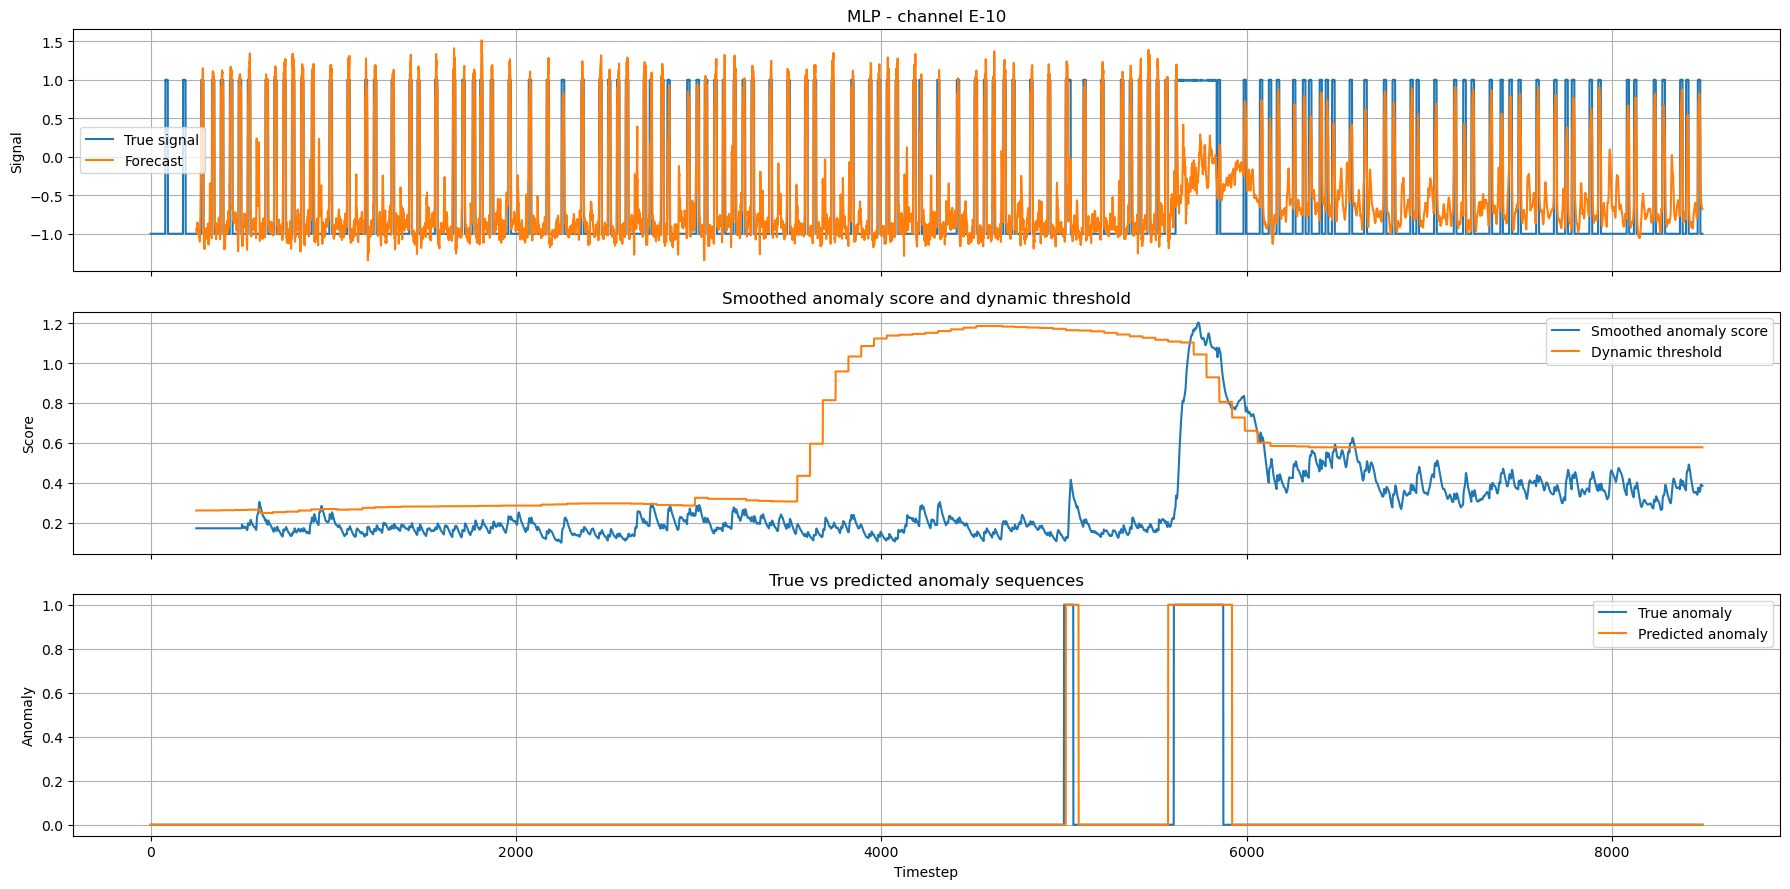

In [45]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=mlp_predictions,
    smoothed_errors=mlp_smoothed_errors,
    thresholds=mlp_thresholds,
    predictions_binary=mlp_predictions_binary,
    model_name="MLP"
)

For channel E-10, the MLP Regressor obtains a strong sequence-level result: `TP = 2`, `FP = 0`, `FN = 0`, with precision `1.0`, recall `1.0`, and F1-score `1.0`. The model detects both labelled anomaly intervals and does not generate any additional false positive sequence.

The first labelled anomaly, around timestep 5000, is correctly detected. This is an important improvement for this channel because the anomaly is short and can easily be missed if the forecasting error does not rise sharply enough. In this case, the MLP produces a localized score increase that is sufficient to pass the dynamic threshold and generate an overlapping predicted interval.

The second, larger anomaly around timestep 5600–5900 is also detected. The anomaly score increases strongly in this region, producing a predicted interval that overlaps well with the labelled anomalous sequence. The predicted region is slightly widened, which is expected after EWMA smoothing and error buffering, but it remains aligned with the true event and does not create an additional false positive.

Compared with the previous behaviour observed on this channel, the MLP produces a cleaner detection pattern: both anomaly sequences are covered, while post-anomaly score fluctuations after timestep 6000 remain below the final detection threshold. This indicates that, for E-10, the feed-forward neural model captures the local forecasting structure better and produces anomaly scores that are more useful for the Telemanom-style post-processing pipeline.

Overall, channel E-10 is a successful case for the MLP Regressor. The model is sensitive enough to detect both the short and the larger anomaly, but not so unstable as to produce extra false alarms. This supports the idea that a flattened-window neural model can already extract useful nonlinear temporal-context information, even without recurrent memory.

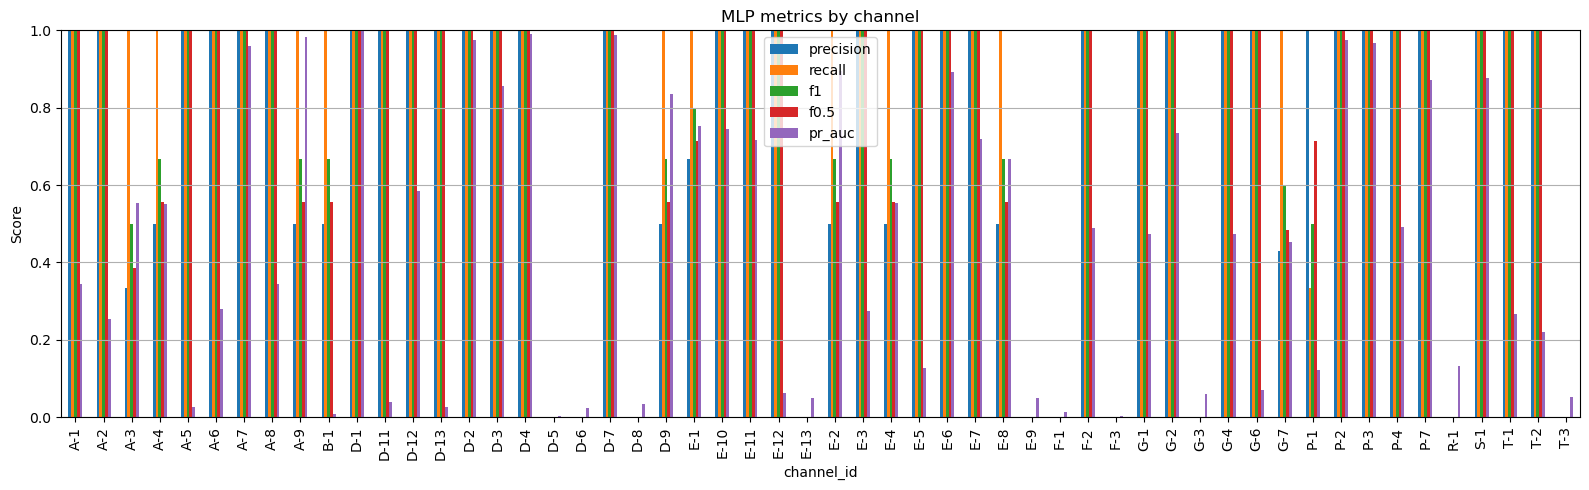

In [46]:
plot_overall_metrics(
    mlp_results_df,
    method_name="MLP"
)

### Multi-Layer Perceptron Variational Autoencoder (MLP-VAE)

The VAE operates as a probabilistic extension of the standard deterministic Autoencoder. Instead of mapping each input window rigidly to a single latent vector, the encoder maps the flattened input to a latent probability distribution, defined mathematically as:

$$
q_\phi(z|x) = \mathcal{N}(\mu(x), \operatorname{diag}(\sigma^2(x)))
$$

A latent sample is then drawn using the reparameterization trick and passed to the decoder, which attempts to reconstruct the original input window. The model is optimized by minimizing a loss function composed of two distinct terms: a reconstruction error and a Kullback-Leibler (KL) divergence regularization term. The reconstruction term encourages high fidelity between the input and the output, while the KL divergence constrains the latent distribution, pushing it toward a standard normal prior:

$$
p(z) = \mathcal{N}(0, I)
$$

During inference, the anomaly score is derived directly from the VAE's reconstruction error. The underlying assumption is that windows generated by nominal telemetry behavior will be mapped to dense, well-learned regions of the latent space and reconstructed accurately, whereas anomalous windows will fall outside this manifold and produce significantly higher reconstruction errors.

In [47]:
class VAEDataset(Dataset):
    def __init__(self, X):
        X = np.asarray(X)
        self.X = torch.tensor(X.reshape(X.shape[0], -1), dtype=torch.float32)      # Flattened 

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


def make_vae_loader(X, batch_size=64, shuffle=True):
    dataset = VAEDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In this implementation, each telemetry window $X_i \in \mathbb{R}^{250 \times 25}$ is flattened into a vector of length 6250 before being passed to the VAE. The encoder first maps this vector to an intermediate representation and then produces two latent vectors: the mean $\mu$ and the log-variance $\log \sigma^2$. The use of `logvar` improves numerical stability and ensures that the variance is positive after exponentiation.

The latent vector is sampled through the reparameterization trick:

$$
z = \mu + \sigma \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)
$$

In the code, this operation is implemented by the `reparameterize` function. First, the standard deviation is recovered from the predicted log-variance:

$$
\sigma = \exp\left(\frac{1}{2}\log\sigma^2\right)
$$

Then, a random noise vector $\epsilon$ is sampled from a standard normal distribution with the same shape as $\sigma$. The latent vector is obtained as:

$$
z = \mu + \sigma \epsilon
$$

This avoids sampling directly from $\mathcal{N}(\mu, \sigma^2)$. Instead, the randomness is isolated in $\epsilon$, while $\mu$ and $\sigma$ remain differentiable outputs of the encoder. This is necessary to train the VAE with backpropagation.

The decoder then maps $z$ back to the original input dimension, producing a reconstructed version of the flattened telemetry window.

The training objective is:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{recon}
+
\beta \mathcal{L}_{KL}
$$

where $\mathcal{L}_{recon}$ is the mean squared reconstruction error and $\mathcal{L}_{KL}$ penalizes deviations of the learned latent distribution from the standard normal prior. In this project, $\beta$ is kept small so that the model mainly focuses on reconstruction quality while still preserving a regularized latent space.

At inference time, the VAE anomaly score is computed at window level as the reconstruction error plus the weighted KL term. The resulting score sequence is then processed with the same EWMA smoothing, dynamic thresholding, buffering, inverse-error check, pruning, and sequence-based evaluation used for the LSTM pipeline. This makes the comparison fair at the detection stage, while keeping the modeling assumption different: reconstruction for the VAE, forecasting for the LSTM.

In [48]:
class VAE(nn.Module):
    def __init__(self, input_size, latent_size=16):
        super().__init__()

        self.input_size = input_size
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        self.mu_layer = nn.Linear(128, latent_size)
        self.logvar_layer = nn.Linear(128, latent_size)

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_size)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        x_recon = self.decoder(z)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

#### VAE Loss and Anomaly Score

The VAE loss combines reconstruction quality and latent-space regularization:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{recon}
+
\beta \mathcal{L}_{KL}
$$

where the reconstruction term is the MSE between the input window $x$ and its reconstruction $\hat{x}$:

$$
\mathcal{L}_{recon} = \text{MSE}(\hat{x}, x)
$$

and the KL term penalizes latent distributions that move too far from the standard normal prior $p(z)=\mathcal{N}(0,I)$:

$$
\mathcal{L}_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2
\right)
$$

At inference time, the anomaly score is computed per window as reconstruction error plus the weighted KL term:

$$
s(x) = \text{reconstruction error} + \beta \cdot \text{KL error}
$$

A high score indicates that the window is difficult to reconstruct, has an irregular latent representation, or both. The resulting score sequence is then processed with the same EWMA smoothing, dynamic thresholding, buffering, pruning, and sequence-based evaluation.

In [89]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

def compute_vae_scores(model, X, batch_size=64, device="cpu"):
    """
    Compute one reconstruction anomaly score per test window.

    The VAE reconstructs the full multivariate window, but the anomaly score is
    computed only on feature 0, i.e. the main telemetry signal.
    The KL term is used during training, but not directly added to the final
    anomaly score.
    """

    model.eval()
    scores = []

    window_size = X.shape[1]
    n_features = X.shape[2]

    dataset = VAEDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for X_batch_flat in loader:
            X_batch_flat = X_batch_flat.to(device)

            x_recon_flat, mu, logvar = model(X_batch_flat)

            X_batch = X_batch_flat.reshape(-1, window_size, n_features)
            x_recon = x_recon_flat.reshape(-1, window_size, n_features)

            recon_error = torch.mean(
                (X_batch[:, :, 0] - x_recon[:, :, 0]) ** 2,
                dim=1
            )

            scores.append(recon_error.cpu().numpy())

    return np.concatenate(scores)

In [90]:
def train_vae_channel(
    X_train,
    latent_size=16,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    beta=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_vae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_vae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[1] * X_train.shape[2]

    model = VAE(
        input_size=input_size,
        latent_size=latent_size
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_recon = 0.0
        train_kl = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            x_recon, mu, logvar = model(X_batch)

            loss, recon_loss, kl_loss = vae_loss(
                x_recon=x_recon,
                x=X_batch,
                mu=mu,
                logvar=logvar,
                beta=beta
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_recon += recon_loss.item() * X_batch.size(0)
            train_kl += kl_loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_recon /= len(train_loader.dataset)
        train_kl /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_recon = 0.0
            val_kl = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    x_recon, mu, logvar = model(X_batch)

                    loss, recon_loss, kl_loss = vae_loss(
                        x_recon=x_recon,
                        x=X_batch,
                        mu=mu,
                        logvar=logvar,
                        beta=beta
                    )

                    val_loss += loss.item() * X_batch.size(0)
                    val_recon += recon_loss.item() * X_batch.size(0)
                    val_kl += kl_loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)
            val_recon /= len(val_loader.dataset)
            val_kl /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": val_loss,
                "val_recon_loss": val_recon,
                "val_kl_loss": val_kl
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": np.nan,
                "val_recon_loss": np.nan,
                "val_kl_loss": np.nan
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f}"
            )

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [91]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [92]:
vae_models = {}
vae_histories = {}
vae_scores = {}
vae_smoothed_scores = {}
vae_predictions_binary = {}
vae_thresholds = {}
vae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training VAE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_vae_channel(
        X_train=X_train,
        latent_size=16,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_vae_scores(
        model=model,
        X=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    vae_models[ch] = model.to("cpu")
    vae_histories[ch] = history
    vae_scores[ch] = scores
    vae_smoothed_scores[ch] = smoothed_scores
    vae_predictions_binary[ch] = y_pred
    vae_thresholds[ch] = thresholds
    vae_metrics[ch] = metrics

    display(metrics)

Training VAE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.033220 | val loss: 0.020327
Epoch 02 | train loss: 0.021766 | val loss: 0.018931
Epoch 03 | train loss: 0.021014 | val loss: 0.018497
Epoch 04 | train loss: 0.020685 | val loss: 0.018232
Epoch 05 | train loss: 0.020485 | val loss: 0.018138
Epoch 06 | train loss: 0.020381 | val loss: 0.018045
Epoch 07 | train loss: 0.020197 | val loss: 0.017894
Epoch 08 | train loss: 0.020019 | val loss: 0.017803
Epoch 09 | train loss: 0.019872 | val loss: 0.017725
Epoch 10 | train loss: 0.019918 | val loss: 0.017727
Epoch 11 | train loss: 0.019850 | val loss: 0.017622
Epoch 12 | train loss: 0.019702 | val loss: 0.017493
Epoch 13 | train loss: 0.019388 | val loss: 0.017358
Epoch 14 | train loss: 0.019306 | val loss: 0.017174
Epoch 15 | train loss: 0.019109 | val loss: 0.017129
Epoch 16 | train loss: 0.019002 | val loss: 0.017086
Epoch 17 | train loss: 0.018886 | val l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.027992,0.0


Training VAE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.035276 | val loss: 0.034283
Epoch 02 | train loss: 0.033325 | val loss: 0.033945
Epoch 03 | train loss: 0.032959 | val loss: 0.032732
Epoch 04 | train loss: 0.030451 | val loss: 0.029092
Epoch 05 | train loss: 0.027596 | val loss: 0.027307
Epoch 06 | train loss: 0.025835 | val loss: 0.026334
Epoch 07 | train loss: 0.025142 | val loss: 0.025514
Epoch 08 | train loss: 0.024701 | val loss: 0.024738
Epoch 09 | train loss: 0.024213 | val loss: 0.024773
Epoch 10 | train loss: 0.024009 | val loss: 0.024214
Epoch 11 | train loss: 0.023734 | val loss: 0.023996
Epoch 12 | train loss: 0.023627 | val loss: 0.023837
Epoch 13 | train loss: 0.023361 | val loss: 0.023772
Epoch 14 | train loss: 0.023250 | val loss: 0.023918
Epoch 15 | train loss: 0.023064 | val loss: 0.023530
Epoch 16 | train loss: 0.023078 | val loss: 0.023606
Epoch 17 | train loss: 0.023024 | val l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.034455,0.043269


Training VAE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.030635 | val loss: 0.029713
Epoch 02 | train loss: 0.028934 | val loss: 0.029398
Epoch 03 | train loss: 0.028787 | val loss: 0.029271
Epoch 04 | train loss: 0.028664 | val loss: 0.029087
Epoch 05 | train loss: 0.027590 | val loss: 0.027824
Epoch 06 | train loss: 0.026861 | val loss: 0.027179
Epoch 07 | train loss: 0.026326 | val loss: 0.026614
Epoch 08 | train loss: 0.024866 | val loss: 0.024667
Epoch 09 | train loss: 0.023671 | val loss: 0.023800
Epoch 10 | train loss: 0.023031 | val loss: 0.023292
Epoch 11 | train loss: 0.022712 | val loss: 0.023077
Epoch 12 | train loss: 0.022479 | val loss: 0.023020
Epoch 13 | train loss: 0.022448 | val loss: 0.022822
Epoch 14 | train loss: 0.022358 | val loss: 0.022858
Epoch 15 | train loss: 0.022341 | val loss: 0.022915
Epoch 16 | train loss: 0.022294 | val loss: 0.022700
Epoch 17 | train loss: 0.022073 | val l

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,1,2,0.0,0.0,0.0,0.0,0.112814,0.032551


Training VAE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.023894 | val loss: 0.016633
Epoch 02 | train loss: 0.019445 | val loss: 0.016059
Epoch 03 | train loss: 0.019058 | val loss: 0.015737
Epoch 04 | train loss: 0.017819 | val loss: 0.012321
Epoch 05 | train loss: 0.014514 | val loss: 0.011304
Epoch 06 | train loss: 0.013124 | val loss: 0.010126
Epoch 07 | train loss: 0.012019 | val loss: 0.009495
Epoch 08 | train loss: 0.011493 | val loss: 0.009033
Epoch 09 | train loss: 0.010908 | val loss: 0.009017
Epoch 10 | train loss: 0.010336 | val loss: 0.008377
Epoch 11 | train loss: 0.009962 | val loss: 0.008217
Epoch 12 | train loss: 0.009662 | val loss: 0.008119
Epoch 13 | train loss: 0.009359 | val loss: 0.007788
Epoch 14 | train loss: 0.009231 | val loss: 0.007908
Epoch 15 | train loss: 0.009134 | val loss: 0.007740
Epoch 16 | train loss: 0.008931 | val loss: 0.007666
Epoch 17 | train loss: 0.008890 | val l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.126906,0.0


Training VAE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.014138 | val loss: 0.002261
Epoch 02 | train loss: 0.003816 | val loss: 0.001275
Epoch 03 | train loss: 0.003204 | val loss: 0.000847
Epoch 04 | train loss: 0.002868 | val loss: 0.000631
Epoch 05 | train loss: 0.002640 | val loss: 0.000428
Epoch 06 | train loss: 0.002517 | val loss: 0.000329
Epoch 07 | train loss: 0.002444 | val loss: 0.000264
Epoch 08 | train loss: 0.002396 | val loss: 0.000231
Epoch 09 | train loss: 0.002368 | val loss: 0.000228
Epoch 10 | train loss: 0.002344 | val loss: 0.000174
Epoch 11 | train loss: 0.002327 | val loss: 0.000152
Epoch 12 | train loss: 0.002312 | val loss: 0.000166
Epoch 13 | train loss: 0.002305 | val loss: 0.000166
Epoch 14 | train loss: 0.002292 | val loss: 0.000125
Epoch 15 | train loss: 0.002286 | val loss: 0.000125
Epoch 16 | train loss: 0.002281 | val loss: 0.000160
Epoch 17 | train loss: 0.002276 | val l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.035832,0.0


In [94]:
vae_results_df,vae_summary_df = generate_results_view(vae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.000000,0.000000,0.000000,0.027992,0.000000
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.034455,0.043269
2,A-3,1,2,0,0.333333,1.000000,0.500000,0.384615,0.057926,0.112142
3,A-4,0,0,1,0.000000,0.000000,0.000000,0.000000,0.019080,0.000000
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011295,0.104634
5,A-6,0,1,1,0.000000,0.000000,0.000000,0.000000,0.025458,0.084628
6,A-7,0,0,1,0.000000,0.000000,0.000000,0.000000,0.160222,0.000000
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.284552,0.058577
8,A-9,1,0,0,1.000000,1.000000,1.000000,1.000000,0.286093,0.008310
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009339,0.060991


TP                               31.000000
FP                               17.000000
FN                               37.000000
precision                         0.645833
recall                            0.455882
f1                                0.534483
f0.5                              0.596154
pr_auc_macro                      0.306496
predicted_anomaly_ratio_macro     0.047253
dtype: float64

### MLP-VAE Results Analysis

The MLP-VAE obtains a sequence-level precision of `0.646`, a recall of `0.456`, and an F1-score of `0.534`. Overall, this indicates a weaker reconstruction-based performance compared with the forecasting model in the same phase. Out of `68` labelled anomaly sequences, the model detects `31` and misses `37`, while producing `17` false positive predicted sequences.

The precision is higher than the recall, meaning that the model is more reliable when it raises an alarm than it is complete in detecting all true anomaly intervals. The F0.5-score is `0.596`, higher than the F1-score because it gives more weight to precision. This suggests a moderately conservative behaviour: the MLP-VAE does not generate an excessive number of alarms, but many labelled anomalies remain undetected.

The predicted anomaly ratio is approximately `4.73%`, which is comparable to the other models considered so far. Therefore, the low recall is not caused by a trivial absence of predictions over the whole test set. Instead, the model does produce anomaly intervals, but these intervals are not consistently aligned with the labelled anomaly sequences across channels.

The per-channel results are highly heterogeneous. Several channels, especially some `A-*`, `D-*`, `E-*`, `P-*`, and `S-*` streams, are detected perfectly. However, many other channels have zero recall, including `A-1`, `A-4`, `A-7`, `D-5`, `D-6`, `D-8`, `E-12`, `E-13`, `F-*`, several `G-*` channels, `P-1`, `P-4`, `R-1`, and the `T-*` channels. This shows that the VAE reconstruction score is not uniformly informative across the SMAP telemetry streams.

The macro PR-AUC is `0.306`, which indicates limited separation between anomalous and nominal timesteps at the continuous-score level. This is important because it suggests that the issue is not only the final thresholding stage: in many channels, the reconstruction error itself does not rank anomalous points clearly above nominal ones. The probabilistic latent regularization therefore does not automatically improve anomaly-score quality in this setting.

Overall, the MLP-VAE provides a reconstruction-based probabilistic baseline, but its performance remains limited. Although the model reconstructs the full multivariate window, the final score is computed on feature 0 to stay aligned with the detection target. The results suggest that, for many SMAP channels, a flattened-window probabilistic reconstruction model does not produce reconstruction errors sharp or discriminative enough to detect contextual anomalies reliably under the common Telemanom-style post-processing pipeline.

In [95]:
save_results(vae_results_df,vae_summary_df,method_name='VAE')

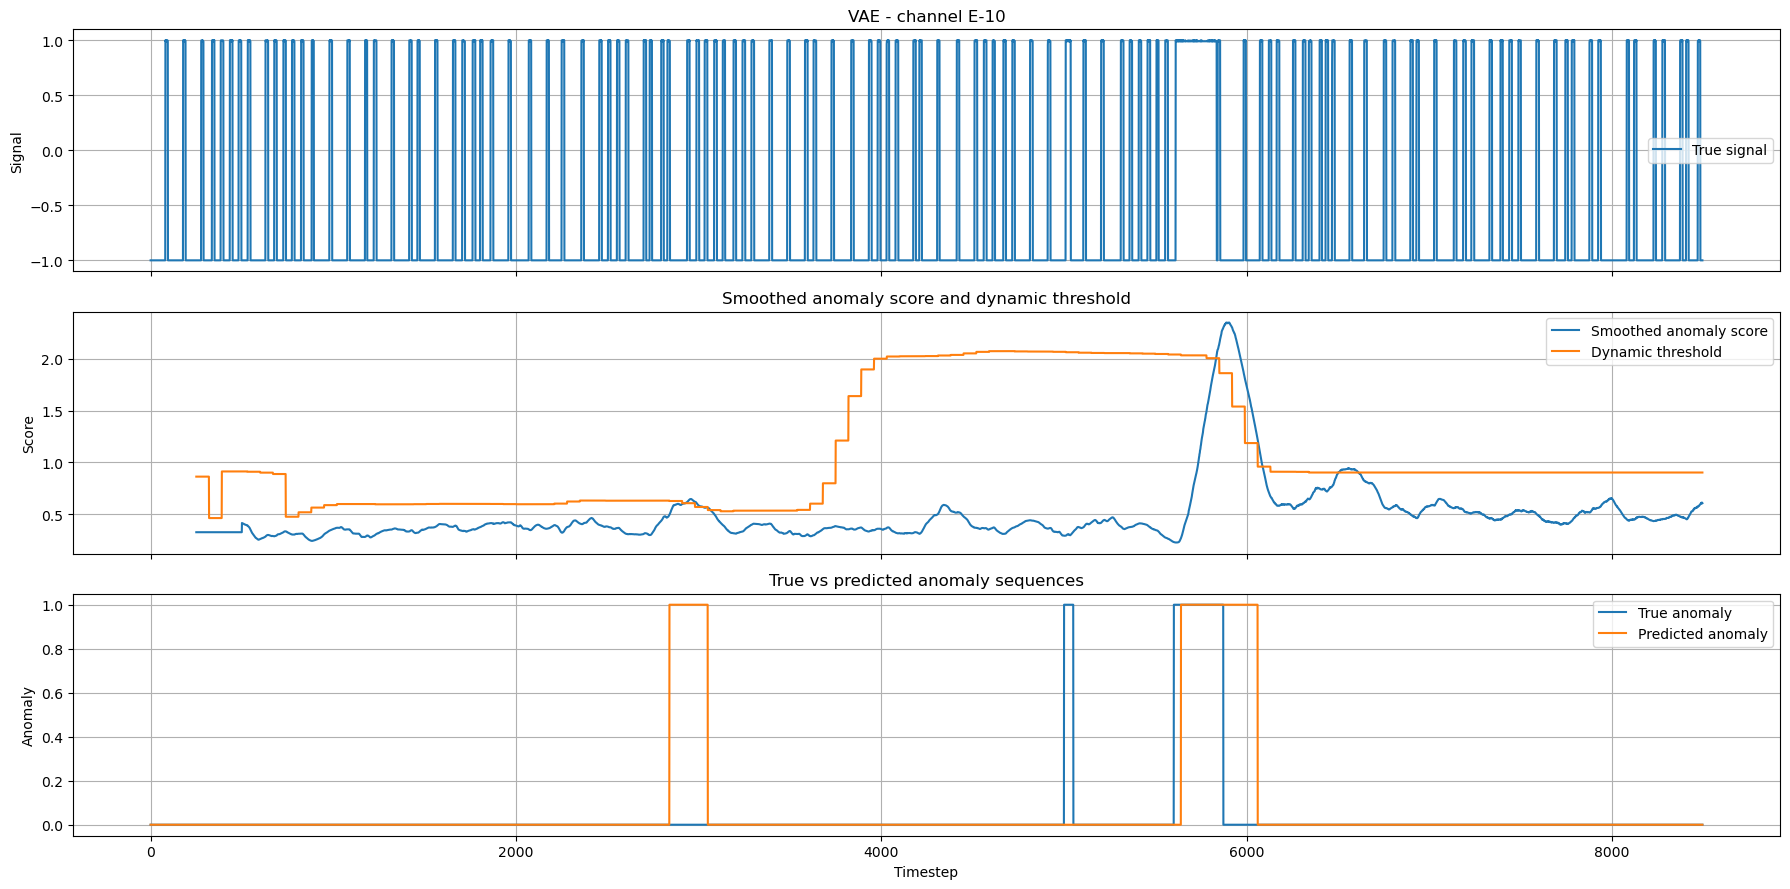

In [96]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=vae_smoothed_scores,
    thresholds=vae_thresholds,
    predictions_binary=vae_predictions_binary,
    model_name="VAE"
)

For channel E-10, the MLP-VAE obtains a partial sequence-level result: `TP = 1`, `FP = 1`, `FN = 1`, with precision `0.5`, recall `0.5`, and F1-score `0.5`. The model detects one of the two labelled anomaly intervals, misses the other one, and produces one additional false positive sequence.

The main detected anomaly is the larger interval around timestep 5600–6000. In this region, the reconstruction score rises sharply and crosses the dynamic threshold, producing a predicted anomaly that overlaps with the labelled event. This indicates that the VAE reconstruction error on feature 0 is sensitive to the strongest deviation in this channel.

The earlier labelled anomaly around timestep 5000 is not detected. Although the score shows some local variation before the main anomaly, it does not exceed the dynamic threshold in correspondence with this shorter labelled event. This suggests that the anomaly is either too weak or still sufficiently compatible with the normal reconstruction patterns learned by the VAE.

The false positive interval appears earlier in the sequence, around timestep 2800–3000. This region is not labelled as anomalous, but the post-processing pipeline converts a local score increase into an anomalous sequence. Therefore, on this channel, the VAE is not simply too conservative: it both misses one true anomaly and produces one spurious detection.

Overall, channel E-10 confirms the mixed behaviour observed in the aggregate MLP-VAE results. The model can react to the strongest reconstruction deviation, but its score is not discriminative enough to cleanly separate all labelled anomalies from nominal fluctuations. This leads to a balanced but limited result, with one correct detection, one missed anomaly, and one false alarm.

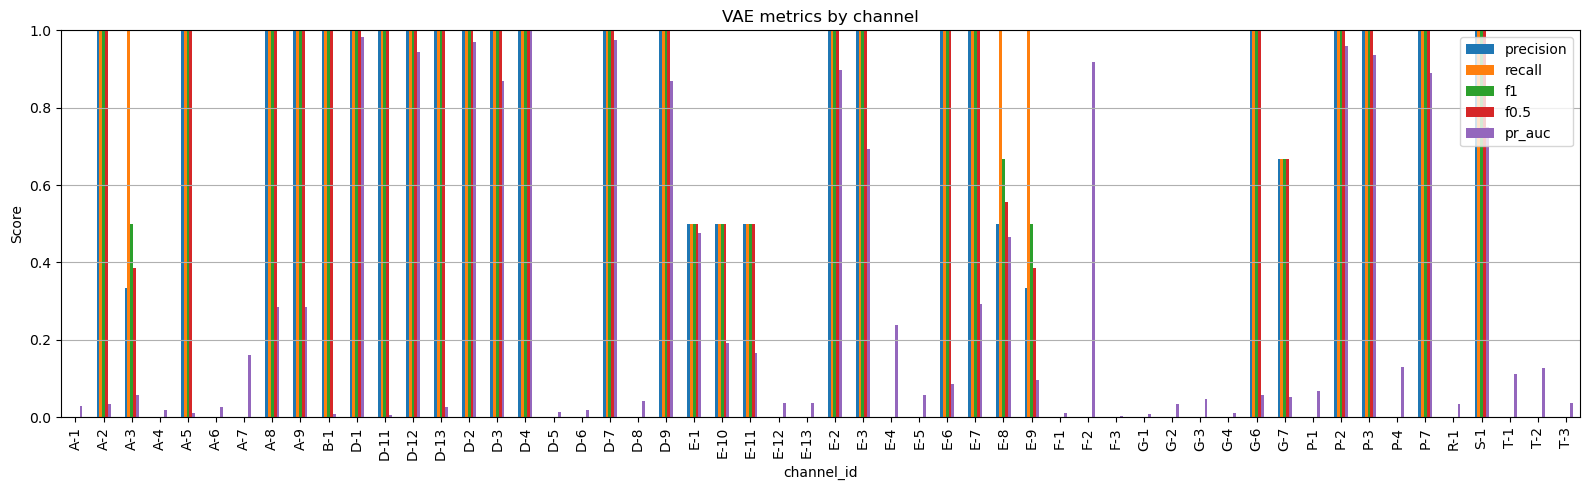

In [97]:
plot_overall_metrics(
    vae_results_df,
    method_name="VAE"
)

### Phase 1 Summary: Memory-less Deep Learning Comparison

The MLP Regressor clearly obtains stronger overall performance than the MLP-VAE. It detects `53` out of `68` labelled anomaly sequences, while the MLP-VAE detects only `31`. This leads to a much higher recall for the MLP Regressor (`0.779` vs `0.456`) and a higher F1-score (`0.731` vs `0.534`). The MLP-VAE has slightly lower false positives (`17` vs `24`), but this comes at the cost of missing many more true anomaly intervals (`37` false negatives vs `15` for the MLP Regressor).

The two models therefore show opposite behaviours. The MLP Regressor is more sensitive: it detects many more anomalies, but it also produces more false positive sequences. This is reflected by its lower precision (`0.688`) and higher recall (`0.779`). The MLP-VAE is more conservative: it produces fewer false positives, but it misses a much larger fraction of labelled anomalies. Its higher precision relative to recall (`0.646` vs `0.456`) indicates that when it raises an alarm it is moderately reliable, but it does not cover enough anomalous events.

The predicted anomaly ratios are similar: approximately `4.85%` for the MLP Regressor and `4.73%` for the MLP-VAE. This is an important point, because the MLP Regressor does not obtain higher recall by simply marking much more of the timeline as anomalous. Instead, its forecasting error appears to be better aligned with the labelled anomaly intervals. The MLP-VAE produces a comparable amount of anomaly predictions, but these predictions are less consistently placed on true anomalous regions.

The macro PR-AUC also slightly favours the MLP Regressor (`0.461` vs `0.306`). Since PR-AUC evaluates the continuous anomaly scores before final thresholding, this suggests that the forecasting scores generated by the MLP provide a better ranking of anomalous and nominal timesteps than the reconstruction scores produced by the MLP-VAE. The VAE latent regularization does not appear to improve score separability in this setting.

The main conclusion of Phase 1 is that, even without recurrent memory, the forecasting-based deep model is more effective than the reconstruction-based probabilistic model for SMAP. This supports the idea that many anomalies in this dataset are better exposed as deviations from expected future behaviour than as windows that are difficult to reconstruct. At the same time, the MLP Regressor still produces a non-negligible number of false positives, indicating that feed-forward forecasting is useful but not fully stable across all channels.

Compared with the intent of this phase, the results show that a flattened-window neural model can already extract meaningful anomaly-relevant information from the local telemetry context. Therefore, explicit temporal memory is not strictly necessary to obtain strong results. However, the remaining false positives and missed anomalies motivate Phase 2, where recurrent models are introduced to test whether modelling the sequential evolution of the telemetry stream can improve the precision-recall trade-off.

## Phase 2: Recurrent Temporal Modeling

In Phase 2, we introduce recurrent architectures to test whether explicitly modelling the temporal evolution of the telemetry signals improves anomaly detection. While the models in Phase 1 receive the temporal window as a flattened vector, the models in this phase process the window as an ordered sequence. This allows the architecture to track how the signal evolves step by step inside the input window.

The rationale behind this phase is twofold.

- First, it tests the value of **explicit temporal memory**. The LSTM Regressor is used as the forecasting-based recurrent model: it receives the recent multivariate telemetry history and predicts the next values of the main telemetry signal. Unlike the MLP Regressor, the LSTM does not treat the window as a static vector. Instead, it updates a hidden state across timesteps, allowing the model to learn temporal dependencies, delayed effects, and sequential patterns that may be relevant for contextual anomaly detection.

- Second, it evaluates whether temporal memory also improves the **reconstruction-based paradigm**. The LSTM-VAE receives the multivariate telemetry window as a sequence and reconstructs it through a recurrent variational encoder-decoder. The goal is to test whether a sequential latent representation can capture nominal temporal dynamics better than a feed-forward VAE. As in the other reconstruction-based models, the network reconstructs the full multivariate window, but the final anomaly score is computed on feature 0 to keep the detection target aligned with the forecasting models.

This phase is therefore designed to answer a specific question: are the remaining errors of the memory-less models due to the lack of explicit temporal modelling? If the recurrent models improve the precision-recall trade-off, this would suggest that SMAP anomalies depend on sequential dynamics that cannot be fully captured by flattened-window models. If the improvement is limited or absent, this would indicate that most useful anomaly information is already contained in the local window representation, and that recurrence may not be necessary under the current post-processing pipeline.

### LSTM Forecasting 

The LSTM Regressor uses the same forecasting windowing strategy adopted by the other forecasting-based models. For each SMAP channel, the input sample is a multivariate temporal window with shape

$[window\_size,\; n_{\text{features}}]$

where `window_size = 250` and `n_features = 25`. Unlike the Random Forest and MLP Regressor, this window is not flattened. The LSTM receives the window as an ordered sequence of 250 timesteps, where each timestep contains the 25 telemetry features.

The target associated with each input window is the future evolution of the main telemetry signal, i.e. feature 0, over the next `n_predictions = 10` timesteps. Therefore, the dataset has the form

$X_i \in \mathbb{R}^{250 \times 25}$

$y_i \in \mathbb{R}^{10}$

where $X_i$ contains the recent multivariate history and $y_i$ contains the next 10 values of the target telemetry channel.

For each channel, a separate `ForecastDataset` is created and wrapped into a PyTorch `DataLoader`. During training, the windows are shuffled at batch level, but the temporal order inside each window is preserved. This is acceptable because the LSTM still processes each individual window sequentially from timestep 1 to timestep 250. During validation and testing, shuffling is disabled to preserve the temporal order needed for prediction aggregation, score alignment and anomaly evaluation.

The training set is split into training and validation portions by keeping the last `validation_split = 0.2` fraction as validation data. This is safer for time series than a random validation split, because it avoids mixing future samples into the training subset. The validation loss is then used for early stopping.

In [57]:
class ForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True):
    dataset = ForecastDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

The LSTM Regressor is the recurrent forecasting-based model used in Phase 2. Its goal is to test whether explicit temporal memory improves anomaly detection compared with feed-forward models that only see the flattened window.

The architecture is aligned with the Telemanom-style LSTM forecaster. It is composed of two stacked LSTM layers with `hidden_size = 80`. The first LSTM layer receives the multivariate input sequence of shape

$[batch\_size,\; 250,\; 25]$

and returns a hidden representation for every timestep. A dropout layer with `dropout = 0.3` is then applied to reduce overfitting.

The second LSTM layer processes the sequence of hidden states produced by the first layer and produces another sequence of hidden representations. From this output, only the last hidden state is retained. This final hidden state summarizes the information extracted from the whole input window and represents the model’s internal description of the recent telemetry history.

A second dropout layer is applied to the last hidden state, and the final fully connected layer maps it to `n_predictions = 10` output values. These 10 values correspond to the predicted future trajectory of the main telemetry signal, feature 0.

In short, the model implements the mapping

$X_i \in \mathbb{R}^{250 \times 25} \rightarrow \hat{y}_i \in \mathbb{R}^{10}$

where the input is the recent multivariate sequence and the output is the next 10 predicted values of the target signal.

The LSTM is trained with mean squared error loss between the predicted and true future values, using Adam with learning rate `1e-3`. Training is performed for at most 35 epochs, with early stopping based on validation loss using `patience = 10` and `min_delta = 0.0003`.

During inference, the model produces multi-step forecasts for each test window. These forecasts are aggregated into one prediction per test window, compared with the observed value of feature 0, and converted into an anomaly score through the absolute forecasting error. The resulting score sequence is then passed to the common EWMA smoothing, dynamic thresholding, buffering and pruning pipeline.

In [58]:
class LSTMForecaster(nn.Module):
    """
    PyTorch implementation aligned with Telemanom's Keras architecture:
        LSTM(80, return_sequences=True)
        Dropout(0.3)
        LSTM(80, return_sequences=False)
        Dropout(0.3)
        Dense(n_predictions)
        Linear activation
    """

    def __init__(
        self,
        input_size=25,
        hidden_size=80,
        dropout=0.3,
        n_predictions=10
    ):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout1 = nn.Dropout(dropout)

        self.lstm2 = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout2 = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, n_predictions)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)

        last_hidden = out[:, -1, :]
        last_hidden = self.dropout2(last_hidden)

        y_hat = self.fc(last_hidden)

        return y_hat

In [59]:
def make_train_val_split(X, y, validation_split=0.2):
    """
    Keras validation_split behaviour with shuffle=True in model.fit is not exactly
    reproduced here. This split keeps the last validation_split fraction as validation.

    For time series this is also safer than random validation.
    """

    n = len(X)
    n_val = int(n * validation_split)

    if n_val == 0:
        return X, y, None, None

    X_tr = X[:-n_val]
    y_tr = y[:-n_val]

    X_val = X[-n_val:]
    y_val = y[-n_val:]

    return X_tr, y_tr, X_val, y_val


def train_lstm_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_size=80,
    dropout=0.3,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    validation_split=0.2,
    patience=10,
    min_delta=0.0003,
    device="cpu"
):
    """
    Train LSTM forecaster with parameters:
    - 35 max epochs
    - batch size 64
    - validation split 0.2
    - early stopping with patience 10 and min_delta 0.0003
    """

    X_tr, y_tr, X_val, y_val = make_train_val_split(
        X_train,
        y_train,
        validation_split=validation_split
    )

    train_loader = make_loader(
        X_tr,
        y_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_loader(
            X_val,
            y_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    model = LSTMForecaster(
        input_size=input_size,
        hidden_size=hidden_size,
        dropout=dropout,
        n_predictions=n_predictions
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    best_val_loss = np.inf
    best_state = {k: v.detach().cpu().clone() 
                  for k, v in model.state_dict().items()
                  }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

            del X_batch,y_batch,pred,loss

        if device.type == "mps":
            torch.mps.empty_cache()
        if device.type == "cuda":
            torch.cuda.empty_cache()

        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)

                    val_loss += loss.item() * X_batch.size(0)

                    del X_batch,y_batch,pred,loss

            if device.type == "mps":
                torch.mps.empty_cache()
            if device.type == "cuda":
                torch.cuda.empty_cache()

            val_loss /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            print(
                f"Epoch {epoch + 1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "val_loss": np.nan
            })

            print(f"Epoch {epoch + 1:02d} | train loss: {train_loss:.6f}")

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [60]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [61]:
lstm_models = {}
lstm_histories = {}
lstm_predictions = {}
lstm_errors = {}
lstm_smoothed_errors = {}
lstm_predictions_binary = {}
lstm_thresholds = {}
lstm_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[2],
        hidden_size=80,
        dropout=0.3,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()
    
    y_hat = batch_predict_channel(
        model=model,
        X_test=X_test,
        batch_size=70,
        device=device
    )

    # Align y_test with y_hat
    y_true_signal = y_test[:len(y_hat), 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        y_test_signal=y_true_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    # y_pred has been shifted by l_s and is in raw-test coordinates.
    # labels_data[ch] should also be in raw-test coordinates.
    labels_eval = labels[:len(y_pred)]

    # For PR-AUC, pad scores to raw-coordinate length.
    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_errors))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_errors[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    lstm_models[ch] = model.to("cpu")
    lstm_histories[ch] = history
    lstm_predictions[ch] = y_hat
    lstm_errors[ch] = errors
    lstm_smoothed_errors[ch] = smoothed_errors
    lstm_predictions_binary[ch] = y_pred
    lstm_thresholds[ch] = thresholds
    lstm_metrics[ch] = metrics

    display(metrics)

Training LSTM for channel A-1
X_train: (2620, 250, 25)
y_train: (2620, 10)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.441868 | val loss: 0.017384
Epoch 02 | train loss: 0.038052 | val loss: 0.002102
Epoch 03 | train loss: 0.025808 | val loss: 0.000302
Epoch 04 | train loss: 0.020859 | val loss: 0.000206
Epoch 05 | train loss: 0.017643 | val loss: 0.000247
Epoch 06 | train loss: 0.015373 | val loss: 0.000584
Epoch 07 | train loss: 0.013918 | val loss: 0.000204
Epoch 08 | train loss: 0.012345 | val loss: 0.000656
Epoch 09 | train loss: 0.011536 | val loss: 0.000064
Epoch 10 | train loss: 0.010848 | val loss: 0.000557
Epoch 11 | train loss: 0.010168 | val loss: 0.000174
Epoch 12 | train loss: 0.009696 | val loss: 0.000018
Epoch 13 | train loss: 0.009276 | val loss: 0.000081
Early stopping at epoch 13


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.306507,0.016222


Training LSTM for channel A-2
X_train: (2388, 250, 25)
y_train: (2388, 10)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.270483 | val loss: 0.194911
Epoch 02 | train loss: 0.124392 | val loss: 0.091670
Epoch 03 | train loss: 0.059184 | val loss: 0.054569
Epoch 04 | train loss: 0.048008 | val loss: 0.049506
Epoch 05 | train loss: 0.047173 | val loss: 0.051476
Epoch 06 | train loss: 0.043689 | val loss: 0.048479
Epoch 07 | train loss: 0.042406 | val loss: 0.045479
Epoch 08 | train loss: 0.040073 | val loss: 0.043145
Epoch 09 | train loss: 0.040561 | val loss: 0.042301
Epoch 10 | train loss: 0.037322 | val loss: 0.039131
Epoch 11 | train loss: 0.036175 | val loss: 0.037191
Epoch 12 | train loss: 0.034690 | val loss: 0.038332
Epoch 13 | train loss: 0.035017 | val loss: 0.038799
Epoch 14 | train loss: 0.034314 | val loss: 0.034266
Epoch 15 | train loss: 0.032834 | val loss: 0.035448
Epoch 16 | train loss: 0.033474 | val loss: 0.037204
Epoch 17 | train l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.190184,0.026569


Training LSTM for channel A-3
X_train: (2476, 250, 25)
y_train: (2476, 10)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.187108 | val loss: 0.113319
Epoch 02 | train loss: 0.067144 | val loss: 0.032617
Epoch 03 | train loss: 0.037739 | val loss: 0.031268
Epoch 04 | train loss: 0.031451 | val loss: 0.027067
Epoch 05 | train loss: 0.030140 | val loss: 0.021397
Epoch 06 | train loss: 0.029473 | val loss: 0.021153
Epoch 07 | train loss: 0.027824 | val loss: 0.021663
Epoch 08 | train loss: 0.027537 | val loss: 0.024181
Epoch 09 | train loss: 0.027053 | val loss: 0.019533
Epoch 10 | train loss: 0.026705 | val loss: 0.020165
Epoch 11 | train loss: 0.026517 | val loss: 0.021112
Epoch 12 | train loss: 0.025768 | val loss: 0.020005
Epoch 13 | train loss: 0.025943 | val loss: 0.017992
Epoch 14 | train loss: 0.024884 | val loss: 0.019333
Epoch 15 | train loss: 0.024286 | val loss: 0.017745
Epoch 16 | train loss: 0.024787 | val loss: 0.018338
Epoch 17 | train l

...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,1,1.0,0.5,0.666667,0.833333,0.102449,0.048826


Training LSTM for channel T-2
X_train: (2595, 250, 25)
y_train: (2595, 10)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.472362 | val loss: 0.326100
Epoch 02 | train loss: 0.268617 | val loss: 0.195746
Epoch 03 | train loss: 0.161582 | val loss: 0.102140
Epoch 04 | train loss: 0.097612 | val loss: 0.055841
Epoch 05 | train loss: 0.083820 | val loss: 0.060382
Epoch 06 | train loss: 0.067871 | val loss: 0.037141
Epoch 07 | train loss: 0.064432 | val loss: 0.037992
Epoch 08 | train loss: 0.083661 | val loss: 0.063612
Epoch 09 | train loss: 0.068574 | val loss: 0.052637
Epoch 10 | train loss: 0.057773 | val loss: 0.054783
Epoch 11 | train loss: 0.041073 | val loss: 0.026491
Epoch 12 | train loss: 0.028821 | val loss: 0.023529
Epoch 13 | train loss: 0.034849 | val loss: 0.029666
Epoch 14 | train loss: 0.028327 | val loss: 0.029156
Epoch 15 | train loss: 0.024876 | val loss: 0.020439
Epoch 16 | train loss: 0.022395 | val loss: 0.032794
Epoch 17 | train l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,1.0,0.128231,0.073128


Training LSTM for channel T-3
X_train: (2616, 250, 25)
y_train: (2616, 10)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.353864 | val loss: 0.025361
Epoch 02 | train loss: 0.030843 | val loss: 0.001379
Epoch 03 | train loss: 0.021486 | val loss: 0.000535
Epoch 04 | train loss: 0.018703 | val loss: 0.000480
Epoch 05 | train loss: 0.015076 | val loss: 0.000331
Epoch 06 | train loss: 0.013750 | val loss: 0.000263
Epoch 07 | train loss: 0.012199 | val loss: 0.000688
Epoch 08 | train loss: 0.011304 | val loss: 0.000282
Epoch 09 | train loss: 0.010650 | val loss: 0.000235
Epoch 10 | train loss: 0.009861 | val loss: 0.000316
Epoch 11 | train loss: 0.009013 | val loss: 0.000361
Epoch 12 | train loss: 0.008482 | val loss: 0.000663
Epoch 13 | train loss: 0.008171 | val loss: 0.000225
Epoch 14 | train loss: 0.007944 | val loss: 0.000430
Epoch 15 | train loss: 0.007541 | val loss: 0.000247
Epoch 16 | train loss: 0.007395 | val loss: 0.000689
Epoch 17 | train l

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.389759,0.0


In [62]:
lstm_result_df,lstm_summary_df = generate_results_view(lstm_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.306507,0.016222
1,A-2,1,0,0,1.000000,1.000000,1.000000,1.000000,0.190184,0.026569
2,A-3,1,0,0,1.000000,1.000000,1.000000,1.000000,0.652649,0.025625
3,A-4,1,0,0,1.000000,1.000000,1.000000,1.000000,0.521376,0.026022
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011646,0.074738
5,A-6,1,0,0,1.000000,1.000000,1.000000,1.000000,0.469361,0.048391
6,A-7,1,3,0,0.250000,1.000000,0.400000,0.294118,0.957015,0.105208
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.308034,0.008368
8,A-9,1,0,0,1.000000,1.000000,1.000000,1.000000,0.981481,0.008310
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.009988,0.052278


TP                               54.000000
FP                               21.000000
FN                               14.000000
precision                         0.720000
recall                            0.794118
f1                                0.755245
f0.5                              0.733696
pr_auc_macro                      0.521674
predicted_anomaly_ratio_macro     0.049562
dtype: float64

### LSTM Regressor Results Analysis

The LSTM Regressor obtains a sequence-level precision of `0.720`, a recall of `0.794`, and an F1-score of `0.755`. Overall, this is a strong forecasting-based result: the model detects `54` out of `68` labelled anomaly sequences, while missing `14` and producing `21` false positive predicted sequences.

The recall is higher than the precision, meaning that the LSTM is particularly effective at covering labelled anomaly intervals, but still produces a non-negligible number of false alarms. This behaviour is also reflected by the F0.5-score of `0.734`, which is lower than the F1-score because F0.5 gives more weight to precision. The model is therefore slightly more sensitivity-oriented than precision-oriented.

The predicted anomaly ratio is approximately `4.96%`, which remains in the same range as the previous models. This means that the high recall is not obtained by marking an excessive fraction of the test timeline as anomalous. Instead, the LSTM produces anomaly predictions that are generally well aligned with true anomaly intervals, although some channels still generate additional false positive sequences.

The per-channel results show that the model performs very well on many telemetry streams. Several `A-*`, `D-*`, `E-*`, `P-*`, and `T-*` channels achieve perfect sequence-level detection. This indicates that recurrent temporal modelling is useful in many cases: the LSTM can exploit the ordered evolution of the multivariate telemetry window and convert deviations from expected future behaviour into effective anomaly scores.

However, performance is not uniform across all channels. Some channels still have zero recall, such as `D-5`, `D-8`, `E-5`, `F-1`, `F-3`, `G-1`, `G-3`, and `T-3`. Other channels, such as `A-7`, `E-1`, `E-2`, `G-7`, and some `E-*` channels, achieve full recall but with several false positives. This shows that temporal memory improves detection coverage, but it does not completely solve the instability of the post-processed forecasting scores.

The macro PR-AUC is `0.522`, the strongest continuous-score quality observed so far. This suggests that the LSTM forecasting errors provide a better ranking of anomalous versus nominal timesteps than the previous memory-less models. Still, the PR-AUC remains moderate, confirming that anomaly-score separability is highly channel-dependent.

Overall, the LSTM Regressor is the strongest model up to this point. It improves anomaly coverage while keeping the predicted anomaly ratio controlled, supporting the hypothesis that explicit temporal memory can help in SMAP anomaly detection. The remaining false positives and missed channels indicate that recurrent forecasting improves the score quality, but the final performance still depends strongly on channel-specific dynamics and on the Telemanom-style thresholding pipeline.

In [101]:
bad_channels = ["D-5", "D-2", "B-1", "D-13", "A-5", "A-9"]

for ch in bad_channels:
    y_tr = y_train_data[ch].reshape(-1)
    y_te = y_test_data[ch][:, 0]

    print("\n", ch)
    print("train target min/max:", y_tr.min(), y_tr.max())
    print("test target min/max:", y_te.min(), y_te.max())
    print("train target mean:", y_tr.mean())
    print("test target mean:", y_te.mean())
    print("train frac > 0:", np.mean(y_tr > 0))
    print("test frac > 0:", np.mean(y_te > 0))



 D-5
train target min/max: 0.999 1.0
test target min/max: -1.0 1.0
train target mean: 0.9993986104005415
test target mean: -0.9967462041651172
train frac > 0: 1.0
test frac > 0: 0.0005428881650380022

 D-2
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.08698260347930414
train frac > 0: 0.0
test frac > 0: 0.45650869826034796

 B-1
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.24023638232271327
train frac > 0: 0.0
test frac > 0: 0.37988180883864336

 D-13
train target min/max: -1.0 -1.0
test target min/max: -1.0 1.0
train target mean: -1.0
test target mean: -0.3202755639605565
train frac > 0: 0.0
test frac > 0: 0.33418884236120494

 A-5
train target min/max: -1.0 -0.9990645161290324
test target min/max: -0.9999999999999999 0.9999999999999998
train target mean: -0.9997236389996376
test target mean: -0.35039532562661446
train frac > 0: 0.0
test frac > 0: 0.4342431761786

A closer inspection of the forecasting errors shows that the LSTM does not fail uniformly across channels. For several problematic channels, the training and test target distributions are strongly mismatched. For example, in channel D-5 the training target is almost always equal to +1, while the test target is almost always equal to -1. As a consequence, the model learns to predict the dominant training regime and produces forecasts close to +1 throughout the test sequence, leading to very large prediction errors.

A similar behaviour is observed in channels such as D-2, B-1, D-13 and A-5, where the training target is almost constantly -1, while the test sequence contains a substantial fraction of positive values. In these cases, the model has not observed the relevant operating regimes during training and therefore cannot be expected to generalize reliably to them.

The anomaly detector ultimately depends on the quality of the forecasting errors. If the predictor systematically fails because the training set does not represent the normal regimes appearing in the test set, the smoothed error signal becomes less informative and the dynamic thresholding stage cannot fully recover.

Therefore, the main limitation is not only the LSTM architecture or the thresholding method, but also the representativeness of the training data. For some channels, the train-test split produces a regime mismatch: the model is trained on an almost constant state and tested on a different or more variable operating regime. This makes the forecasting task ill-posed for those channels and directly affects anomaly detection performance.

In [64]:
save_results(lstm_result_df,lstm_summary_df,method_name='LSTM')

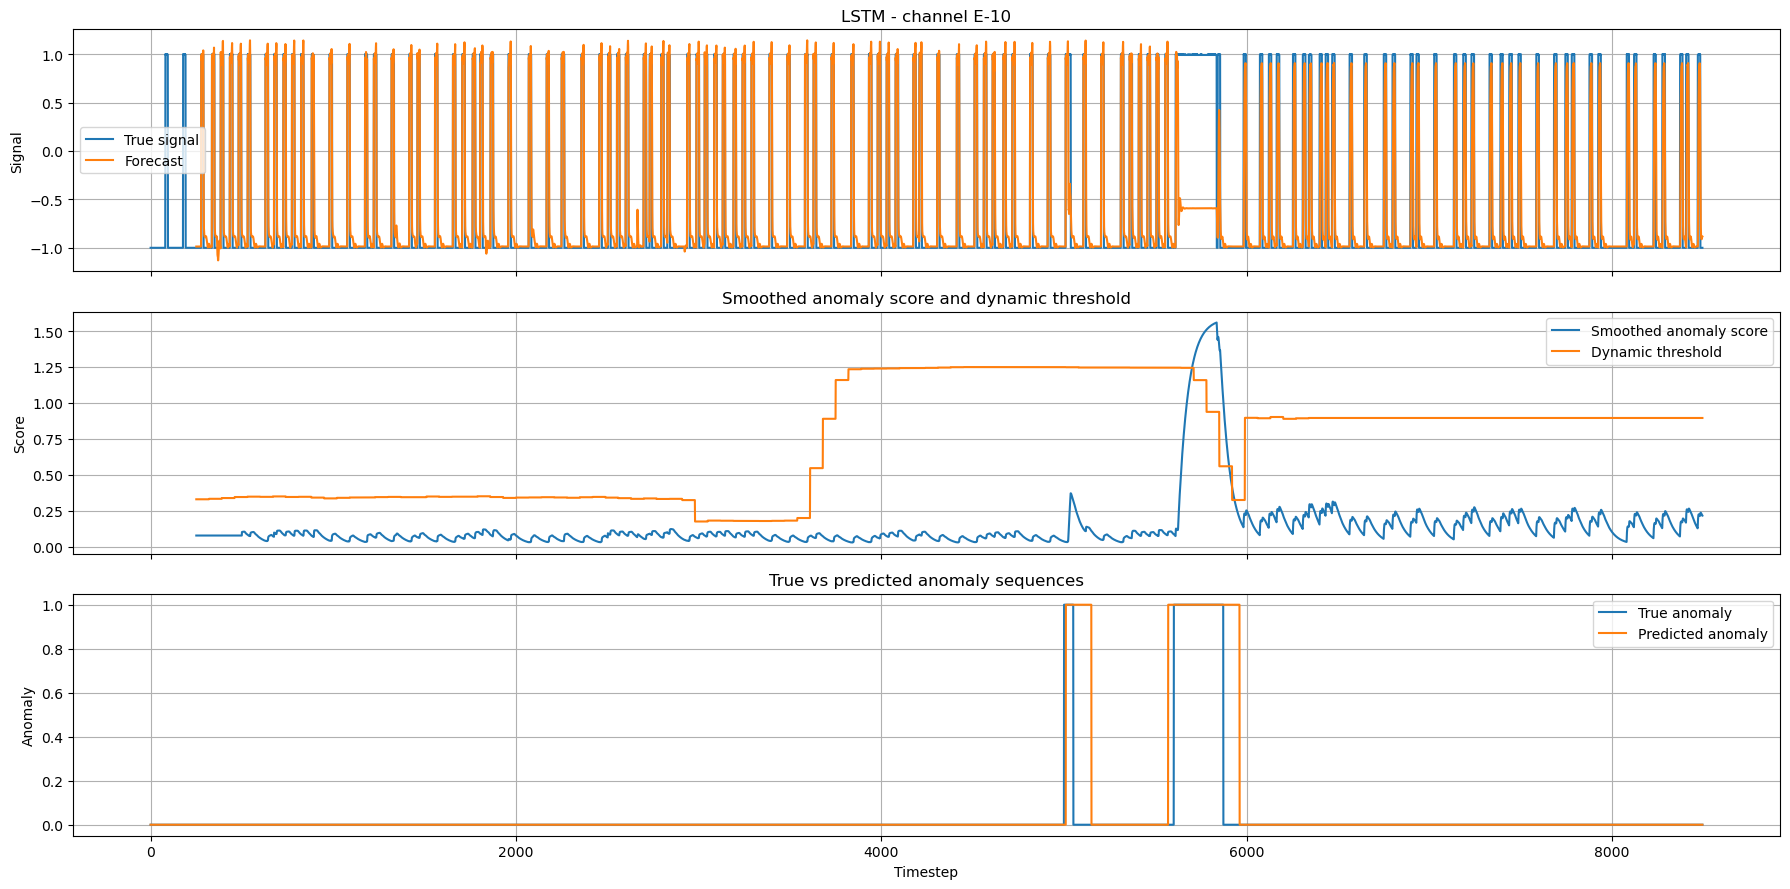

In [65]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=lstm_predictions,
    smoothed_errors=lstm_smoothed_errors,
    thresholds=lstm_thresholds,
    predictions_binary=lstm_predictions_binary,
    model_name="LSTM"
)

For channel E-10, the LSTM Regressor obtains a perfect sequence-level result: `TP = 2`, `FP = 0`, `FN = 0`, with precision `1.0`, recall `1.0`, and F1-score `1.0`. The model detects both labelled anomaly intervals and does not introduce any false positive anomalous sequence.

The first labelled anomaly, around timestep 5000, is correctly detected. This is relevant because this anomaly is short and was difficult for some previous models to capture. In this case, the LSTM produces a localized forecasting-error peak that is strong enough to cross the dynamic threshold, resulting in a predicted interval that overlaps with the true event.

The second labelled anomaly, around timestep 5600–5900, is also detected. The anomaly score rises sharply in this region and produces a predicted interval that overlaps well with the ground truth. The prediction is slightly widened around the event, but this remains acceptable because it still corresponds to the labelled anomalous region and does not generate an additional false positive sequence.

A relevant aspect is what happens after the main anomaly. Although the score shows some residual fluctuations after timestep 6000, these remain below the effective detection threshold and are not converted into extra anomalous intervals. This is an improvement compared with less stable forecasting behaviours, where post-anomaly score oscillations can easily become false positives.

Overall, channel E-10 is a successful case for the LSTM Regressor. The recurrent model detects both the short and the larger anomaly while keeping the prediction clean. This suggests that, for this channel, explicit temporal memory helps produce forecasting errors that are both sensitive to true deviations and stable enough to avoid spurious post-anomaly alarms.

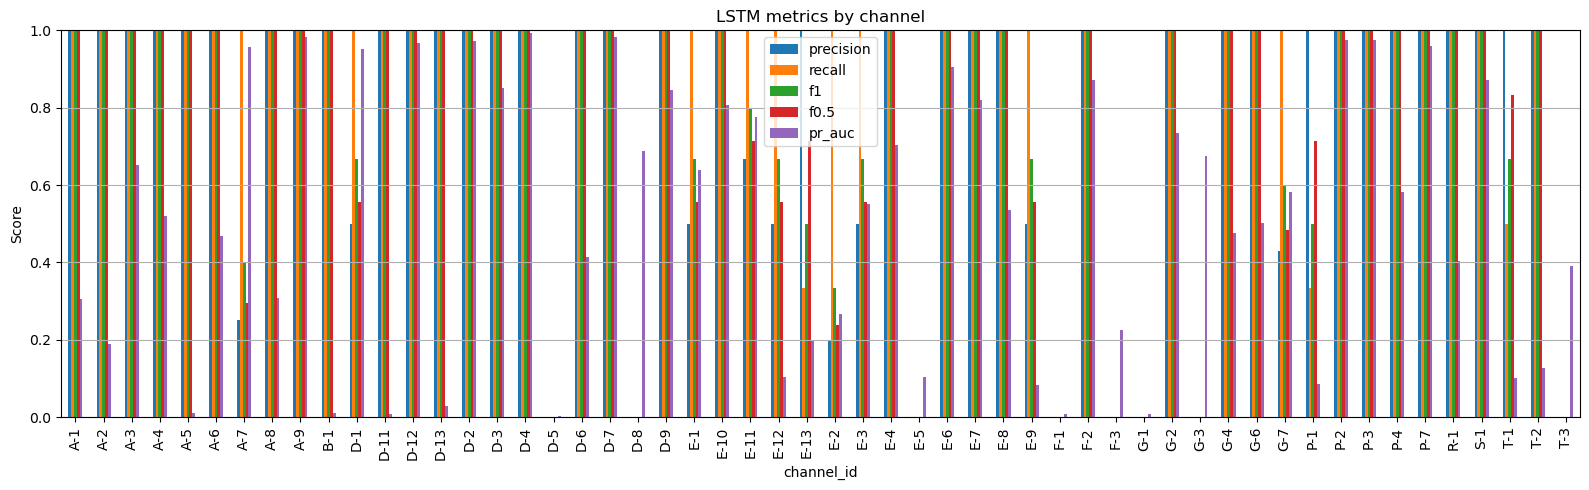

In [66]:
plot_overall_metrics(lstm_result_df,method_name='LSTM')

### LSTM-VAE Reconstruction 

The LSTM-VAE uses the reconstruction-based windowing strategy, but unlike the MLP-VAE it keeps the temporal structure of the input window. Each sample is a multivariate telemetry window with shape

$[window\_size,\; n_{\text{features}}]$

where `window_size = 250` and `n_features = 25`.

Therefore, each input sample has the form

$X_i \in \mathbb{R}^{250 \times 25}$

and the reconstruction target is the same input window:

$\hat{X}_i \approx X_i$

No future forecasting target is used during training. The model is trained to reconstruct the current multivariate temporal window, not to predict the next values of the signal.

The key difference with the MLP-VAE is that the temporal window is not flattened before entering the model. The LSTM-VAE receives the data as an ordered sequence of 250 timesteps, where each timestep contains the 25 telemetry features. This allows the recurrent encoder and decoder to model temporal dependencies inside the window instead of treating all lagged values as static input features.

During training, batches may be shuffled because the chronological order inside each individual window is preserved. During testing, shuffling is disabled so that reconstruction scores remain aligned with the original test timeline and can be passed to the common EWMA smoothing, dynamic thresholding, buffering and pruning pipeline.

In [67]:
class LSTMVaeDataset(Dataset):
    def __init__(self, X):
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index]


def make_lstm_vae_loader(X, batch_size=64, shuffle=True):
    dataset = LSTMVaeDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

The LSTM-VAE is the recurrent reconstruction-based model used in Phase 2. It extends the VAE idea by replacing the feed-forward encoder-decoder structure with recurrent LSTM modules. The goal is to test whether a probabilistic latent representation built from sequential dynamics can reconstruct nominal telemetry windows more effectively than a memory-less VAE.

The encoder receives the multivariate input sequence with shape

$[batch\_size,\; 250,\; 25]$

and processes it through an LSTM layer. Instead of flattening the whole window at the input, the encoder reads the telemetry sequence timestep by timestep and summarizes the temporal evolution into a hidden representation.

From this hidden representation, two linear layers estimate the parameters of the latent Gaussian distribution:

$\mu$

and

$\log\sigma^2$

The latent vector is then sampled through the reparameterization trick:

$z = \mu + \sigma \epsilon$

where $\epsilon$ is sampled from a standard normal distribution. This allows the model to learn a regularized latent space while still being trainable through backpropagation.

The decoder maps the sampled latent vector back into a reconstructed multivariate sequence. The latent representation is first expanded and then processed by the recurrent decoder, which produces a reconstructed window with the same temporal and feature dimensions as the input:

$\hat{X}_i \in \mathbb{R}^{250 \times 25}$

The training loss combines two terms: a reconstruction loss, which forces the model to reproduce the input window, and a KL-divergence term, which regularizes the latent distribution toward a standard Gaussian prior. The parameter `beta` controls the weight of the KL term.

For anomaly detection, however, the final score does not include the KL term. The LSTM-VAE reconstructs the full multivariate window, but the anomaly score is computed only from the reconstruction error on feature 0, the main telemetry signal. The remaining features are used as contextual information by the recurrent encoder-decoder, but they do not directly contribute to the final anomaly score.

This keeps the reconstruction-based setting aligned with the forecasting-based models: all models exploit the multivariate telemetry context, while the final anomaly score remains centered on the same target signal.

In [68]:
class LSTMVAE(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        latent_size=32,
        num_layers=1
    ):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_size = latent_size
        self.num_layers = num_layers

        self.encoder_lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc_mu = nn.Linear(hidden_size, latent_size)
        self.fc_logvar = nn.Linear(hidden_size, latent_size)

        self.latent_to_hidden = nn.Linear(latent_size, hidden_size)

        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]

        mu = self.fc_mu(h_last)
        logvar = self.fc_logvar(h_last)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z, seq_len):
        decoder_input = self.latent_to_hidden(z)
        decoder_input = decoder_input.unsqueeze(1).repeat(1, seq_len, 1)

        decoder_output, _ = self.decoder_lstm(decoder_input)

        x_recon = self.output_layer(decoder_output)

        return x_recon

    def forward(self, x):
        seq_len = x.size(1)

        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode(z, seq_len)

        return x_recon, mu, logvar

In [69]:
def lstm_vae_loss_function(x_recon, x, mu, logvar, beta=1e-3):
    """
    LSTM-VAE loss = reconstruction loss + beta * KL divergence.
    """

    recon_loss = F.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

In [70]:
def train_lstm_vae_channel(
        X_train,
        latent_size=32,
        hidden_size=64,
        num_layers=1,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device="cpu"
):
    n = len(X_train)
    n_val = int(n * validation_split)

    if n_val > 0:
        X_tr = X_train[:-n_val]
        X_val = X_train[-n_val:]
    else:
        X_tr = X_train
        X_val = None

    train_loader = make_lstm_vae_loader(
        X_tr,
        batch_size=batch_size,
        shuffle=True
    )

    if X_val is not None:
        val_loader = make_lstm_vae_loader(
            X_val,
            batch_size=batch_size,
            shuffle=False
        )
    else:
        val_loader = None

    input_size = X_train.shape[2]

    model = LSTMVAE(
        input_size=input_size,
        hidden_size=hidden_size,
        latent_size=latent_size,
        num_layers=num_layers
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    best_val_loss = np.inf
    best_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    patience_counter = 0

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_recon = 0.0
        train_kl = 0.0

        for X_batch in train_loader:
            X_batch = X_batch.to(device)

            X_recon, mu, logvar = model(X_batch)

            loss, recon_loss, kl_loss = lstm_vae_loss_function(
                x_recon=X_recon,
                x=X_batch,
                mu=mu,
                logvar=logvar,
                beta=beta
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_recon += recon_loss.item() * X_batch.size(0)
            train_kl += kl_loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_recon /= len(train_loader.dataset)
        train_kl /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()

            val_loss = 0.0
            val_recon = 0.0
            val_kl = 0.0

            with torch.no_grad():
                for X_batch in val_loader:
                    X_batch = X_batch.to(device)

                    X_recon, mu, logvar = model(X_batch)

                    loss, recon_loss, kl_loss = lstm_vae_loss_function(
                        x_recon=X_recon,
                        x=X_batch,
                        mu=mu,
                        logvar=logvar,
                        beta=beta
                    )

                    val_loss += loss.item() * X_batch.size(0)
                    val_recon += recon_loss.item() * X_batch.size(0)
                    val_kl += kl_loss.item() * X_batch.size(0)

            val_loss /= len(val_loader.dataset)
            val_recon /= len(val_loader.dataset)
            val_kl /= len(val_loader.dataset)

            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": val_loss,
                "val_recon_loss": val_recon,
                "val_kl_loss": val_kl
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1:02d}")
                break

        else:
            history.append({
                "train_loss": train_loss,
                "train_recon_loss": train_recon,
                "train_kl_loss": train_kl,
                "val_loss": np.nan,
                "val_recon_loss": np.nan,
                "val_kl_loss": np.nan
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"train loss: {train_loss:.6f}"
            )

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_state.items()
    })

    return model, history

In [99]:
def compute_lstm_vae_scores(model, X_test, batch_size=64, device="cpu"):
    """
    Compute one reconstruction anomaly score per test window.

    The LSTM-VAE reconstructs the full multivariate window, but the anomaly
    score is computed only on feature 0, i.e. the main telemetry signal.
    """

    loader = make_lstm_vae_loader(
        X_test,
        batch_size=batch_size,
        shuffle=False
    )

    model.eval()
    all_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)

            X_recon, mu, logvar = model(X_batch)

            mse_errors = torch.mean(
                (X_batch[:, :, 0] - X_recon[:, :, 0]) ** 2,
                dim=1
            )

            all_scores.append(mse_errors.cpu().numpy())

    return np.concatenate(all_scores)

In [100]:
lstm_vae_models = {}
lstm_vae_histories = {}
lstm_vae_scores = {}
lstm_vae_smoothed_scores = {}
lstm_vae_predictions_binary = {}
lstm_vae_thresholds = {}
lstm_vae_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM-VAE for channel {ch}")
    print("=" * 80)

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    X_train = X_train_data[ch]
    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_vae_channel(
        X_train=X_train,
        latent_size=32,
        hidden_size=64,
        num_layers=1,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        beta=1e-3,
        validation_split=0.2,
        patience=10,
        min_delta=0.0003,
        device=device
    )

    clear_gpu()

    model = model.to(device)
    model.eval()

    scores = compute_lstm_vae_scores(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_test_signal = y_test[:len(scores), 0]

    smoothed_scores = apply_ewma_smoothing(
        scores,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05,
        l_s=250,
        channel_id=ch
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_scores,
        y_test_signal=y_test_signal,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        inverse=True,
        l_s=250
    )

    labels_eval = labels[:len(y_pred)]

    y_scores_eval = np.zeros(len(y_pred))
    score_end = min(len(y_scores_eval) - 250, len(smoothed_scores))

    if score_end > 0:
        y_scores_eval[250:250 + score_end] = smoothed_scores[:score_end]

    metrics = evaluate_sequences(
        y_true=labels_eval,
        y_pred=y_pred[:len(labels_eval)],
        y_scores=y_scores_eval[:len(labels_eval)]
    )

    lstm_vae_models[ch] = model.to("cpu")
    lstm_vae_histories[ch] = history
    lstm_vae_scores[ch] = scores
    lstm_vae_smoothed_scores[ch] = smoothed_scores
    lstm_vae_predictions_binary[ch] = y_pred
    lstm_vae_thresholds[ch] = thresholds
    lstm_vae_metrics[ch] = metrics

    display(metrics)

Training LSTM-VAE for channel A-1
X_train: (2620, 250, 25)
X_test: (8380, 250, 25)
y_test: (8380, 10)
labels: (8640,)
Epoch 01 | train loss: 0.035539 | val loss: 0.019931
Epoch 02 | train loss: 0.021074 | val loss: 0.018230
Epoch 03 | train loss: 0.020411 | val loss: 0.018008
Epoch 04 | train loss: 0.020266 | val loss: 0.017922
Epoch 05 | train loss: 0.020208 | val loss: 0.017901
Epoch 06 | train loss: 0.020179 | val loss: 0.017865
Epoch 07 | train loss: 0.020159 | val loss: 0.017851
Epoch 08 | train loss: 0.020141 | val loss: 0.017836
Epoch 09 | train loss: 0.020128 | val loss: 0.017846
Epoch 10 | train loss: 0.020120 | val loss: 0.017820
Epoch 11 | train loss: 0.020108 | val loss: 0.017828
Epoch 12 | train loss: 0.020101 | val loss: 0.017785
Epoch 13 | train loss: 0.020092 | val loss: 0.017794
Epoch 14 | train loss: 0.020086 | val loss: 0.017779
Early stopping at epoch 14


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.017229,0.0


Training LSTM-VAE for channel A-2
X_train: (2388, 250, 25)
X_test: (7654, 250, 25)
y_test: (7654, 10)
labels: (7914,)
Epoch 01 | train loss: 0.036745 | val loss: 0.034346
Epoch 02 | train loss: 0.033251 | val loss: 0.033910
Epoch 03 | train loss: 0.033067 | val loss: 0.033837
Epoch 04 | train loss: 0.033031 | val loss: 0.033810
Epoch 05 | train loss: 0.033008 | val loss: 0.033798
Epoch 06 | train loss: 0.032999 | val loss: 0.033792
Epoch 07 | train loss: 0.032993 | val loss: 0.033784
Epoch 08 | train loss: 0.032988 | val loss: 0.033784
Epoch 09 | train loss: 0.032982 | val loss: 0.033778
Epoch 10 | train loss: 0.032983 | val loss: 0.033778
Epoch 11 | train loss: 0.032981 | val loss: 0.033784
Epoch 12 | train loss: 0.032979 | val loss: 0.033768
Early stopping at epoch 12


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.031163,0.0


Training LSTM-VAE for channel A-3
X_train: (2476, 250, 25)
X_test: (7945, 250, 25)
y_test: (7945, 10)
labels: (8205,)
Epoch 01 | train loss: 0.033715 | val loss: 0.030005
Epoch 02 | train loss: 0.029007 | val loss: 0.029363
Epoch 03 | train loss: 0.028722 | val loss: 0.029272
Epoch 04 | train loss: 0.028668 | val loss: 0.029250
Epoch 05 | train loss: 0.028650 | val loss: 0.029248
Epoch 06 | train loss: 0.028634 | val loss: 0.029244
Epoch 07 | train loss: 0.028630 | val loss: 0.029164
Epoch 08 | train loss: 0.028624 | val loss: 0.029231
Epoch 09 | train loss: 0.028619 | val loss: 0.029300
Epoch 10 | train loss: 0.028619 | val loss: 0.029298
Epoch 11 | train loss: 0.028614 | val loss: 0.029230
Epoch 12 | train loss: 0.028610 | val loss: 0.029194
Early stopping at epoch 12


...

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.621809,0.0


Training LSTM-VAE for channel T-2
X_train: (2595, 250, 25)
X_test: (8365, 250, 25)
y_test: (8365, 10)
labels: (8625,)
Epoch 01 | train loss: 0.024455 | val loss: 0.016312
Epoch 02 | train loss: 0.019127 | val loss: 0.015743
Epoch 03 | train loss: 0.018852 | val loss: 0.015598
Epoch 04 | train loss: 0.018784 | val loss: 0.015550
Epoch 05 | train loss: 0.018755 | val loss: 0.015551
Epoch 06 | train loss: 0.018749 | val loss: 0.015531
Epoch 07 | train loss: 0.018735 | val loss: 0.015521
Epoch 08 | train loss: 0.018730 | val loss: 0.015506
Epoch 09 | train loss: 0.018729 | val loss: 0.015545
Epoch 10 | train loss: 0.018724 | val loss: 0.015503
Epoch 11 | train loss: 0.018723 | val loss: 0.015515
Epoch 12 | train loss: 0.018717 | val loss: 0.015516
Early stopping at epoch 12


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,1,0.0,0.0,0.0,0.0,0.838583,0.0


Training LSTM-VAE for channel T-3
X_train: (2616, 250, 25)
X_test: (8319, 250, 25)
y_test: (8319, 10)
labels: (8579,)
Epoch 01 | train loss: 0.020237 | val loss: 0.002955
Epoch 02 | train loss: 0.003532 | val loss: 0.000688
Epoch 03 | train loss: 0.002678 | val loss: 0.000400
Epoch 04 | train loss: 0.002503 | val loss: 0.000295
Epoch 05 | train loss: 0.002431 | val loss: 0.000250
Epoch 06 | train loss: 0.002394 | val loss: 0.000228
Epoch 07 | train loss: 0.002365 | val loss: 0.000197
Epoch 08 | train loss: 0.002347 | val loss: 0.000177
Epoch 09 | train loss: 0.002328 | val loss: 0.000157
Epoch 10 | train loss: 0.002318 | val loss: 0.000184
Epoch 11 | train loss: 0.002305 | val loss: 0.000146
Epoch 12 | train loss: 0.002295 | val loss: 0.000150
Epoch 13 | train loss: 0.002285 | val loss: 0.000121
Epoch 14 | train loss: 0.002279 | val loss: 0.000163
Early stopping at epoch 14


,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,0,0,2,0.0,0.0,0.0,0.0,0.044453,0.0


In [102]:
lstm_vae_results_df, lstm_vae_summary_df = generate_results_view(lstm_vae_metrics)

,channel_id,TP,FP,FN,precision,recall,f1,f0.5,pr_auc,predicted_anomaly_ratio
0,A-1,0,0,1,0.000000,0.000000,0.000000,0.000000,0.017229,0.000000
1,A-2,0,0,1,0.000000,0.000000,0.000000,0.000000,0.031163,0.000000
2,A-3,0,1,1,0.000000,0.000000,0.000000,0.000000,0.031845,0.039902
3,A-4,0,0,1,0.000000,0.000000,0.000000,0.000000,0.019224,0.000000
4,A-5,1,0,0,1.000000,1.000000,1.000000,1.000000,0.011543,0.104634
5,A-6,0,1,1,0.000000,0.000000,0.000000,0.000000,0.038174,0.084853
6,A-7,0,0,1,0.000000,0.000000,0.000000,0.000000,0.159977,0.000000
7,A-8,1,0,0,1.000000,1.000000,1.000000,1.000000,0.637701,0.075314
8,A-9,1,0,0,1.000000,1.000000,1.000000,1.000000,0.802206,0.108025
9,B-1,1,0,0,1.000000,1.000000,1.000000,1.000000,0.010985,0.060991


TP                               31.000000
FP                                7.000000
FN                               37.000000
precision                         0.815789
recall                            0.455882
f1                                0.584906
f0.5                              0.704545
pr_auc_macro                      0.357422
predicted_anomaly_ratio_macro     0.044400
dtype: float64

### LSTM-VAE Results Analysis

The LSTM-VAE obtains a sequence-level precision of `0.816`, a recall of `0.456`, and an F1-score of `0.585`. Overall, the model detects `31` out of `68` labelled anomaly sequences, misses `37`, and produces only `7` false positive predicted sequences. This indicates a very conservative reconstruction-based behaviour: when the model raises an alarm it is often correct, but many true anomaly intervals are not detected.

The high precision is the strongest aspect of this model. Compared with the previous reconstruction-based models, the LSTM-VAE produces fewer false positives, suggesting that the recurrent reconstruction score is less prone to generating spurious anomaly intervals. This is also reflected by the F0.5-score of `0.705`, which is substantially higher than the F1-score because F0.5 gives more weight to precision. From an operational perspective, this means that the alarms produced by the LSTM-VAE are relatively reliable.

The main limitation is recall. A recall of `0.456` means that more than half of the labelled anomaly sequences are missed. The model often reconstructs anomalous windows well enough that the reconstruction error on feature 0 does not exceed the dynamic threshold, or the resulting score peaks are too weak to survive the post-processing pipeline. This is a typical risk for reconstruction-based models: if the anomaly remains compatible with the learned reconstruction manifold, it may not produce a sufficiently distinctive error.

The predicted anomaly ratio is approximately `4.44%`, slightly lower than the other models. This confirms that the LSTM-VAE does not over-predict anomalies. However, the low anomaly ratio also helps explain the limited recall: the model is selective, but this selectivity comes at the cost of missing many true events.

The per-channel results are highly heterogeneous. Several channels, especially some `D-*`, `E-*`, `P-*`, and `S-*` streams, are detected perfectly. However, many channels have zero recall, including `A-1`, `A-2`, `A-4`, `A-7`, `D-5`, `D-6`, `D-8`, `E-1`, `E-4`, `E-5`, `F-*`, several `G-*` channels, `P-1`, `R-1`, and the `T-*` channels. This shows that the recurrent reconstruction score is not uniformly informative across the dataset.

The macro PR-AUC is `0.357`, which is higher than the MLP-VAE but still moderate. This suggests that adding recurrent temporal structure improves the quality of the reconstruction scores to some extent, but not enough to make reconstruction-based detection consistently reliable for SMAP anomalies.

Overall, the LSTM-VAE improves precision and reduces false positives, but it does not solve the main weakness of reconstruction-based detection: low recall. The model is useful when the priority is avoiding false alarms, but it is less suitable if the main goal is to recover as many anomaly intervals as possible. In the context of this study, the result suggests that temporal memory helps stabilize reconstruction-based scores, but forecasting-based models remain more effective for detecting contextual SMAP anomalies.

In [103]:
save_results(lstm_vae_results_df,lstm_vae_summary_df,method_name="LSTM_VAE")

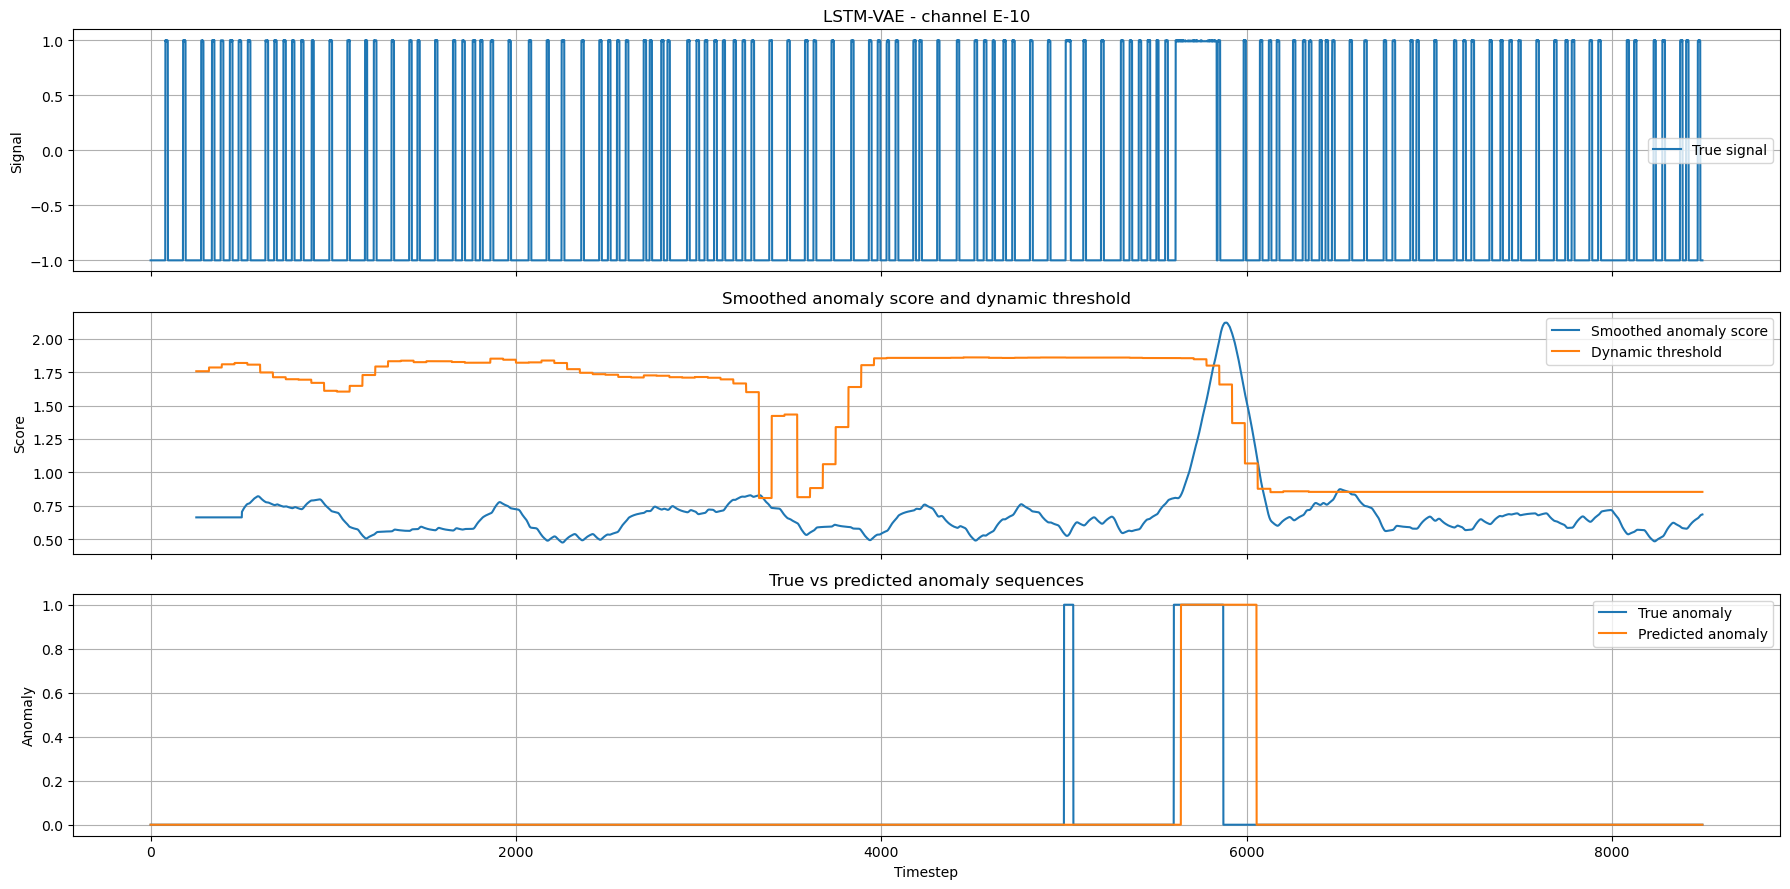

In [104]:
plot_channel_diagnostics(
    ch="E-10",
    predictions=None,
    smoothed_errors=lstm_vae_smoothed_scores,
    thresholds=lstm_vae_thresholds,
    predictions_binary=lstm_vae_predictions_binary,
    model_name="LSTM-VAE"
)

For channel E-10, the LSTM-VAE obtains a selective but incomplete result: `TP = 1`, `FP = 0`, `FN = 1`, with precision `1.0`, recall `0.5`, and F1-score `0.667`. The model detects only one of the two labelled anomaly intervals, but it does not produce any false positive sequence.

The detected anomaly is the larger event around timestep 5600–6000. In this region, the reconstruction score rises sharply above the dynamic threshold, producing a predicted interval that overlaps with the labelled anomaly. This indicates that the recurrent reconstruction error on feature 0 is able to capture the strongest deviation in this channel.

The earlier labelled anomaly around timestep 5000 is missed. The score remains below the threshold in that region, so the anomaly is not converted into a final prediction. This suggests that the short anomaly is still sufficiently reconstructible by the LSTM-VAE, or that its reconstruction error is not strong enough to survive the dynamic thresholding stage.

A relevant positive aspect is the absence of false positives. Unlike other models that generated spurious detections before or after the main anomaly, the LSTM-VAE remains conservative on this channel. The price of this selectivity is lower recall: the model avoids false alarms, but it also misses one true anomalous event.

Overall, channel E-10 reflects the general behaviour of the LSTM-VAE: the model produces clean and reliable detections when the reconstruction error is sufficiently strong, but it struggles with weaker or shorter anomalies. This confirms that recurrent reconstruction improves precision, but does not fully solve the recall limitation of reconstruction-based anomaly detection.

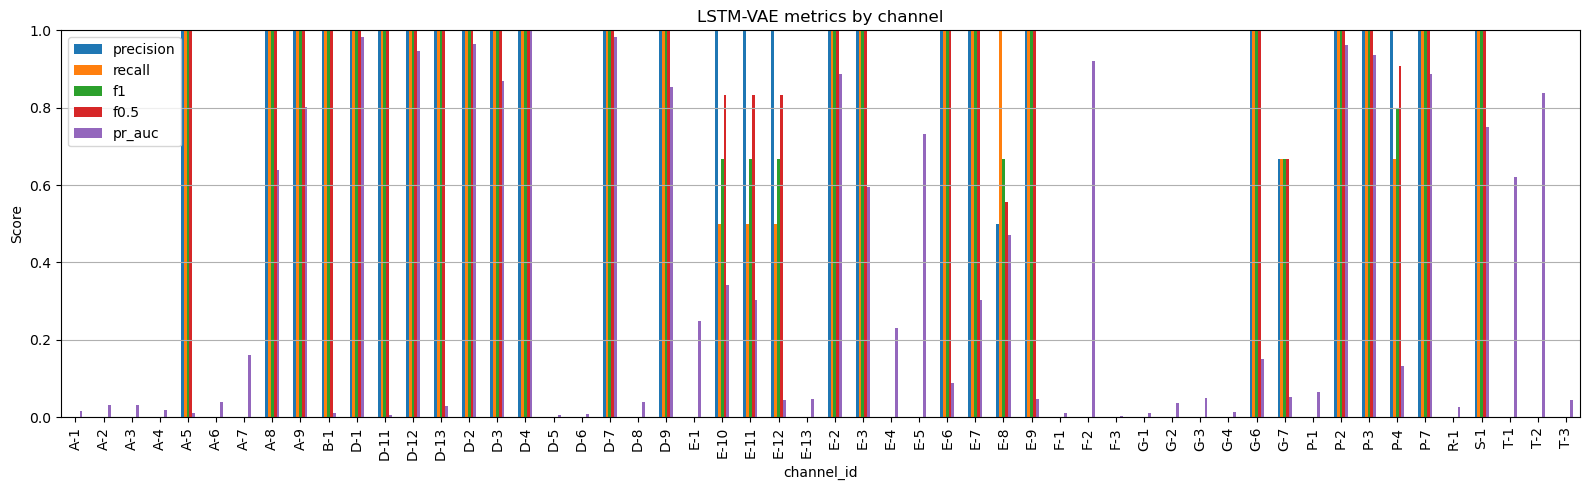

In [105]:
plot_overall_metrics(
    lstm_vae_results_df,
    method_name="LSTM-VAE"
)

### Phase 2 Summary: Recurrent Temporal Modeling Comparison

The LSTM Regressor obtains the strongest result in this phase, with precision `0.720`, recall `0.794`, and F1-score `0.755`. It detects `54` out of `68` labelled anomaly sequences, missing only `14`, while producing `21` false positive sequences. This indicates that recurrent forecasting is effective at capturing contextual deviations in the future evolution of the main telemetry signal.

The LSTM-VAE shows a very different behaviour. It obtains higher precision (`0.816`) but much lower recall (`0.456`), with an F1-score of `0.585`. It detects only `31` out of `68` anomaly sequences, the same number detected by the MLP-VAE, but it reduces the number of false positives from `17` to `7`. This means that recurrence improves the selectivity of the reconstruction-based model, but not its ability to recover more true anomaly intervals.

The contrast between the two models is therefore clear. The LSTM Regressor is more detection-oriented: it captures many more anomalies, but accepts a moderate number of false positives. The LSTM-VAE is more conservative: it raises fewer alarms and achieves higher precision, but misses more than half of the labelled anomaly sequences. In the context of this project, where sequence-level F1 and recall are central, the LSTM Regressor is the more effective model.

The predicted anomaly ratios are similar: approximately `4.96%` for the LSTM Regressor and `4.44%` for the LSTM-VAE. Therefore, the difference in recall is not caused by a large difference in the amount of predicted anomalous timesteps. Rather, the LSTM Regressor places its anomaly predictions more effectively on labelled anomaly intervals, while the LSTM-VAE remains too selective and often fails to generate sufficiently strong reconstruction-error peaks.

The macro PR-AUC further supports this interpretation. The LSTM Regressor reaches `0.522`, the best continuous-score quality observed so far, while the LSTM-VAE reaches only `0.357`. This suggests that recurrent forecasting produces anomaly scores that rank anomalous timesteps better than recurrent reconstruction scores. Although the LSTM-VAE improves precision, its reconstruction scores are still not consistently discriminative across channels.

Overall, Phase 2 shows that explicit temporal memory is useful mainly in the forecasting-based setting. The LSTM Regressor improves anomaly coverage and produces the best overall F1-score, supporting the hypothesis that many SMAP anomalies are better detected as deviations from expected future behaviour. In contrast, adding recurrence to the VAE stabilizes the reconstruction detector and reduces false positives, but it does not solve the low-recall limitation of reconstruction-based anomaly detection.

# SUMMARY

In [113]:
def build_model_comparison_df(model_summaries):
    """
    Convert model summary Series/dicts into a single comparison DataFrame.

    Input:
        model_summaries: dict
            {
                "AE": ae_summary,
                "RFR": rf_summary,
                ...
            }

    Output:
        comparison_df: pd.DataFrame
            rows = models
            columns = metrics
    """

    rows = []

    for model_name, summary in model_summaries.items():
        if isinstance(summary, pd.DataFrame):
            if len(summary) != 1:
                raise ValueError(f"{model_name}: expected a one-row DataFrame.")
            summary = summary.iloc[0]

        summary = pd.Series(summary)

        row = {
            "model": model_name,
            "TP": summary.get("TP", np.nan),
            "FP": summary.get("FP", np.nan),
            "FN": summary.get("FN", np.nan),
            "precision": summary.get("precision", np.nan),
            "recall": summary.get("recall", np.nan),
            "f1": summary.get("f1", np.nan),
            "f0.5": summary.get("f0.5", np.nan),
            "pr_auc_macro": summary.get("pr_auc_macro", summary.get("pr_auc", np.nan)),
            "predicted_anomaly_ratio_macro": summary.get(
                "predicted_anomaly_ratio_macro",
                summary.get("predicted_anomaly_ratio", np.nan)
            )
        }

        rows.append(row)

    comparison_df = pd.DataFrame(rows).set_index("model")

    return comparison_df



def plot_metric_comparisons(
    comparison_df,
    metrics=None,
    model_order=None,
    save_dir=None,
    figsize=(9, 5),
    rotate_xticks=30,
    model_colors=None
):
    """
    Generate one bar figure for each metric, comparing all tested models.
    Each model is plotted with a fixed color.
    """

    if model_colors is None:
        MODEL_COLORS = {
            "AE": "#1f77b4",
            "RFR": "#ff7f0e",
            "MLP": "#2ca02c",
            "MLP-VAE": "#d62728",
            "LSTM": "#9467bd",
            "LSTM-VAE": "#8c564b"
        }
        model_colors = MODEL_COLORS

    if metrics is None:
        metrics = [
            "precision",
            "recall",
            "f1",
            "f0.5",
            "pr_auc_macro",
            "predicted_anomaly_ratio_macro",
            "TP",
            "FP",
            "FN"
        ]

    if model_order is not None:
        missing_models = [m for m in model_order if m not in comparison_df.index]
        if len(missing_models) > 0:
            raise ValueError(f"These models are not in comparison_df: {missing_models}")

        comparison_df = comparison_df.loc[model_order]

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    figures = {}

    for metric in metrics:
        if metric not in comparison_df.columns:
            print(f"Skipping metric '{metric}': not found in comparison_df.")
            continue

        values = comparison_df[metric].astype(float)
        colors = [
            model_colors.get(model_name, "#7f7f7f")
            for model_name in values.index
        ]

        fig, ax = plt.subplots(figsize=figsize)

        bars = ax.bar(values.index, values.values, color=colors)

        ax.set_title(f"Model comparison - {metric}")
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.3)

        if metric in [
            "precision",
            "recall",
            "f1",
            "f0.5",
            "pr_auc_macro",
            "predicted_anomaly_ratio_macro"
        ]:
            ax.set_ylim(0, 1)

        for bar, value in zip(bars, values.values):
            if np.isnan(value):
                label = "nan"
            elif metric in ["TP", "FP", "FN"]:
                label = f"{int(value)}"
            else:
                label = f"{value:.3f}"

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                label,
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.xticks(rotation=rotate_xticks, ha="right")
        plt.tight_layout()

        figures[metric] = fig

        if save_dir is not None:
            filename = metric.replace(".", "_").replace("/", "_")
            fig.savefig(
                os.path.join(save_dir, f"{filename}_comparison.png"),
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    return figures

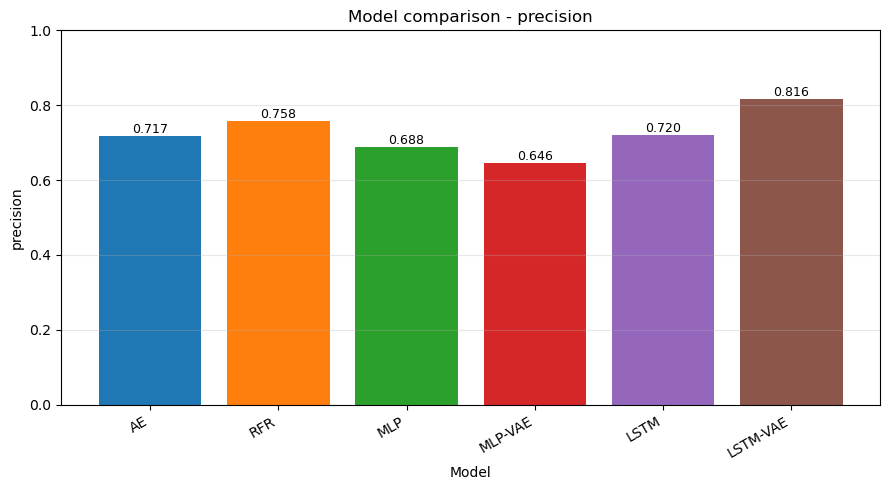

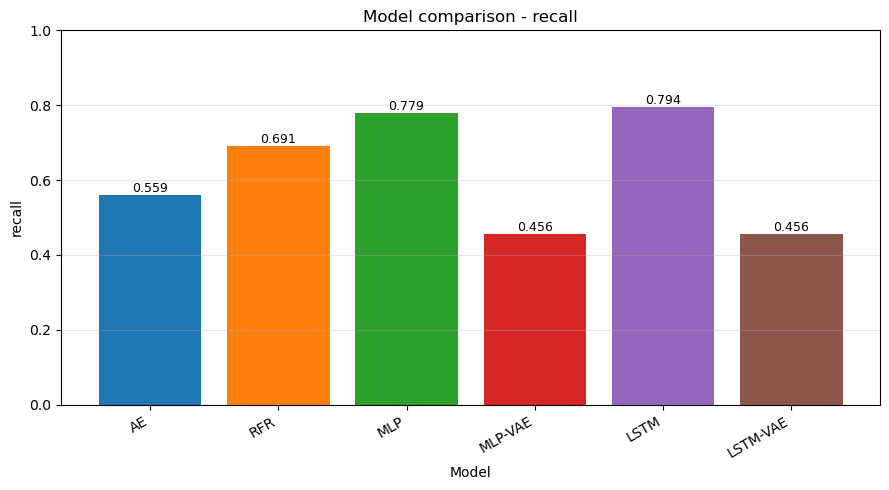

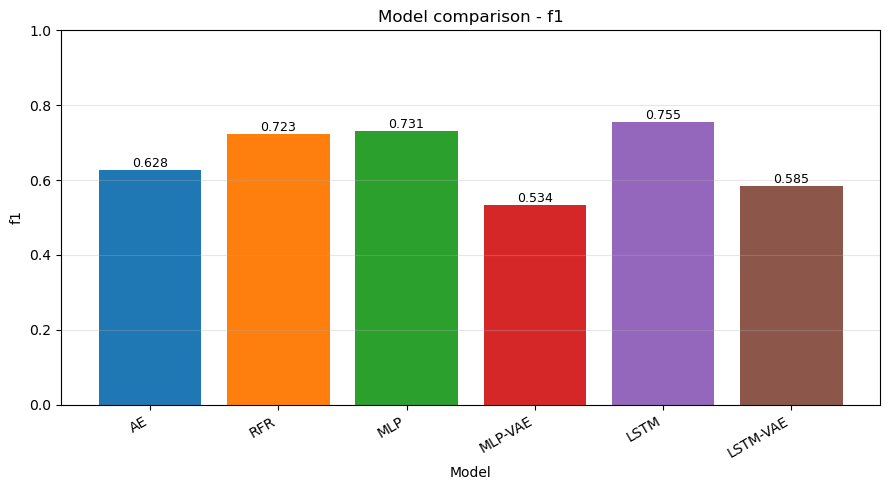

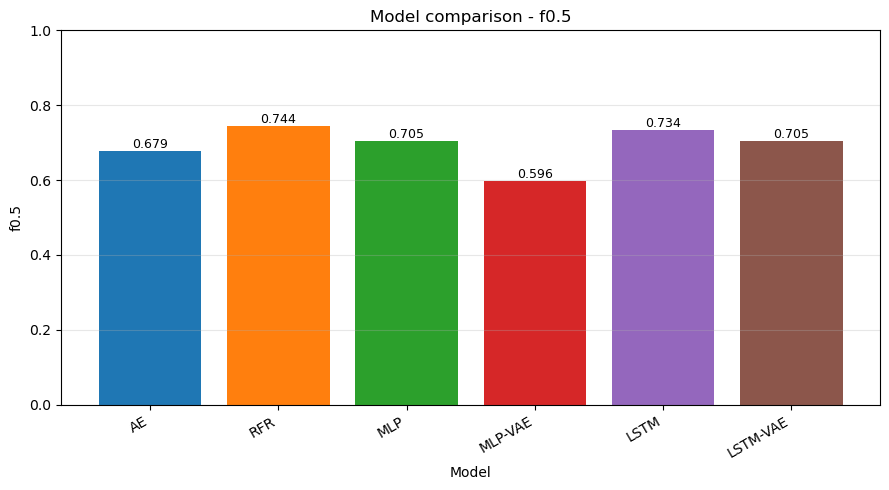

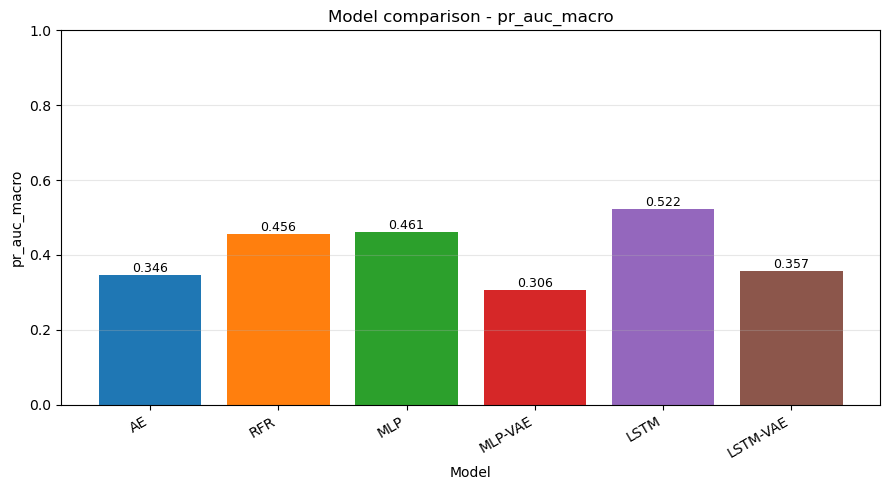

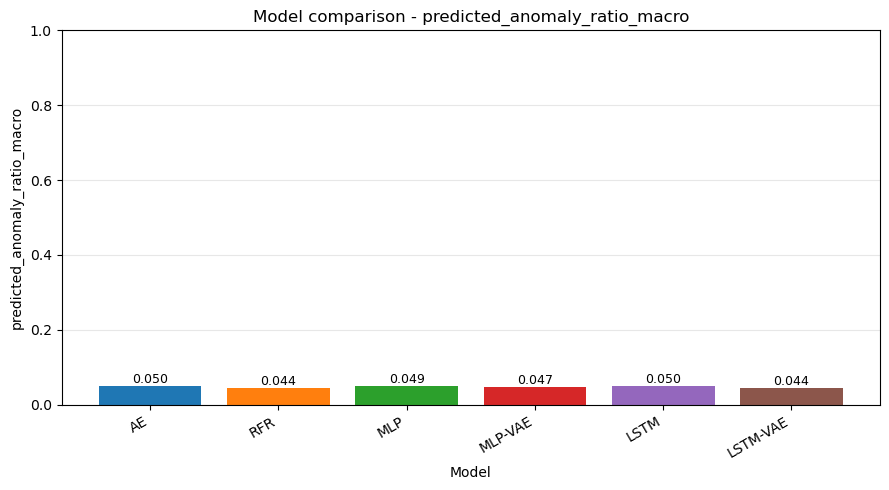

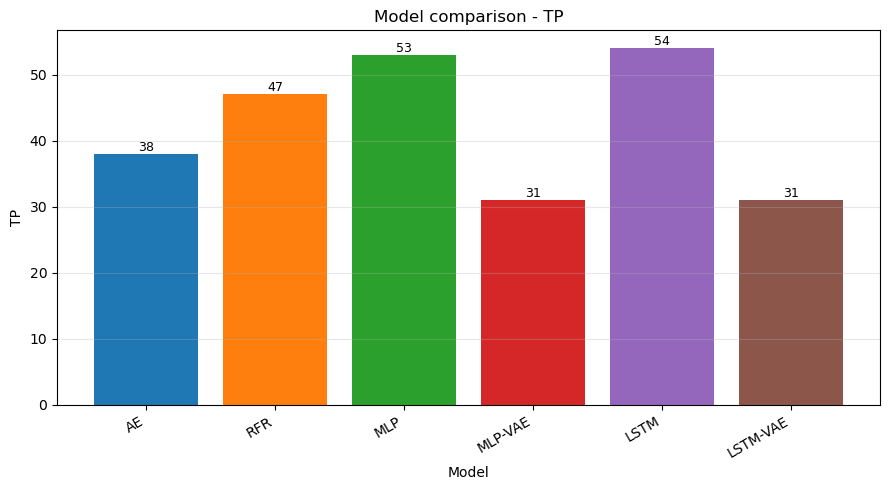

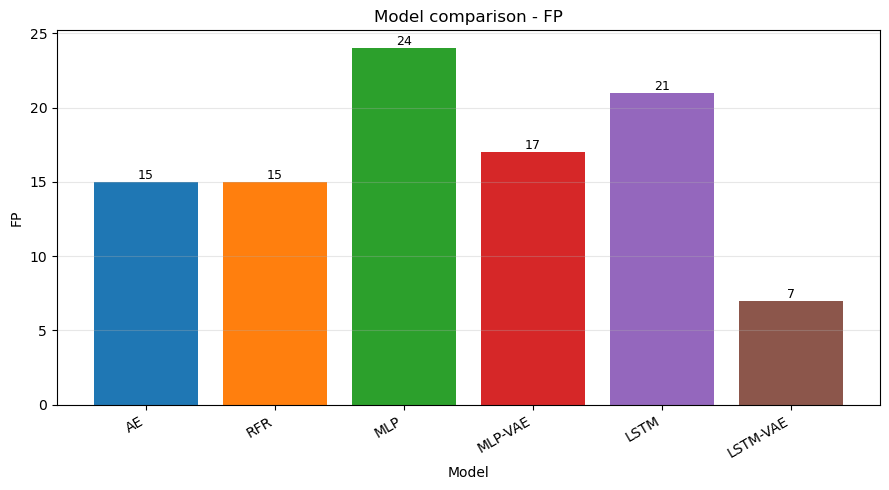

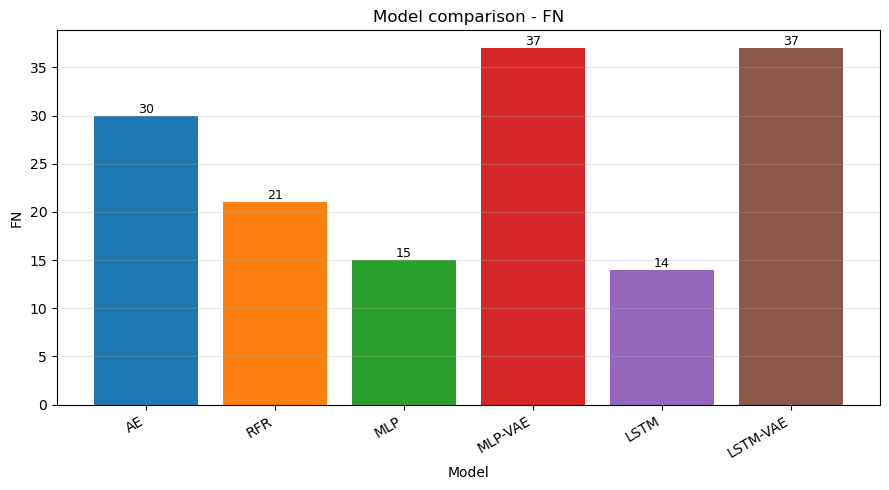

,TP,FP,FN,precision,recall,f1,f0.5,pr_auc_macro,predicted_anomaly_ratio_macro
model,,,,,,,,,
AE,38.0,15.0,30.0,0.716981,0.558824,0.628099,0.678571,0.345997,0.049517
RFR,47.0,15.0,21.0,0.758065,0.691176,0.723077,0.743671,0.455941,0.043744
MLP,53.0,24.0,15.0,0.688312,0.779412,0.731034,0.704787,0.461337,0.048526
MLP-VAE,31.0,17.0,37.0,0.645833,0.455882,0.534483,0.596154,0.306496,0.047253
LSTM,54.0,21.0,14.0,0.720000,0.794118,0.755245,0.733696,0.521674,0.049562
LSTM-VAE,31.0,7.0,37.0,0.815789,0.455882,0.584906,0.704545,0.357422,0.044400


In [114]:
model_summaries = {
    "AE": ae_summary_df,
    "RFR": rf_summary_df,
    "MLP": mlp_summary_df,
    "MLP-VAE": vae_summary_df,
    "LSTM": lstm_summary_df,
    "LSTM-VAE": lstm_vae_summary_df
}

comparison_df = build_model_comparison_df(model_summaries)

model_order = ["AE", "RFR", "MLP", "MLP-VAE", "LSTM", "LSTM-VAE"]

figures = plot_metric_comparisons(
    comparison_df=comparison_df,
    model_order=model_order,
    save_dir=None
)

comparison_df

### Final Discussion: Model Comparison and Main Findings

The final comparison shows a clear separation between forecasting-based and reconstruction-based approaches. The best overall model is the **LSTM Regressor**, with the highest F1-score (`0.755`), highest recall (`0.794`) and highest PR-AUC macro (`0.522`). This indicates that, for SMAP, many anomalies are better captured as deviations from expected future behaviour rather than as windows that are difficult to reconstruct.

The **MLP Regressor** is very close to the LSTM in terms of F1-score (`0.731` vs `0.755`) and recall (`0.779` vs `0.794`). This is important: explicit temporal memory improves the results, but the gain is moderate. A flattened temporal window already contains a large amount of useful contextual information, because the lagged values remain available at fixed positions. Therefore, even without recurrence, the MLP can learn nonlinear relationships between recent telemetry history and future target behaviour.

The **Random Forest Regressor** remains a strong classical baseline. Although it is not the best final model, it achieves good precision (`0.758`) and a competitive F1-score (`0.723`). This confirms that flattening the window does not destroy temporal context completely. The model cannot process the sequence dynamically like an LSTM, but it can still exploit local lagged patterns, switching behaviours and nonlinear feature interactions. Its performance also shows that the anomaly detection pipeline is strongly influenced by the window representation and by the post-processing strategy.

The reconstruction-based models are generally weaker in recall. The **AE**, **MLP-VAE** and **LSTM-VAE** detect fewer labelled anomaly sequences than the forecasting models. In particular, both VAE models detect only `31` out of `68` anomaly sequences. This suggests that many SMAP anomalies remain reconstructible enough not to generate a strong reconstruction error on feature 0. The LSTM-VAE improves precision substantially (`0.816`) and produces very few false positives (`7`), but this comes at the cost of low recall (`0.456`). It is therefore selective, but too conservative for a task where missing anomalies is critical.

The predicted anomaly ratios are very similar across models, roughly between `4.4%` and `5.0%`. This is useful because it shows that performance differences are not mainly due to one model predicting much more or much less anomaly mass. The key difference is where the predicted anomaly intervals are placed. Forecasting models, especially MLP and LSTM, align their detections better with labelled anomaly intervals.

The windowing strategy is also central to the interpretation of the results. Sliding windows of length `250` with stride `1` generate many samples, but consecutive windows are highly overlapping and not independent. For channels with short training sequences, the effective diversity of normal examples can be limited. This affects all models: the model may see many shifted versions of the same local behaviour and then be asked to generalize to much longer test sequences. Some anomaly scores may therefore reflect unseen normal regimes, not only true anomalies.

Overall, the results support three main conclusions. First, **forecasting-based anomaly detection is more suitable than reconstruction-based detection for this SMAP setup**. Second, **explicit temporal memory helps**, as shown by the LSTM Regressor, but the improvement over a strong flattened-window MLP is incremental rather than dramatic. Third, the final metrics must be interpreted as the result of the complete pipeline: model score quality, EWMA smoothing, dynamic thresholding, buffering and pruning all contribute to the final sequence-level performance.

### Future Work: Forecasting-Oriented Thresholding

A possible extension of this work is to keep the forecasting-based direction, but replace the current Telemanom-style post-processing with a more targeted thresholding strategy. The current dynamic threshold is fully unsupervised and local: it adapts to the recent error distribution, but it does not explicitly optimize the final sequence-level objective. As a result, some models produce useful forecasting scores that are not always converted into optimal binary detections.

A first improvement would be to tune the thresholding parameters on a validation split, using sequence-level F1 or recall-constrained precision as the objective. Instead of using the same fixed settings for all models and channels, parameters such as the EWMA span, error buffer, pruning factor `p`, and threshold sensitivity could be selected to maximize validation performance. This would test whether the missed anomalies are caused by poor forecasting scores or by a thresholding stage that is too conservative for some channels.

A second direction would be to use channel-specific thresholds. SMAP channels have different lengths, signal scales, dynamics, and anomaly patterns. A single post-processing configuration may therefore be suboptimal. A channel-adaptive threshold could use statistics computed from training or validation forecasting errors, such as robust quantiles, median absolute deviation, or extreme-value-based thresholds. This could make the detector more sensitive on channels where anomalies generate weak but consistent forecasting errors, while keeping false positives controlled on noisier channels.

A third possibility is to move from point-wise forecasting error to structured forecasting scores. Instead of aggregating the multi-step prediction into one scalar error, the detector could exploit the full 10-step forecasting error vector. For example, anomaly scores could be based on the mean, maximum, or weighted combination of errors across the prediction horizon. This may help distinguish isolated noisy prediction mistakes from persistent deviations that affect several future steps.

Overall, the results suggest that forecasting is the most promising direction. Further work should therefore focus less on adding architectural complexity and more on improving the score-to-alarm conversion: validation-aware thresholding, channel-specific calibration, and richer multi-horizon forecasting scores are likely to be more useful than applying a single fixed post-processing scheme to all models and channels.